### **Project Overview**

#### **[Problems Identified]**

Brazilian e-commerce logistics has a unique geographic challenge. Based on Olist order data (2016-2018) with 97,575 completed orders across 412 unique routes and 27 Brazilian states, several patterns emerge:

During peak seasons (May, July, and November), delivery times on certain routes often spike dramatically.

Our analysis confirms: Fast routes average < 10 days, while Critical routes average >21 days, a gap of over 2x.

As a connector platform between sellers and marketplaces, Olist has no direct control over couriers. But Olist does have power over data visibility. Today, several blind spots make it difficult for the logistics team:
1. Inability to distinguish root causes

XGBoost model reveals that distance_km (32% feature importance) is the primary driver of delays, not seller processing time (only 17%). This confirms the problem is infrastructure, not seller inefficiency.

2. Lack of mapping for structural weak points.

150 problematic routes (36% of all routes) have been identified, affecting 9.908 orders annually. These routes are concentrated in Northeast and North regions.

Analysis has been too seller-focuse. While 912 sellers are classified as "Healthy", the real bottleneck is distance. Fixing seller behavior alone will not solve the problem.

The Logistics Team initially requested a delivery time prediction model. But that solution only treats the symptoms. We need a solution that identifies which routes to fix first and quantifies the impact of potential interventions.

#### **[Goals]**

Build a Network Intelligence Engine that shifts focus from individual seller monitoring to route-level distribution patterns:
1. Map every origin-destination pair across Brazil to identify structurally inefficient routes.
2. Separate infrastructure problems (red routes, healthy sellers) from operational problems (red routes, slow sellers) so intervention strategies can be more targeted.
3. Run fulfillment center placement simulations at specific coordinates to calculate potential delivery time improvements and ROI.
4. Provide region-level recommendations (state-level) for logistics intervention, based on clustering analysis and cost-benefit evaluation.

The final output is an analysis notebook (ipynb) with:

1. Route classification table. 412 routes labeled as Fast/Normal/Slow/Critical
2. Static geospatial visualizations. Arc maps showing route density across Brazil
3. XGBoost risk scores.Probability of delay for each route (ROC-AUC 0.78)
4. Clustering results. There are 7 warehouse candidate regions from DBSCAN
5. What-if simulation summary.
Impact analysis on 355 routes (presented as tables, not real-time interactive)
6. Cost-benefit calculation, like ROI, payback period, sensitivity analysis (in table format)
7. Actionable recommendations. Written summary based on analysis (not automated)

### **Project Scope**

#### **[Data Coverage]**

**Source Dataset:** Olist Brazilian E-commerce Public Dataset (2016–2018)

**Geographic Coverage:** 27 Brazilian states, covering all major regions including Southeast, South, Northeast, North, and Central-West

**Data Components:**
- Order Transactions: 100,000+ orders with complete delivery timelines
- Seller Information: 3,000+ unique sellers across Brazil
- Customer Locations: 100,000+ unique delivery addresses
- Product Categories: 70+ product categories
- Delivery Performance: Actual versus estimated delivery dates
- Freight Costs: Per-order shipping charges

**Time Period:** September 2016 to October 2018 (complete historical dataset)

**Data Format:** Parquet files optimized for analytical processing


#### **[Core Analytics Features]**

**2.1 Route Performance Analytics**
- Calculate average delivery days per route (seller state to customer state)
- Classify routes into performance tiers: Fast, Normal, Slow, and Critical
- Identify bottlenecks and inefficiencies in the logistics network

**2.2 Geospatial Visualization**
- Interactive 3D map of Brazil using Pydeck with CartoDB free tier base maps
- Real-time route filtering by minimum order volume and performance category
- Hover tooltips displaying detailed route information including orders, delivery days, and performance rating
- Adjustable camera controls including pitch and zoom
- Toggle between Light (Positron) and Dark (Dark Matter) map styles

**2.3 Warehouse Optimization**
- Identify optimal warehouse locations using clustering algorithms (K-Means and DBSCAN)
- Display recommended warehouse locations as orange circular markers with glow effect
- Text labels showing warehouse ID and cluster size
- Tooltip on hover displaying warehouse details including ID, cluster size, and estimated coverage
- Simulation mode toggle to visualize potential delivery improvements

**2.4 Dashboard Features**
- Performance metrics dashboard with five KPI cards: Active Routes, Total Orders, Average Delivery Time, Critical Routes, and Fast Routes
- Quick Insights section with three insight cards: Active Seller States, Active Buyer States, and On-Time Delivery Rate
- Route analytics with performance distribution bar chart
- Downloadable reports in CSV, JSON, and Excel formats
- Multi-page navigation for different analytical views including Network Map, Route Analytics, Warehouse Optimization, and Performance Reports
- Animation controls with Play/Pause functionality and adjustable speed settings

**2.5 Technical Stack**
- Web Framework: Streamlit with responsive design
- Geospatial Mapping: Pydeck with CartoDB base maps (no API key required)
- Route Visualization: Animated arc layers with configurable dash offset
- Data Processing: Pandas and NumPy
- Machine Learning: Scikit-learn for K-Means and DBSCAN clustering
- Caching: Streamlit native caching for optimal performance


#### **[Out of Scope]**

**Not Included in This Project:**

**Real-time Data Integration**
- Live order tracking or real-time GPS data
- Streaming data processing from external APIs
- Webhook integrations for live order updates

**Advanced Machine Learning Features**
- Predictive delivery time forecasting beyond historical analysis
- Dynamic pricing optimization algorithms
- Customer churn prediction for sellers
- Deep learning models for route optimization

**External Data Enrichment**
- Traffic pattern data integration
- Weather impact analysis on delivery times
- Road condition or infrastructure quality data
- Competitor logistics network comparison
- Cost per kilometer calculation based on fuel prices

**Operational Features**
- User authentication or role-based access control
- Multi-tenant support for multiple logistics providers
- Automated report scheduling or email distribution
- Mobile application development
- Database persistence for user preferences

**3D Extruded Buildings**
- 3D house or building models for warehouse visualization
- ColumnLayer with extrusion for height representation
- Complex 3D geometry rendering for logistics assets

**Data Management**
- ETL pipeline for real-time data ingestion
- Data warehousing or database persistence (data loaded from static files)
- GDPR compliance features including anonymization and deletion requests

**Deployment and Scalability**
- Cloud deployment infrastructure on AWS, GCP, or Azure
- Load balancing for high concurrent users
- Database connection pooling for production workloads
- CI/CD pipeline setup for automated deployments
- Containerization using Docker or Kubernetes


#### **[Deliverables Summary]**

**Code:** Streamlit web application written in Python
**Visualization:** Interactive route map with performance charts

**Reports:** Downloadable analytics in CSV, JSON, and Excel formats

**Documentation:** Code comments and user guide

**Presentation:** Final project deck with insights and recommendations


#### **[Success Metrics]**

**Performance Metrics**
- Interactive map loads within 2 seconds
- Route filtering updates in under 1 second
- Animation runs smoothly without frame drops

**Accuracy Metrics**
- Route classification correctly identifies delivery performance tiers
- Warehouse clustering identifies viable locations with cluster size validation

**User Experience Metrics**
- Intuitive navigation across multiple pages
- Clear visual feedback on hover and click actions
- Responsive design for various screen sizes

### **1. Import and Load Dataset**

In [68]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
!pip install streamlit
import streamlit as st
from scipy import stats
import logging
from pathlib import Path

import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

# Load all CSV files
orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")


# Display dataset shapes
datasets = {
    'orders': orders.shape,
    'order_items': order_items.shape,
    'sellers': sellers.shape,
    'customers': customers.shape,
    'geolocation': geolocation.shape,
    'products': products.shape,
    'reviews': reviews.shape,
    'payments': payments.shape,
    'category_translation': category_translation.shape
}

for name, shape in datasets.items():
    print(f"   {name:<20} : {shape[0]:>8,} rows × {shape[1]:>2} columns")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce
   orders               :   99,441 rows ×  8 columns
   order_items          :  112,650 rows ×  7 columns
   sellers              :    3,095 rows ×  4 columns
   customers            :   99,441 rows ×  5 columns
   geolocation          : 1,000,163 rows ×  5 columns
   products             :   32,951 rows ×  9 columns
   reviews              :   99,224 rows ×  7 columns
   payments             :  103,886 rows ×  5 columns
   category_translation :       71 rows ×  2 columns


### **2. Exploratory Data Analysis**


#### EDA - Check Structure Data

In [69]:
# Dictionary of all datasets
datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'orders': orders,
    'order_items': order_items,
    'order_payments': payments,
    'order_reviews': reviews,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

# Build summary table
summary_records = []

for name, df in datasets.items():
    summary_records.append({
        'Dataset': name.replace('_', ' ').title(),
        'Rows': f"{df.shape[0]:,}",
        'Columns': df.shape[1],
    })

df_summary = pd.DataFrame(summary_records)

print("=" * 80)
print("Dataset Structure Summary")
print("=" * 80)
print(df_summary.to_string(index=False))
print("=" * 80)

Dataset Structure Summary
             Dataset      Rows  Columns
           Customers    99,441        5
         Geolocation 1,000,163        5
              Orders    99,441        8
         Order Items   112,650        7
      Order Payments   103,886        5
       Order Reviews    99,224        7
            Products    32,951        9
             Sellers     3,095        4
Category Translation        71        2


In [70]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"Dataset: {name.replace('_', ' ').upper()}")
    print("=" * 70)

    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Columns: {df.columns}")

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nDescriptive statistics:")
    display(df.describe(include='all'))

Dataset: CUSTOMERS
Shape: 99,441 rows × 5 columns
Columns: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

First 5 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Descriptive statistics:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


Dataset: GEOLOCATION
Shape: 1,000,163 rows × 5 columns
Columns: Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

First 5 rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


Dataset: CATEGORY TRANSLATION
Shape: 71 rows × 2 columns
Columns: Index(['product_category_name', 'product_category_name_english'], dtype='object')

First 5 rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Descriptive statistics:


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


#### EDA - Check Missing Value and Duplicate

In [71]:
missing_summary = []

for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_pct = (total_missing / total_cells) * 100 if total_cells > 0 else 0

    missing_summary.append({
        'Dataset': name.upper(),
        'Total Rows': f"{df.shape[0]:,}",
        'Total Columns': df.shape[1],
        'Missing Cells': f"{total_missing:,}",
        'Missing %': f"{missing_pct:.2f}%"
    })

df_missing = pd.DataFrame(missing_summary)

print("=" * 70)
print("MISSING VALUES SUMMARY")
print("=" * 70)
print(df_missing.to_string(index=False))
print("=" * 70)

MISSING VALUES SUMMARY
             Dataset Total Rows  Total Columns Missing Cells Missing %
           CUSTOMERS     99,441              5             0     0.00%
         GEOLOCATION  1,000,163              5             0     0.00%
              ORDERS     99,441              8         4,908     0.62%
         ORDER_ITEMS    112,650              7             0     0.00%
      ORDER_PAYMENTS    103,886              5             0     0.00%
       ORDER_REVIEWS     99,224              7       145,903    21.01%
            PRODUCTS     32,951              9         2,448     0.83%
             SELLERS      3,095              4             0     0.00%
CATEGORY_TRANSLATION         71              2             0     0.00%


In [72]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

total_missing_all = 0

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 40)

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    total_missing_dataset = missing.sum()

    if len(missing) > 0:
        print(f"Found {len(missing)} column(s) with missing values:")
        for col, val in missing.items():
            pct = (val / len(df)) * 100
            print(f"   {col:<30} : {val:>8,} missing ({pct:>5.1f}%)")
        print(f"   {'TOTAL':<30} : {total_missing_dataset:>8,} missing")
    else:
        print("No missing values")

    total_missing_all += total_missing_dataset

print("\n" + "=" * 60)
print(f"Total Missing Values Across All Datasets: {total_missing_all:,}")
print("=" * 60)

MISSING VALUE ANALYSIS

CUSTOMERS
----------------------------------------
No missing values

GEOLOCATION
----------------------------------------
No missing values

ORDERS
----------------------------------------
Found 3 column(s) with missing values:
   order_approved_at              :      160 missing (  0.2%)
   order_delivered_carrier_date   :    1,783 missing (  1.8%)
   order_delivered_customer_date  :    2,965 missing (  3.0%)
   TOTAL                          :    4,908 missing

ORDER_ITEMS
----------------------------------------
No missing values

ORDER_PAYMENTS
----------------------------------------
No missing values

ORDER_REVIEWS
----------------------------------------
Found 2 column(s) with missing values:
   review_comment_title           :   87,656 missing ( 88.3%)
   review_comment_message         :   58,247 missing ( 58.7%)
   TOTAL                          :  145,903 missing

PRODUCTS
----------------------------------------
Found 8 column(s) with missing values:

In [73]:
duplicate_summary = []

for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df)) * 100 if len(df) > 0 else 0

    duplicate_summary.append({
        'Dataset': name.upper(),
        'Total Rows': f"{len(df):,}",
        'Duplicates': f"{dup_count:,}",
        'Duplicate %': f"{dup_pct:.2f}%"
    })

df_duplicate = pd.DataFrame(duplicate_summary)

print("=" * 70)
print("DUPLICATE ROWS SUMMARY")
print("=" * 70)
print(df_duplicate.to_string(index=False))
print("=" * 70)

DUPLICATE ROWS SUMMARY
             Dataset Total Rows Duplicates Duplicate %
           CUSTOMERS     99,441          0       0.00%
         GEOLOCATION  1,000,163    261,831      26.18%
              ORDERS     99,441          0       0.00%
         ORDER_ITEMS    112,650          0       0.00%
      ORDER_PAYMENTS    103,886          0       0.00%
       ORDER_REVIEWS     99,224          0       0.00%
            PRODUCTS     32,951          0       0.00%
             SELLERS      3,095          0       0.00%
CATEGORY_TRANSLATION         71          0       0.00%


#### EDA - Numerical Features Distribution

In [74]:
# ============================================
# 2.4 EDA - NUMERICAL FEATURES DISTRIBUTION
# ============================================

# Define numerical columns for each dataset
num_cols_config = {
    'order_items': ['price', 'freight_value'],
    'order_payments': ['payment_installments', 'payment_value'],
    'order_reviews': ['review_score'],
    'products': ['product_name_lenght', 'product_description_lenght',
                 'product_photos_qty', 'product_weight_g', 'product_length_cm',
                 'product_height_cm', 'product_width_cm']
}

# List to store results for summary table
summary_results = []

print("=" * 80)
print("Numerical Features Distribution Analysis")
print("=" * 80)

for dataset_name, columns in num_cols_config.items():
    df = datasets.get(dataset_name)
    if df is None:
        continue

    print(f"Dataset {dataset_name.upper()}")
    for col in columns:
        if col not in df.columns:
            continue

        data = df[col].dropna()

        if len(data) == 0:
            continue

        # Basic statistics
        mean_val = data.mean()
        median_val = data.median()
        std_val = data.std()
        skew_val = data.skew()

        # Outlier detection using IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_pct = (len(outliers) / len(data)) * 100

        # Skewness interpretation
        if abs(skew_val) < 0.5:
            skew_desc = "Symmetric"
        elif abs(skew_val) < 1:
            skew_desc = "Moderately skewed"
        else:
            skew_desc = "Highly skewed"

        # Store for summary
        summary_results.append({
            'Dataset': dataset_name.upper(),
            'Column': col,
            'Count': f"{len(data):,}",
            'Mean': round(mean_val, 2),
            'Median': round(median_val, 2),
            'Std': round(std_val, 2),
            'Skewness': round(skew_val, 2),
            'Skew Type': skew_desc,
            'Outliers %': round(outlier_pct, 1)
        })

        # Print inline stats
        print(f"- {col}")
        print(f"Count: {len(data):,} | Mean: {mean_val:.2f} | Median: {median_val:.2f}")
        print(f"Std: {std_val:.2f} | Skewness: {skew_val:.2f} ({skew_desc})")
        print(f"Outliers: {len(outliers):,} ({outlier_pct:.1f}%)")
    print("=" * 80)

# Summary table
if summary_results:
    print("\n" + "=" * 80)
    print("Numerical Features Sumamry Table")
    print("=" * 80)
    df_summary = pd.DataFrame(summary_results)
    print(df_summary.to_string(index=False))
    print("=" * 80)

Numerical Features Distribution Analysis
Dataset ORDER_ITEMS
- price
Count: 112,650 | Mean: 120.65 | Median: 74.99
Std: 183.63 | Skewness: 7.92 (Highly skewed)
Outliers: 8,427 (7.5%)
- freight_value
Count: 112,650 | Mean: 19.99 | Median: 16.26
Std: 15.81 | Skewness: 5.64 (Highly skewed)
Outliers: 12,134 (10.8%)
Dataset ORDER_PAYMENTS
- payment_installments
Count: 103,886 | Mean: 2.85 | Median: 1.00
Std: 2.69 | Skewness: 1.66 (Highly skewed)
Outliers: 6,313 (6.1%)
- payment_value
Count: 103,886 | Mean: 154.10 | Median: 100.00
Std: 217.49 | Skewness: 9.25 (Highly skewed)
Outliers: 7,981 (7.7%)
Dataset ORDER_REVIEWS
- review_score
Count: 99,224 | Mean: 4.09 | Median: 5.00
Std: 1.35 | Skewness: -1.36 (Highly skewed)
Outliers: 14,575 (14.7%)
Dataset PRODUCTS
- product_name_lenght
Count: 32,341 | Mean: 48.48 | Median: 51.00
Std: 10.25 | Skewness: -0.90 (Moderately skewed)
Outliers: 290 (0.9%)
- product_description_lenght
Count: 32,341 | Mean: 771.50 | Median: 595.00
Std: 635.12 | Skewness: 1

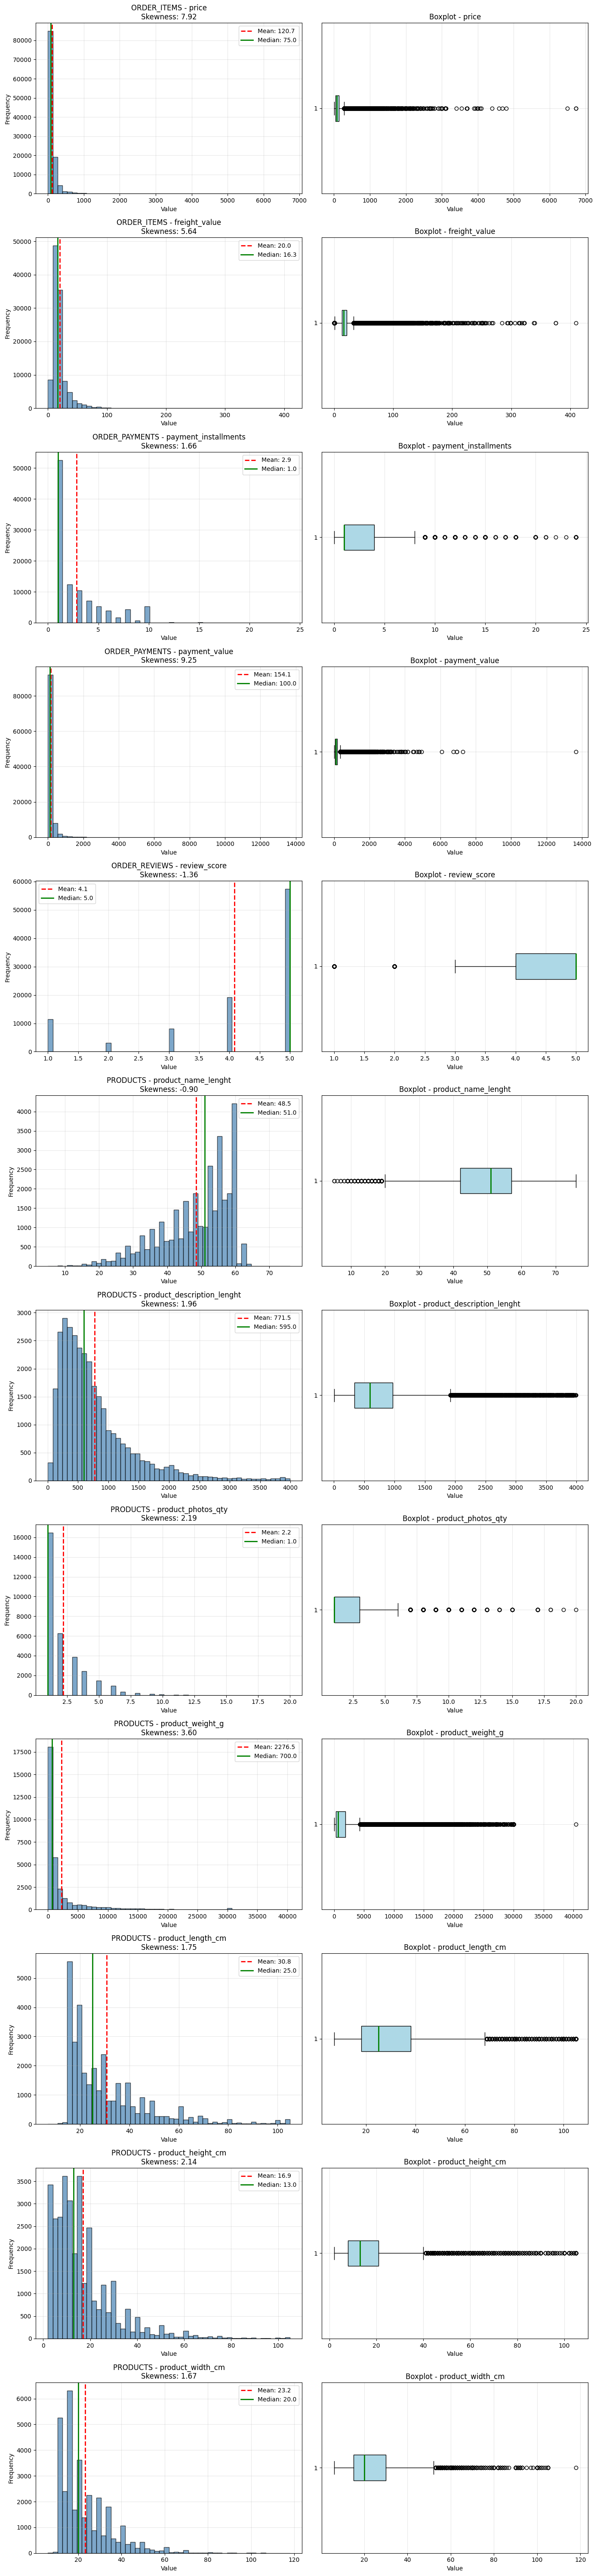

In [75]:
# Prepare data for visualization
plot_data = []

for dataset_name, columns in num_cols_config.items():
    df = datasets.get(dataset_name)
    if df is None:
        continue

    for col in columns:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                plot_data.append((dataset_name, col, data))

if plot_data:
    n_plots = len(plot_data)
    fig, axes = plt.subplots(n_plots, 2, figsize=(14, 5 * n_plots))

    if n_plots == 1:
        axes = axes.reshape(1, -1)

    for idx, (dataset_name, col, data) in enumerate(plot_data):
        # Histogram
        axes[idx, 0].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 0].axvline(data.mean(), color='red', linestyle='--',
                              linewidth=2, label=f'Mean: {data.mean():.1f}')
        axes[idx, 0].axvline(data.median(), color='green', linestyle='-',
                              linewidth=2, label=f'Median: {data.median():.1f}')
        axes[idx, 0].set_title(f'{dataset_name.upper()} - {col}\nSkewness: {data.skew():.2f}')
        axes[idx, 0].set_xlabel('Value')
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        # Boxplot
        axes[idx, 1].boxplot(data, vert=False, patch_artist=True,
                              boxprops=dict(facecolor='lightblue'),
                              medianprops=dict(color='green', linewidth=2))
        axes[idx, 1].set_title(f'Boxplot - {col}')
        axes[idx, 1].set_xlabel('Value')
        axes[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns to visualize")

#### EDA - Categorical Features Distribution

In [76]:
print("=" * 70)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 70)

categorical_summary = []

for name, df in datasets.items():
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    for col in cat_cols:
        unique_count = df[col].nunique()
        sample_vals = df[col].dropna().unique()[:2]

        categorical_summary.append({
            'Dataset': name.upper(),
            'Column': col,
            'Unique Values': unique_count,
            'Sample': str(sample_vals)
        })

df_categorical = pd.DataFrame(categorical_summary)

print(df_categorical.to_string(index=False))
print("=" * 70)

CATEGORICAL COLUMNS SUMMARY
             Dataset                        Column  Unique Values                                                                                                                                             Sample
           CUSTOMERS                   customer_id          99441                                                                            ['06b8999e2fba1a1fbc88172c00ba8bc7' '18955e83d337fd6b2def6b18a428ac77']
           CUSTOMERS            customer_unique_id          96096                                                                            ['861eff4711a542e4b93843c6dd7febb0' '290c77bc529b7ac935b93aa66c333dc3']
           CUSTOMERS                 customer_city           4119                                                                                                                 ['franca' 'sao bernardo do campo']
           CUSTOMERS                customer_state             27                                                       

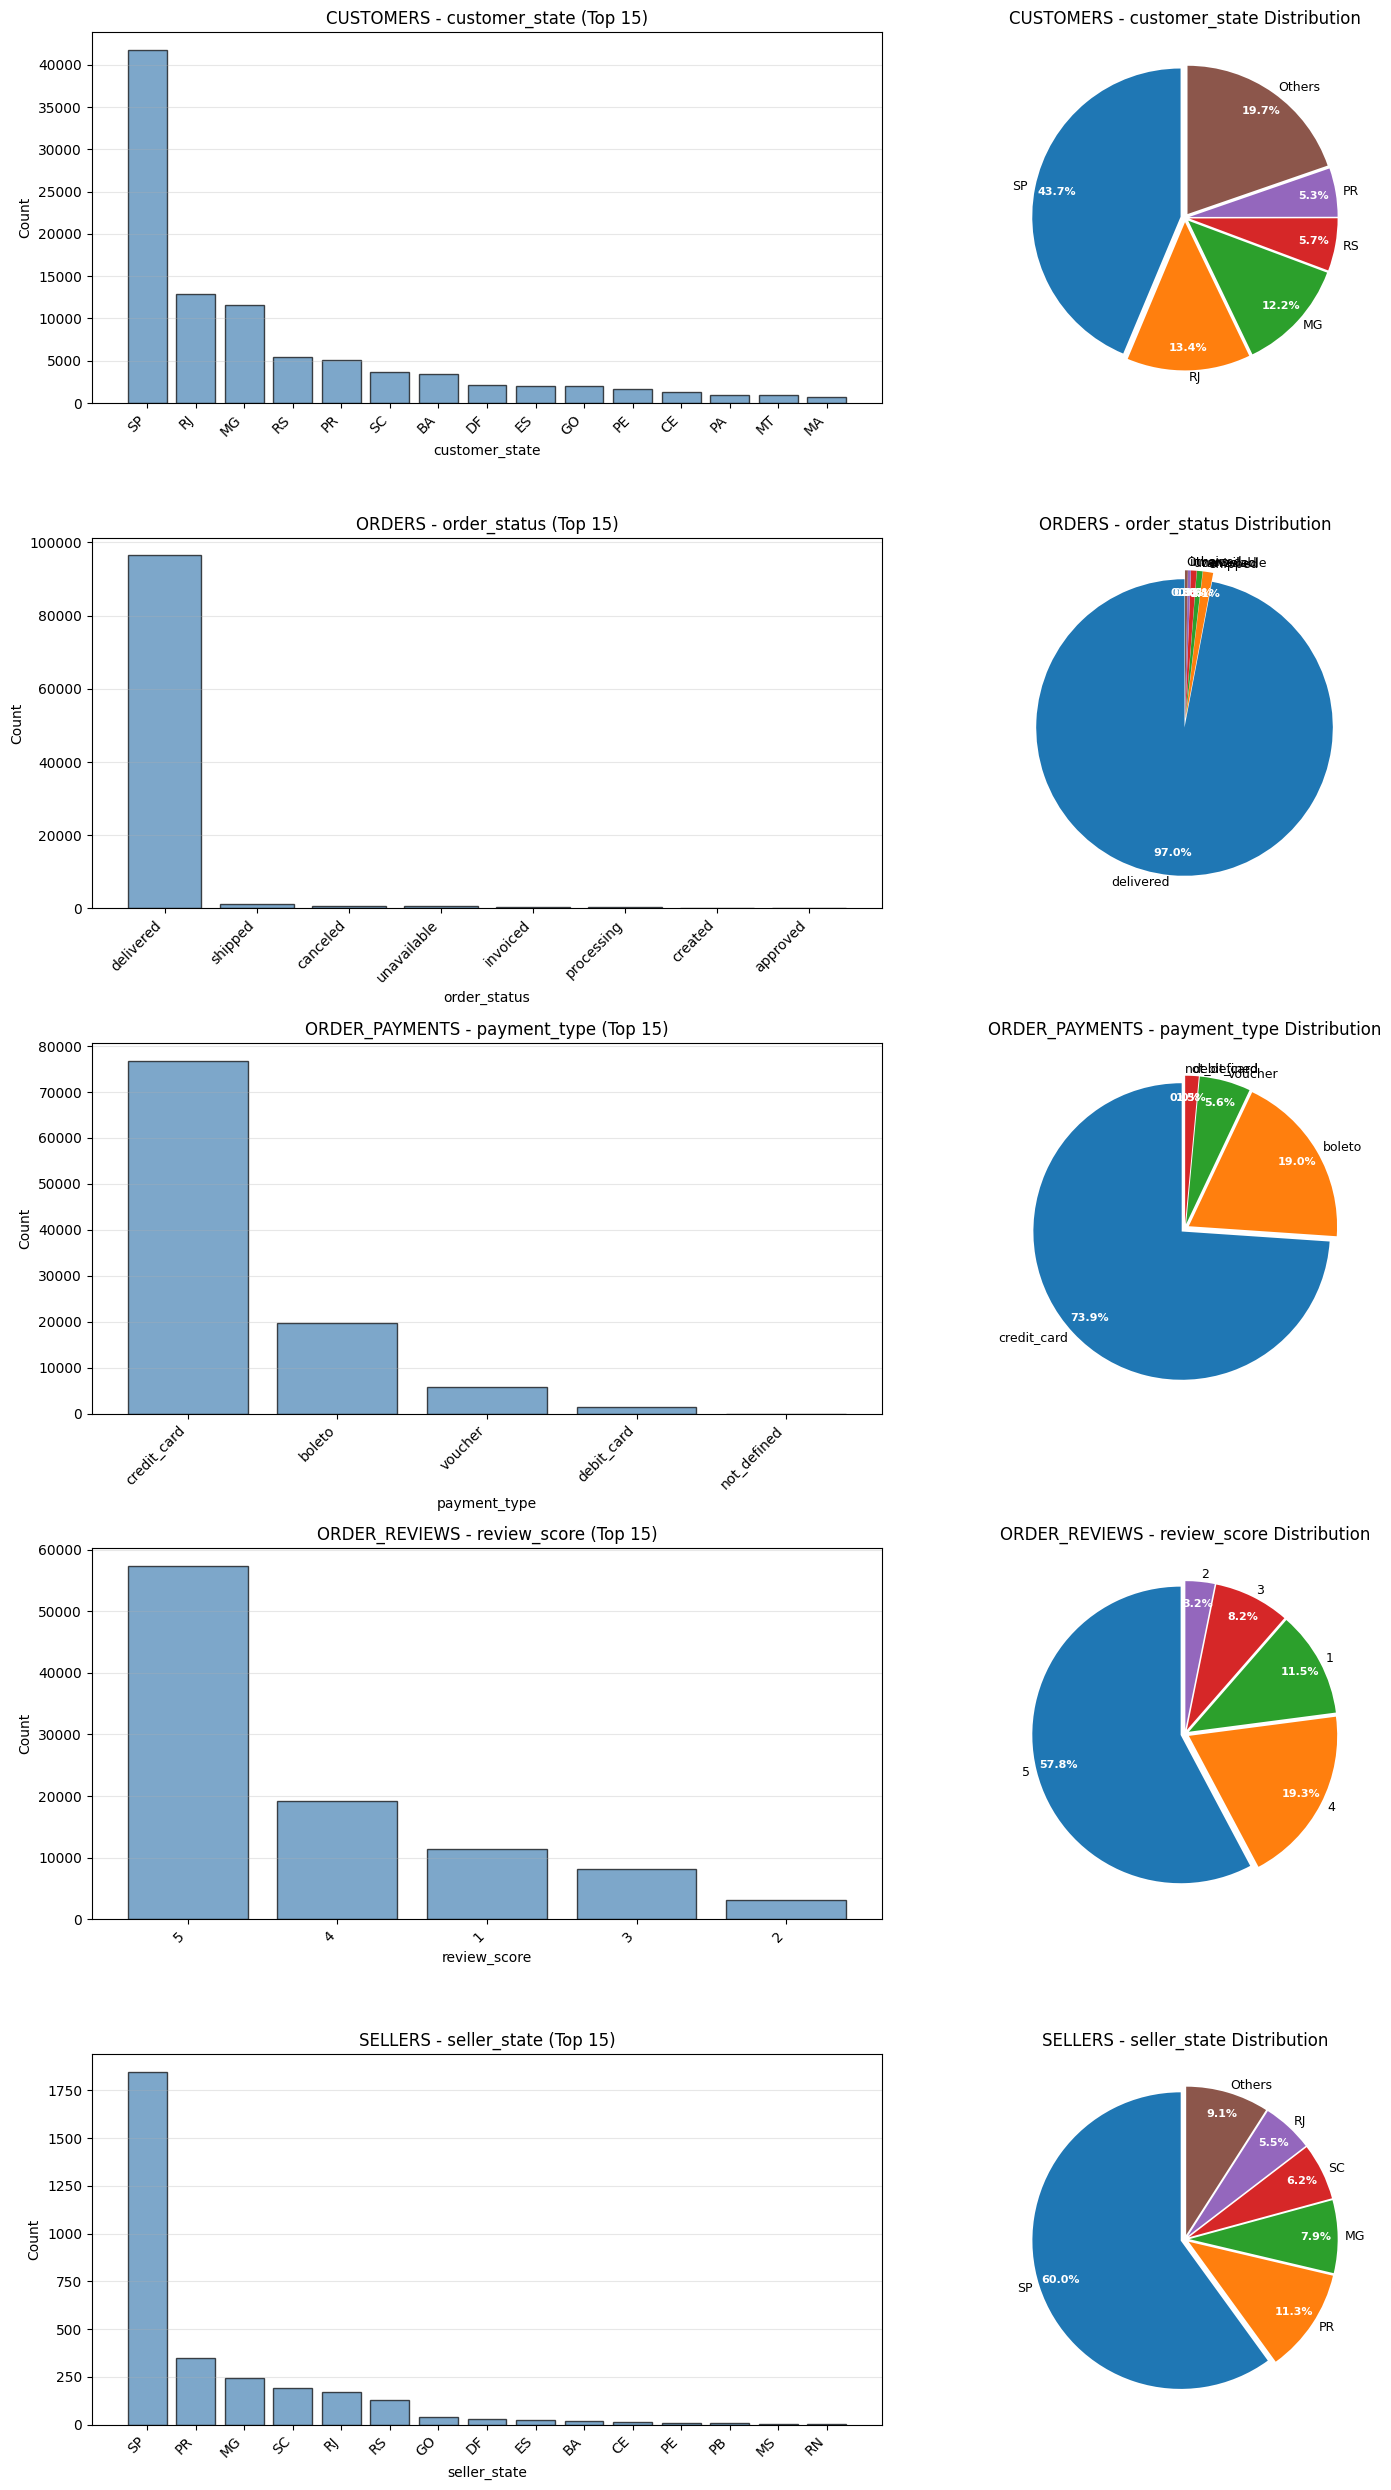


Categorical Columns Summary
CUSTOMERS - customer_state
----------------------------------------
Total unique: 27
1st: SP (41,746 rows)
2nd: RJ (12,852 rows)
3rd: MG (11,635 rows)
ORDERS - order_status
----------------------------------------
Total unique: 8
1st: delivered (96,478 rows)
2nd: shipped (1,107 rows)
3rd: canceled (625 rows)
ORDER_PAYMENTS - payment_type
----------------------------------------
Total unique: 5
1st: credit_card (76,795 rows)
2nd: boleto (19,784 rows)
3rd: voucher (5,775 rows)
ORDER_REVIEWS - review_score
----------------------------------------
Total unique: 5
1st: 5 (57,328 rows)
2nd: 4 (19,142 rows)
3rd: 1 (11,424 rows)
SELLERS - seller_state
----------------------------------------
Total unique: 23
1st: SP (1,849 rows)
2nd: PR (349 rows)
3rd: MG (244 rows)


In [77]:
# Define categorical columns for visualization
cat_cols_config = {
    'customers': ['customer_state'],
    'orders': ['order_status'],
    'order_payments': ['payment_type'],
    'order_reviews': ['review_score'],
    'sellers': ['seller_state']
}

# Prepare data for visualization
plot_data_cat = []

for dataset_name, columns in cat_cols_config.items():
    df = datasets.get(dataset_name)
    if df is None:
        continue

    for col in columns:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                plot_data_cat.append((dataset_name, col, data))

if plot_data_cat:
    n_plots = len(plot_data_cat)
    fig, axes = plt.subplots(n_plots, 2, figsize=(16, 5 * n_plots))

    if n_plots == 1:
        axes = axes.reshape(1, -1)

    for idx, (dataset_name, col, data) in enumerate(plot_data_cat):
        # Bar chart (top 15 values)
        value_counts = data.value_counts().head(15)

        axes[idx, 0].bar(range(len(value_counts)), value_counts.values,
                         color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx, 0].set_xticks(range(len(value_counts)))
        axes[idx, 0].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx, 0].set_title(f'{dataset_name.upper()} - {col} (Top 15)')
        axes[idx, 0].set_xlabel(col)
        axes[idx, 0].set_ylabel('Count')
        axes[idx, 0].grid(True, alpha=0.3, axis='y')

        # pie chart (top 5, rest grouped)
        top5 = value_counts.head(5)
        other_count = value_counts.iloc[5:].sum()

        if other_count > 0:
            plot_values = list(top5.values) + [other_count]
            plot_labels = list(top5.index.astype(str)) + ['Others']
        else:
            plot_values = list(top5.values)
            plot_labels = list(top5.index.astype(str))

        wedges, texts, autotexts = axes[idx, 1].pie(
            plot_values,
            labels=plot_labels,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.85,
            labeldistance=1.05,
            explode=[0.03] * len(plot_values)
        )

        # Improve text readability
        for text in texts:
            text.set_fontsize(9)
        for autotext in autotexts:
            autotext.set_fontsize(8)
            autotext.set_color('white')
            autotext.set_fontweight('bold')

        axes[idx, 1].set_title(f'{dataset_name.upper()} - {col} Distribution')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to visualize")

# Print summary statistics
print("\n" + "=" * 60)
print("Categorical Columns Summary")
print("=" * 60)

for dataset_name, columns in cat_cols_config.items():
    df = datasets.get(dataset_name)
    if df is None:
        continue

    for col in columns:
        if col in df.columns:
            value_counts = df[col].value_counts()
            print(f"{dataset_name.upper()} - {col}")
            print("-" * 40)
            print(f"Total unique: {df[col].nunique()}")
            print(f"1st: {value_counts.index[0]} ({value_counts.values[0]:,} rows)")
            if len(value_counts) > 1:
                print(f"2nd: {value_counts.index[1]} ({value_counts.values[1]:,} rows)")
            if len(value_counts) > 2:
                print(f"3rd: {value_counts.index[2]} ({value_counts.values[2]:,} rows)")
            print("=" * 40)

#### EDA - Time Series Analysis

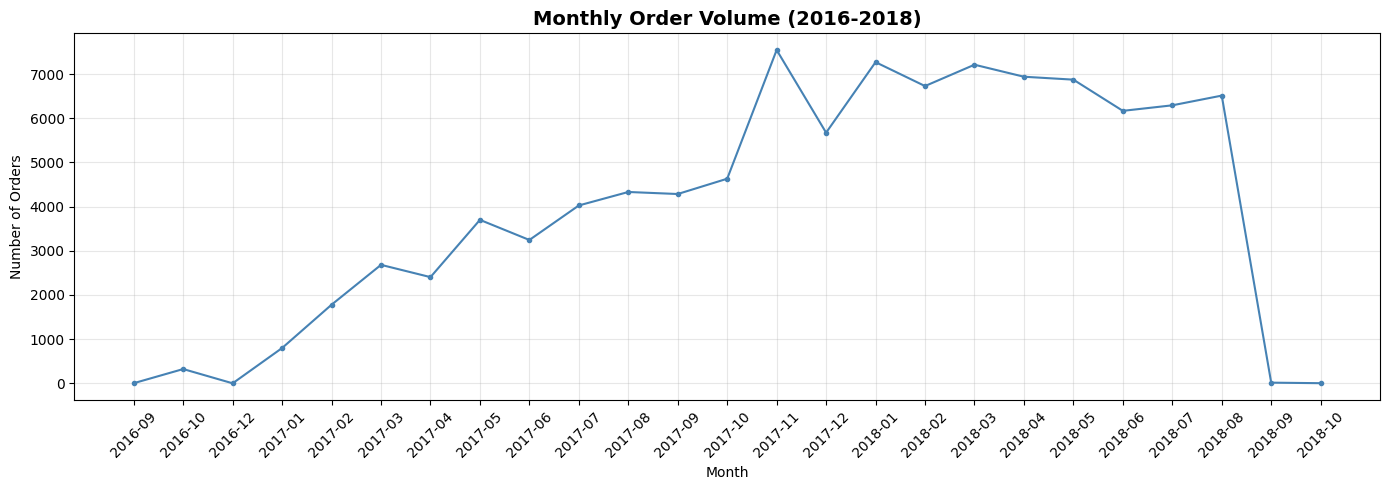


MONTHLY ORDER VOLUME
order_year_month_str  order_count
             2016-09            4
             2016-10          324
             2016-12            1
             2017-01          800
             2017-02         1780
             2017-03         2682
             2017-04         2404
             2017-05         3700
             2017-06         3245
             2017-07         4026
             2017-08         4331
             2017-09         4285
             2017-10         4631
             2017-11         7544
             2017-12         5673
             2018-01         7269
             2018-02         6728
             2018-03         7211
             2018-04         6939
             2018-05         6873
             2018-06         6167
             2018-07         6292
             2018-08         6512
             2018-09           16
             2018-10            4


In [78]:
# Convert date columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Calculate delivery time (actual vs estimated)
orders['actual_delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
orders['estimated_delivery_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
orders['delivery_gap_days'] = orders['actual_delivery_days'] - orders['estimated_delivery_days']

# 1. Monthly Order Trends
# Extract month and year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Monthly order count
monthly_orders = orders.groupby('order_year_month').size().reset_index(name='order_count')
monthly_orders['order_year_month_str'] = monthly_orders['order_year_month'].astype(str)

# Plot monthly orders
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_orders['order_year_month_str'], monthly_orders['order_count'],
        marker='o', linewidth=1.5, markersize=3, color='steelblue')
ax.set_title('Monthly Order Volume (2016-2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMONTHLY ORDER VOLUME")
print("=" * 50)
print(monthly_orders[['order_year_month_str', 'order_count']].to_string(index=False))

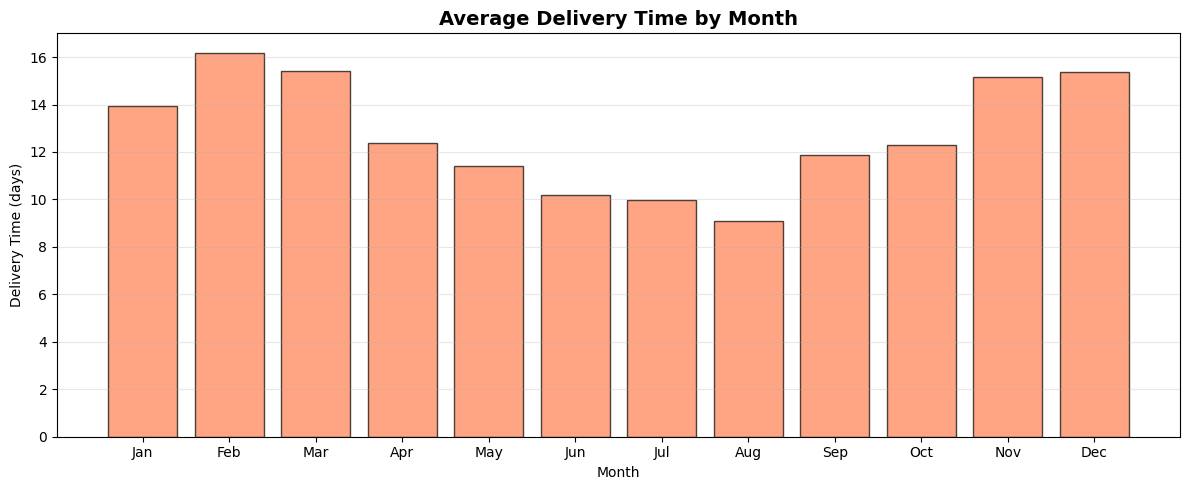


MONTHLY DELIVERY STATISTICS
month_name  actual_delivery_days  estimated_delivery_days  delivery_gap_days
       Jan                 13.94                    27.64             -13.63
       Feb                 16.19                    26.08              -9.82
       Mar                 15.41                    22.86              -7.34
       Apr                 12.36                    24.64             -12.24
       May                 11.39                    23.37             -11.99
       Jun                 10.18                    26.47             -16.32
       Jul                  9.98                    21.09             -11.11
       Aug                  9.09                    18.48              -9.39
       Sep                 11.86                    22.44             -10.58
       Oct                 12.30                    25.10             -12.58
       Nov                 15.16                    22.52              -7.40
       Dec                 15.39               

In [79]:
# 2. Monthly Delivery Performance
# Average delivery time by month
monthly_delivery = orders.groupby('order_month').agg({
    'actual_delivery_days': 'mean',
    'estimated_delivery_days': 'mean',
    'delivery_gap_days': 'mean'
}).round(2).reset_index()

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_delivery['month_name'] = monthly_delivery['order_month'].map(month_names)

# Plot delivery time by month
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_delivery['month_name'], monthly_delivery['actual_delivery_days'],
       color='coral', alpha=0.7, edgecolor='black')
ax.set_title('Average Delivery Time by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Delivery Time (days)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nMONTHLY DELIVERY STATISTICS")
print("=" * 50)
print(monthly_delivery[['month_name', 'actual_delivery_days', 'estimated_delivery_days', 'delivery_gap_days']].to_string(index=False))

In [80]:
# 3. Peak Season Analysis
# Define peak months (from data: May, July, August have highest volume)
peak_months = [5, 7, 8]
orders['is_peak_season'] = orders['order_month'].isin(peak_months)

peak_comparison = orders.groupby('is_peak_season').agg({
    'order_id': 'count',
    'actual_delivery_days': 'mean',
    'delivery_gap_days': 'mean'
}).round(2)
peak_comparison.index = ['Normal Months', 'Peak Months (May, Jul, Aug)']

print("=" * 60)
print("PEAK SEASON VS NORMAL MONTHS")
print("=" * 60)
print(peak_comparison.to_string())

PEAK SEASON VS NORMAL MONTHS
                             order_id  actual_delivery_days  delivery_gap_days
Normal Months                   67707                 13.69             -11.35
Peak Months (May, Jul, Aug)     31734                 10.14             -10.82


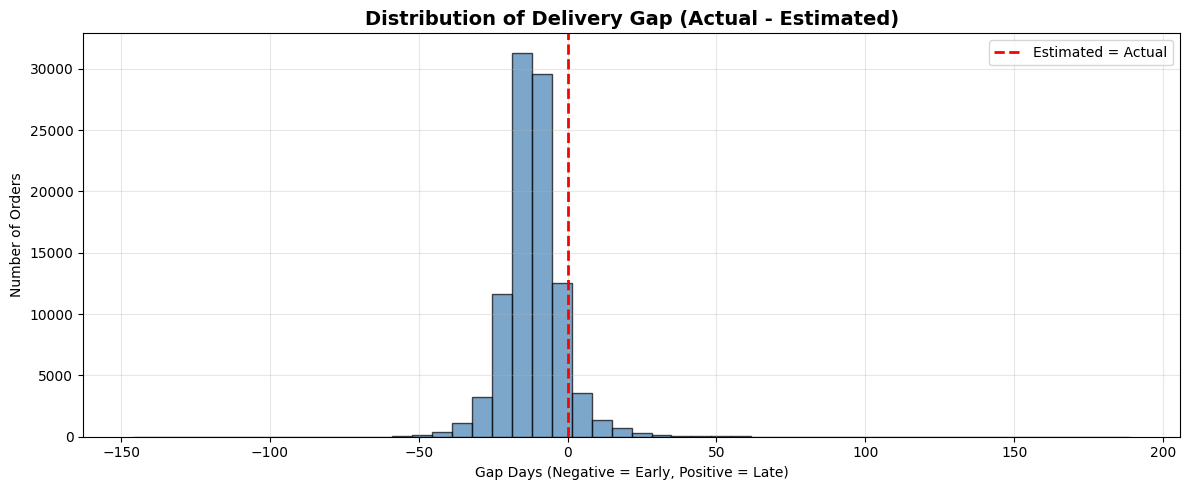


DELIVERY GAP ANALYSIS
Early deliveries (negative gap): 88,649 orders
On-time (gap ≈ 0): 2,754 orders
Late deliveries (positive gap): 7,827 orders
Average gap: -11.18 days
Median gap: -11.95 days
Worst delay: 188.98 days


In [81]:
# 4. Delivery Gap (Actual vs Estimated)
fig, ax = plt.subplots(figsize=(12, 5))
orders['delivery_gap_days'].hist(bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Estimated = Actual')
ax.set_title('Distribution of Delivery Gap (Actual - Estimated)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gap Days (Negative = Early, Positive = Late)')
ax.set_ylabel('Number of Orders')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("DELIVERY GAP ANALYSIS")
print("=" * 60)
print(f"Early deliveries (negative gap): {(orders['delivery_gap_days'] < 0).sum():,} orders")
print(f"On-time (gap ≈ 0): {((orders['delivery_gap_days'] >= -1) & (orders['delivery_gap_days'] <= 1)).sum():,} orders")
print(f"Late deliveries (positive gap): {(orders['delivery_gap_days'] > 0).sum():,} orders")
print(f"Average gap: {orders['delivery_gap_days'].mean():.2f} days")
print(f"Median gap: {orders['delivery_gap_days'].median():.2f} days")
print(f"Worst delay: {orders['delivery_gap_days'].max():.2f} days")
print("=" * 60)


DELIVERY PERFORMANCE BY DAY OF WEEK
          order_id  actual_delivery_days
day_name                                
Mon          16196                 12.00
Tue          15963                 12.08
Wed          15552                 12.44
Thu          14761                 12.74
Fri          14122                 13.57
Sat          10887                 13.36
Sun          11960                 11.96


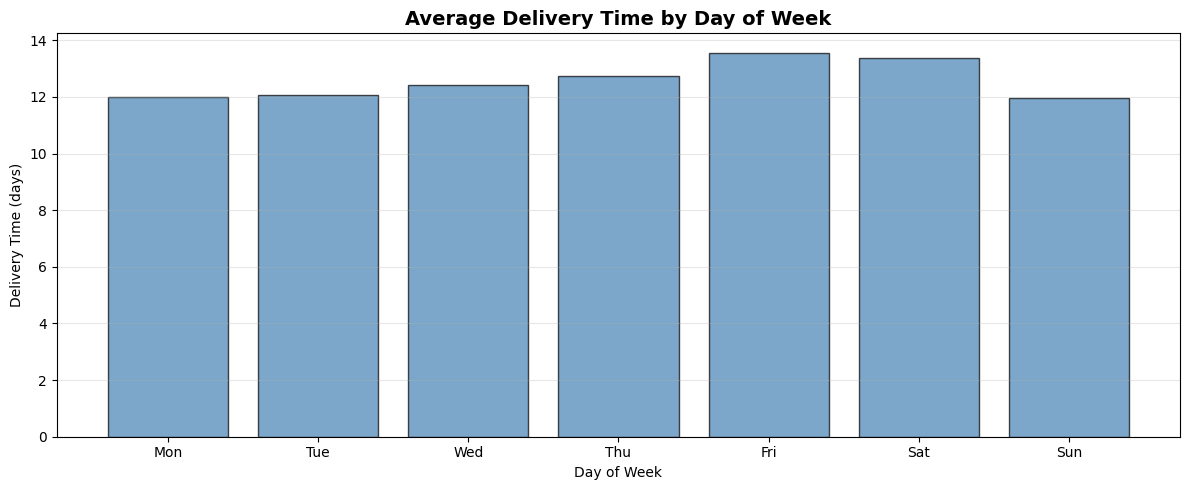

In [82]:
# 5. Day of Week Analysis
orders['purchase_day_of_week'] = orders['order_purchase_timestamp'].dt.dayofweek
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
orders['day_name'] = orders['purchase_day_of_week'].map(day_names)

daily_performance = orders.groupby('day_name').agg({
    'order_id': 'count',
    'actual_delivery_days': 'mean'
}).round(2)

# Reorder days
days_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_performance = daily_performance.reindex(days_order)

print("\n" + "=" * 60)
print("DELIVERY PERFORMANCE BY DAY OF WEEK")
print("=" * 60)
print(daily_performance.to_string())
print("=" * 60)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_performance.index, daily_performance['actual_delivery_days'],
       color='steelblue', alpha=0.7, edgecolor='black')
ax.set_title('Average Delivery Time by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delivery Time (days)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

EDA Findings: Time Series Analysisa

A. Monthly Order Volume (Order Volume Analysis)

Based on order volume analysis from September 2016 to October 2018:

1. Peak seasons identified: Highest order volume occurs in November (7.544 orders), January (7.269), March (7.211), and August (6,512). These months require higher logistics capacity.

2. Business growth trend:
Order volume grew 74% from 2017 (average ~3.900/month) to 2018 (average ~6.800/month). This suggests logistics bottlenecks will worsen without intervention as the business scales.

3. Data limitation:
September-October 2018 data is incomplete (16 and 4 orders respectively). Peak season analysis for 2018 should exclude these months or note this limitation.

Critical finding: November requires 2x logistics capacity compared to normal months (7.544 vs ~4.000 average). Routes with delays during November should be the top priority.

B. Monthly Delivery Performance (Delivery Time Analysis)

Key findings:

1. Peak season months (May, July, August) are actually the fastest delivery months (avg 10,14 days), not the slowest. This contradicts the initial problem statement.
2. February is the real problem, slowest delivery month (16,19 days), despite having normal order volume.
Possible causes: weather (rainy season in Brazil) or post-holiday backlog.

3. Estimated delivery dates are consistently too pessimistic, actual deliveries are always faster by 7-16 days. This is a forecasting accuracy problem, not an operational problem.

Real problem months are February-March and November-December, not May-July-August.

C. Delivery Gap Analysis (Actual vs Estimated)

Key findings:
1. Only 7.9% of orders are actually late (positive gap). The other 89.2% arrive early.
2. This means the "delivery time problem" affects a small minority of orders, not the entire network.
3. Recommendation: Logistics team should focus on the 7,827 late orders and the routes causing them, rather than assuming network-wide failures.



**SUMMARY**
1. Order volume grew 74% from 2017 to 2018, peaking in November (7,544 orders) which requires 2x normal logistics capacity.

2. Contrary to initial assumptions, peak season months (May, July, August) are not the delivery bottleneck. in fact, delivery time improves during these months (10.14 days vs 13.69 days normal).
3. The real problem months are February-March and November-December, where delivery time averages 15-16 days.
4. Only 7.9% of orders are actually late (7,827 orders). The other 89.2% arrive early, consistently beating Olist's own estimated delivery dates by 7-16 days.
5. Focus intervention on:

(a). the 7,827 late orders,
(b). routes operating in February-March, and
(c). November-December peak volume. Peak seasons aren't the problem.

#### EDA - Geospatial Distribution

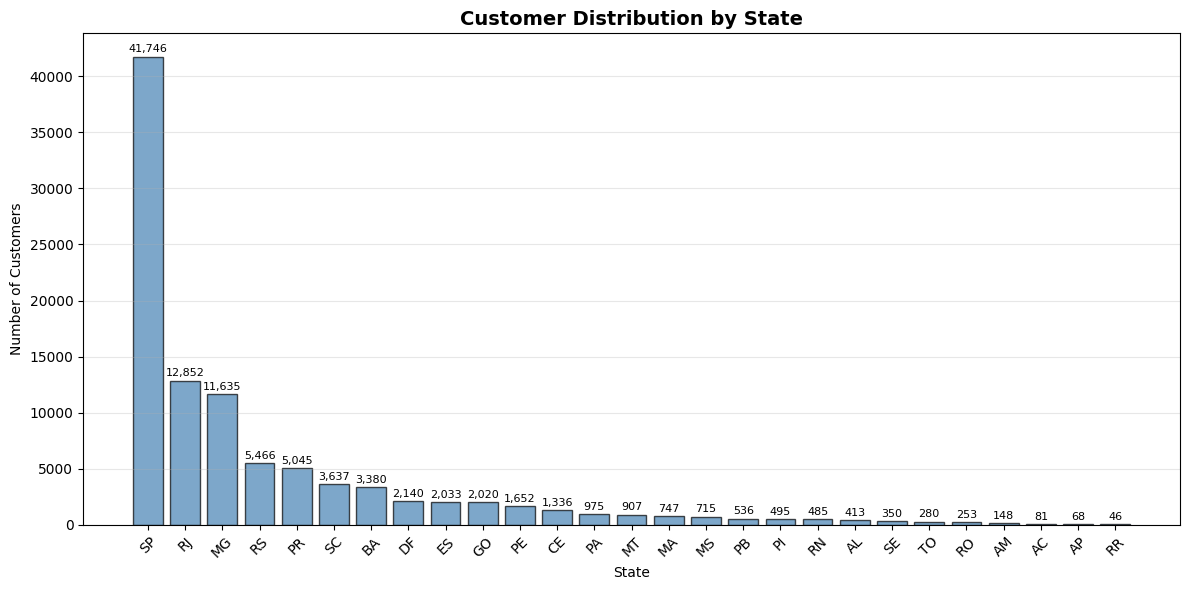

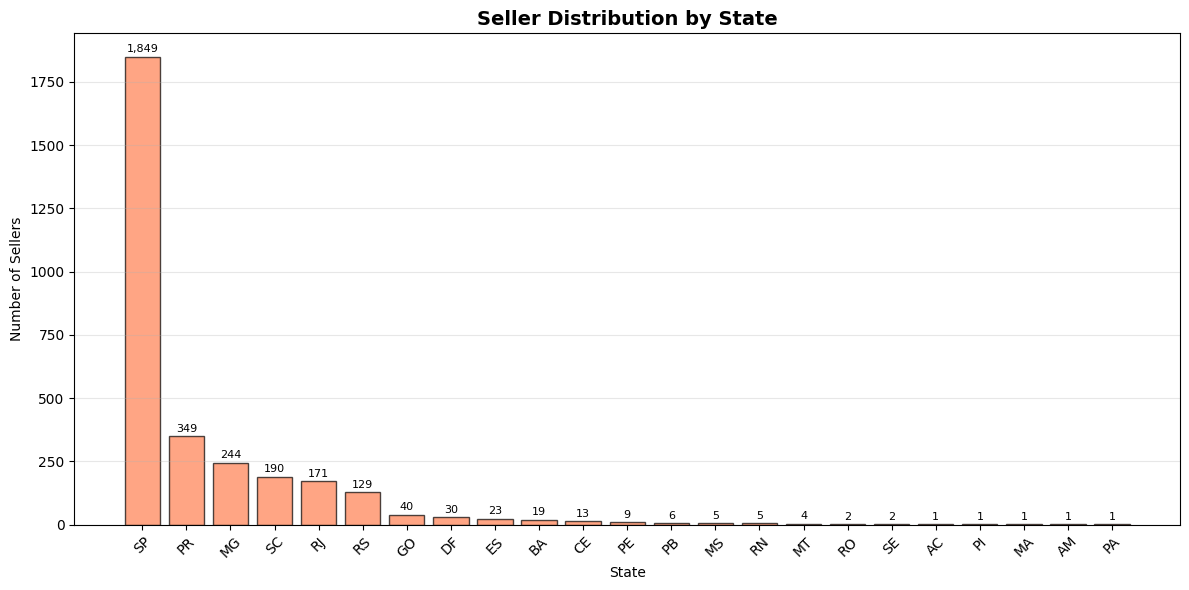

TOP 10 Customer States
----------------------------------------
   SP: 41,746 customers
   RJ: 12,852 customers
   MG: 11,635 customers
   RS:  5,466 customers
   PR:  5,045 customers
   SC:  3,637 customers
   BA:  3,380 customers
   DF:  2,140 customers
   ES:  2,033 customers
   GO:  2,020 customers

 TOP 10 SELLER STATES
----------------------------------------
   SP:  1,849 sellers
   PR:    349 sellers
   MG:    244 sellers
   SC:    190 sellers
   RJ:    171 sellers
   RS:    129 sellers
   GO:     40 sellers
   DF:     30 sellers
   ES:     23 sellers
   BA:     19 sellers


In [83]:
# 1. Customer and Seller Distribution by State
# Customer Distribution by State
customer_state_counts = customers['customer_state'].value_counts().reset_index()
customer_state_counts.columns = ['state', 'count']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(customer_state_counts['state'], customer_state_counts['count'],
              color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Customer Distribution by State', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 200,
            f'{int(height):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Seller Distribution by State
seller_state_counts = sellers['seller_state'].value_counts().reset_index()
seller_state_counts.columns = ['state', 'count']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(seller_state_counts['state'], seller_state_counts['count'],
              color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Seller Distribution by State', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Sellers')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


print("TOP 10 Customer States")
print("-" * 40)
for i, row in customer_state_counts.head(10).iterrows():
    print(f"   {row['state']}: {row['count']:>6,} customers")

print("\n TOP 10 SELLER STATES")
print("-" * 40)
for i, row in seller_state_counts.head(10).iterrows():
    print(f"   {row['state']}: {row['count']:>6,} sellers")

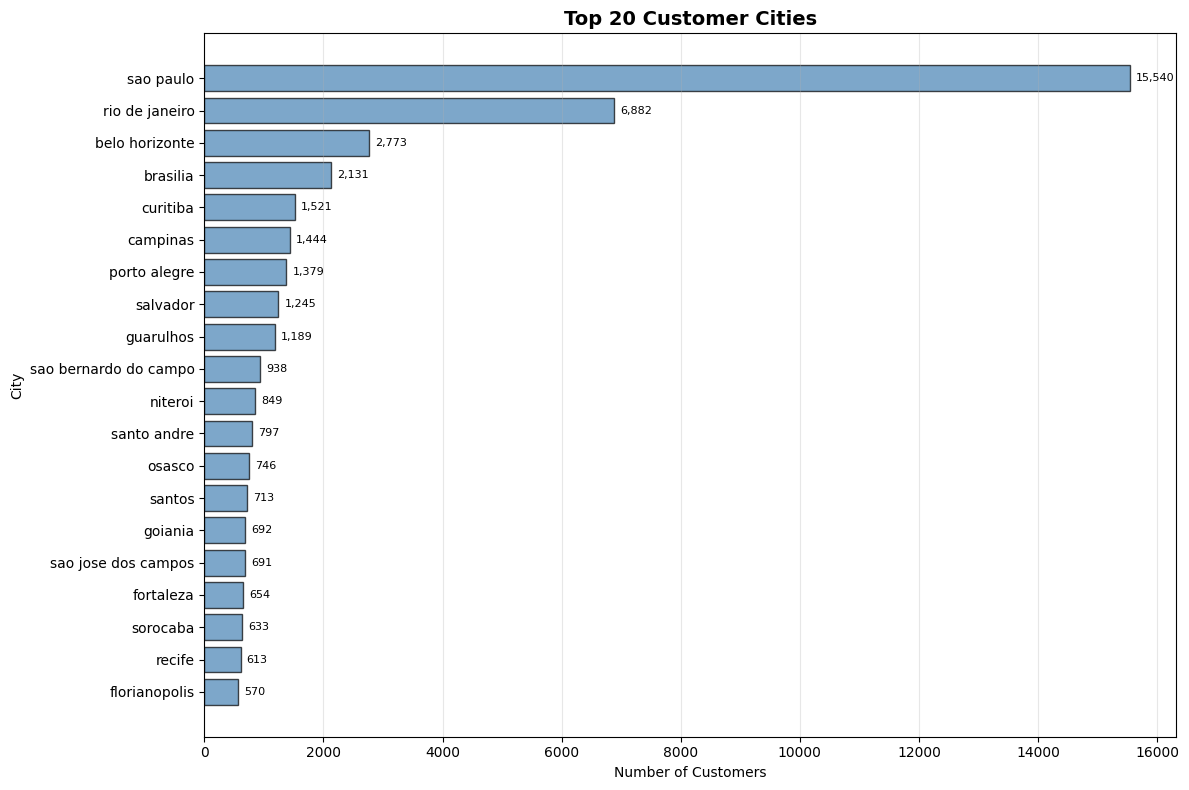

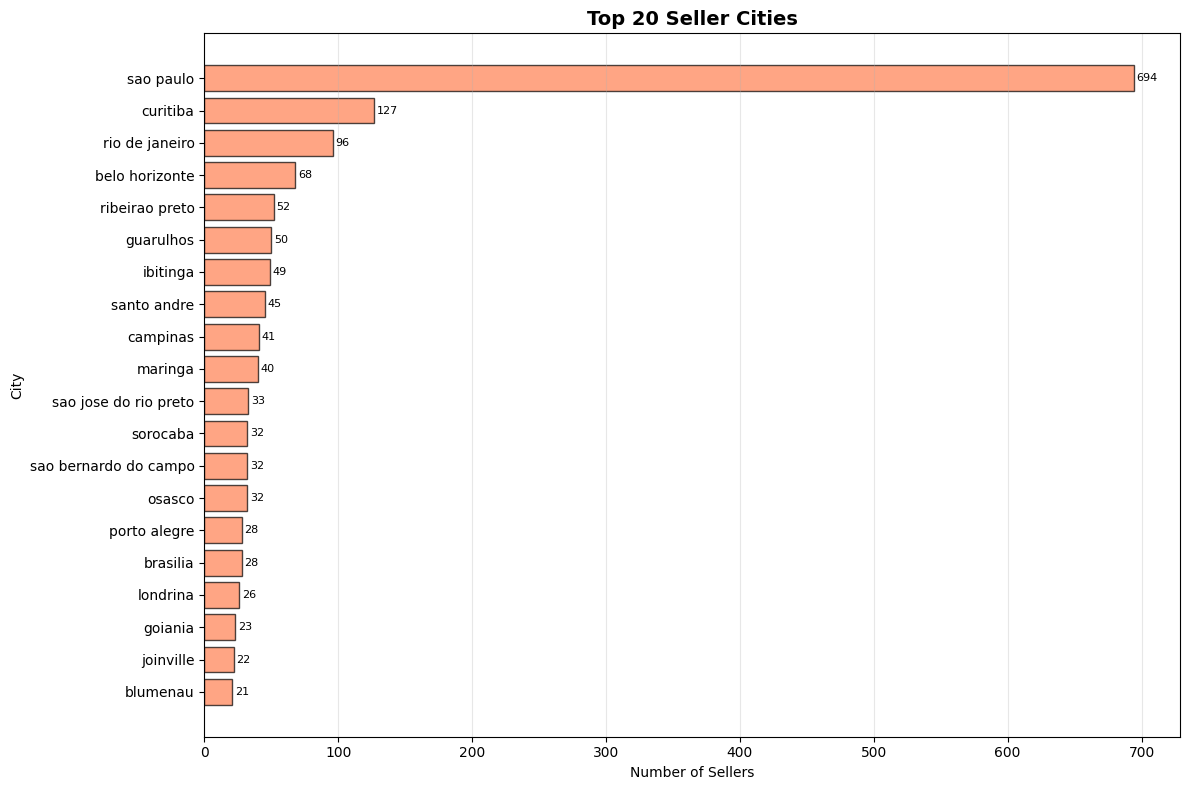

TOP 10 CUSTOMER CITIES
- sao paulo                 : 15,540
- rio de janeiro            :  6,882
- belo horizonte            :  2,773
- brasilia                  :  2,131
- curitiba                  :  1,521
- campinas                  :  1,444
- porto alegre              :  1,379
- salvador                  :  1,245
- guarulhos                 :  1,189
- sao bernardo do campo     :    938

 TOP 10 Seller Cities CITIES
- sao paulo                 :    694
- curitiba                  :    127
- rio de janeiro            :     96
- belo horizonte            :     68
- ribeirao preto            :     52
- guarulhos                 :     50
- ibitinga                  :     49
- santo andre               :     45
- campinas                  :     41
- maringa                   :     40


In [84]:
# 2. Customer and Seller Distribution by Cities
# Customer Distribution by Cities
customer_city_counts = customers['customer_city'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(customer_city_counts)), customer_city_counts.values,
                color='steelblue', edgecolor='black', alpha=0.7)

ax.set_yticks(range(len(customer_city_counts)))
ax.set_yticklabels(customer_city_counts.index)
ax.set_title('Top 20 Customer Cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('City')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Seller Distribution by Cities
seller_city_counts = sellers['seller_city'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(seller_city_counts)), seller_city_counts.values,
                color='coral', edgecolor='black', alpha=0.7)

ax.set_yticks(range(len(seller_city_counts)))
ax.set_yticklabels(seller_city_counts.index)
ax.set_title('Top 20 Seller Cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Sellers')
ax.set_ylabel('City')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()


top_customer_cities = customers['customer_city'].value_counts().head(10)
top_seller_cities = sellers['seller_city'].value_counts().head(10)

print("TOP 10 CUSTOMER CITIES")
for city, count in top_customer_cities.items():
    print(f"- {city[:25]:25} : {count:>6,}")

print("\n TOP 10 Seller Cities CITIES")
for city, count in top_seller_cities.items():
    print(f"- {city[:25]:25} : {count:>6,}")

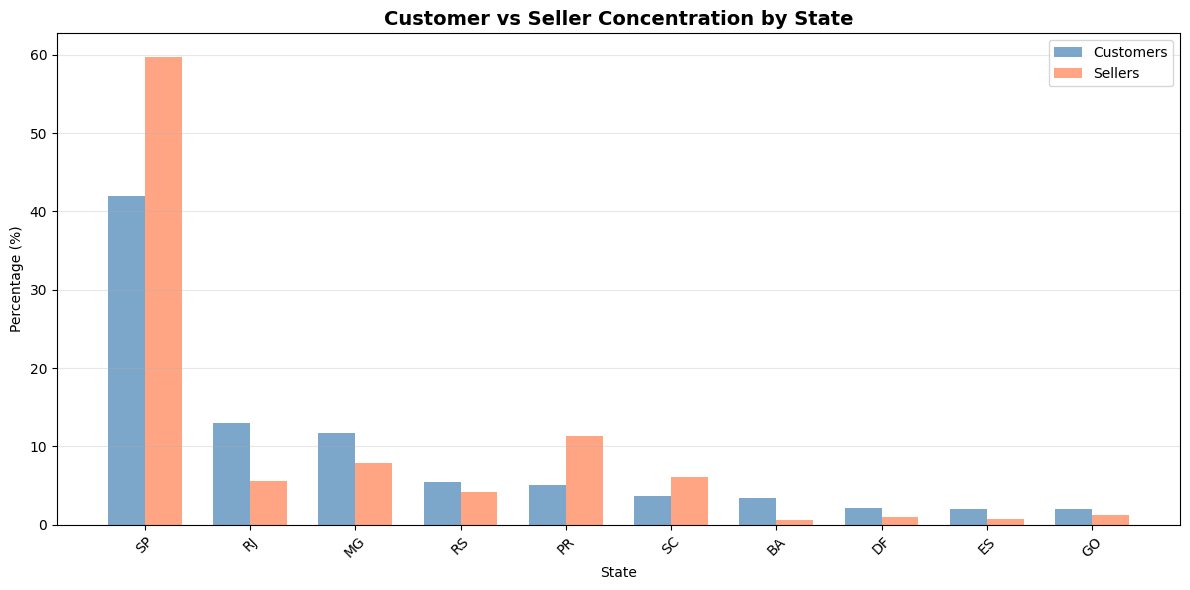

Suply Demand Gap Analysis
------------------------------------------------------------
State     Customers    Sellers      Ratio
------------------------------------------------------------
SP           41,746    1,849.0      22.6x
RJ           12,852      171.0      75.2x
MG           11,635      244.0      47.7x
RS            5,466      129.0      42.4x
PR            5,045      349.0      14.5x
SC            3,637      190.0      19.1x
BA            3,380       19.0     177.9x
DF            2,140       30.0      71.3x
ES            2,033       23.0      88.4x
GO            2,020       40.0      50.5x


In [85]:
# 3. Customer vs Seller Concentration

# Merge customer and seller counts
state_comparison = customer_state_counts.merge(
    seller_state_counts, on='state', how='outer', suffixes=('_customers', '_sellers')
).fillna(0)

state_comparison['customer_pct'] = (state_comparison['count_customers'] / state_comparison['count_customers'].sum()) * 100
state_comparison['seller_pct'] = (state_comparison['count_sellers'] / state_comparison['count_sellers'].sum()) * 100

state_comparison = state_comparison.sort_values('count_customers', ascending=False).head(10)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(state_comparison))
width = 0.35

ax.bar([i - width/2 for i in x], state_comparison['customer_pct'], width,
       label='Customers', color='steelblue', alpha=0.7)
ax.bar([i + width/2 for i in x], state_comparison['seller_pct'], width,
       label='Sellers', color='coral', alpha=0.7)

ax.set_xlabel('State')
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer vs Seller Concentration by State', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(state_comparison['state'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Suply Demand Gap Analysis")
print("-" * 60)
print(f"{'State':<6} {'Customers':>12} {'Sellers':>10} {'Ratio':>10}")
print("-" * 60)
for _, row in state_comparison.iterrows():
    ratio = row['count_customers'] / row['count_sellers'] if row['count_sellers'] > 0 else float('inf')
    print(f"{row['state']:<6} {row['count_customers']:>12,} {row['count_sellers']:>10,} {ratio:>9.1f}x")

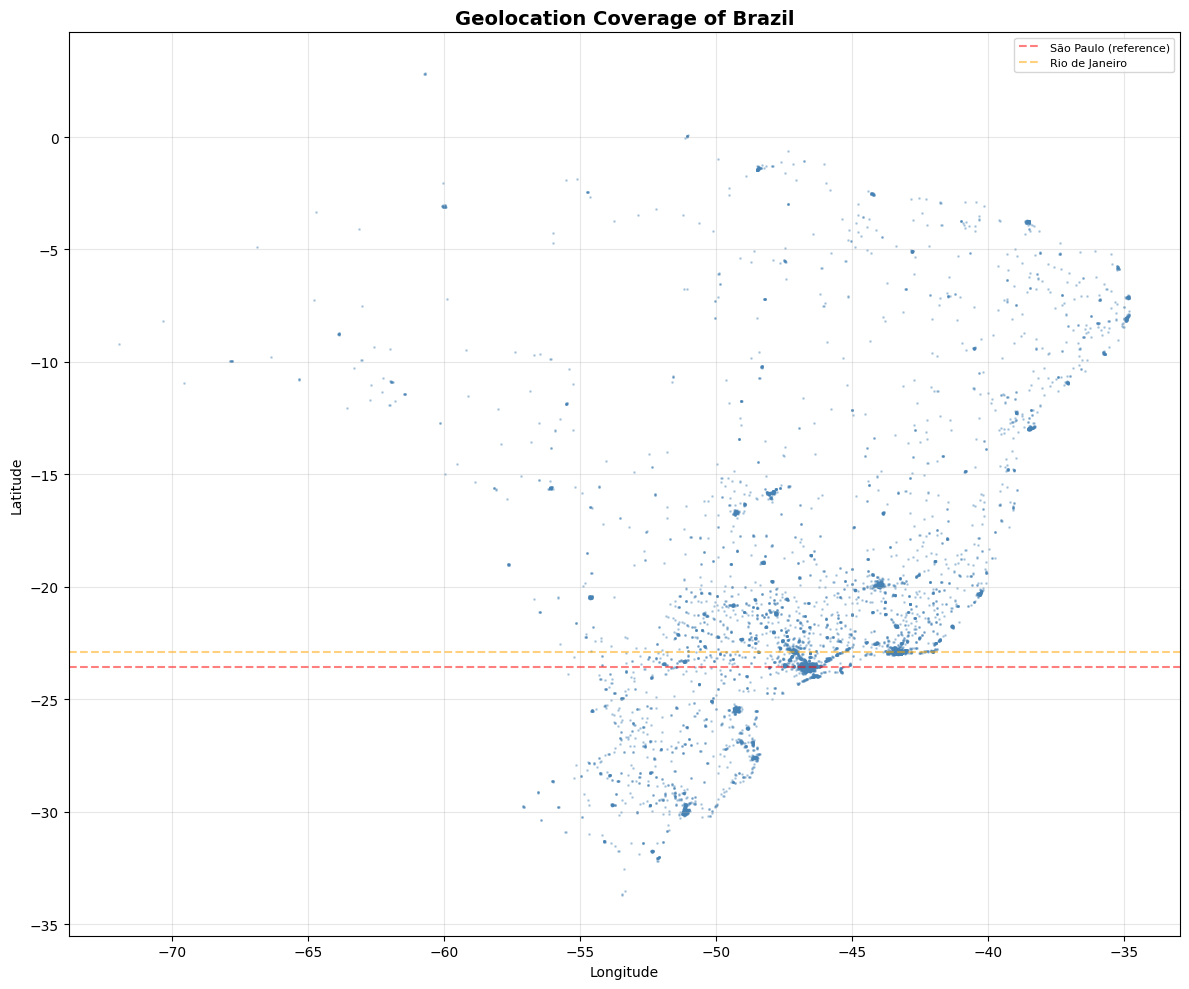


 Geolocation Summary
Total geolocation records: 1,000,163
Unique zip codes: 19,015
Unique cities: 8,011
Unique states: 27
Latitude range: -36.61 to 45.07
Longitude range: -101.47 to 121.11


In [86]:
# 4. Geolocation Coverage Map (Static)
# Sample geolocation data for visualization
geo_sample = geolocation.sample(min(10000, len(geolocation)))

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(geo_sample['geolocation_lng'], geo_sample['geolocation_lat'],
                     c='steelblue', alpha=0.3, s=1)
ax.set_title('Geolocation Coverage of Brazil', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add reference lines for major regions
ax.axhline(y=-23.55, color='red', linestyle='--', alpha=0.5, label='São Paulo (reference)')
ax.axhline(y=-22.91, color='orange', linestyle='--', alpha=0.5, label='Rio de Janeiro')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n Geolocation Summary")
print("=" * 40)
print(f"Total geolocation records: {len(geolocation):,}")
print(f"Unique zip codes: {geolocation['geolocation_zip_code_prefix'].nunique():,}")
print(f"Unique cities: {geolocation['geolocation_city'].nunique():,}")
print(f"Unique states: {geolocation['geolocation_state'].nunique()}")
print(f"Latitude range: {geolocation['geolocation_lat'].min():.2f} to {geolocation['geolocation_lat'].max():.2f}")
print(f"Longitude range: {geolocation['geolocation_lng'].min():.2f} to {geolocation['geolocation_lng'].max():.2f}")

#### EDA - Correlation Analysis

Master data shape: 95,813 orders × 10 features
Features: delivery_days, total_price, total_freight, n_items, payment_value, review_score, avg_weight_g, avg_length_cm, avg_height_cm, avg_width_cm


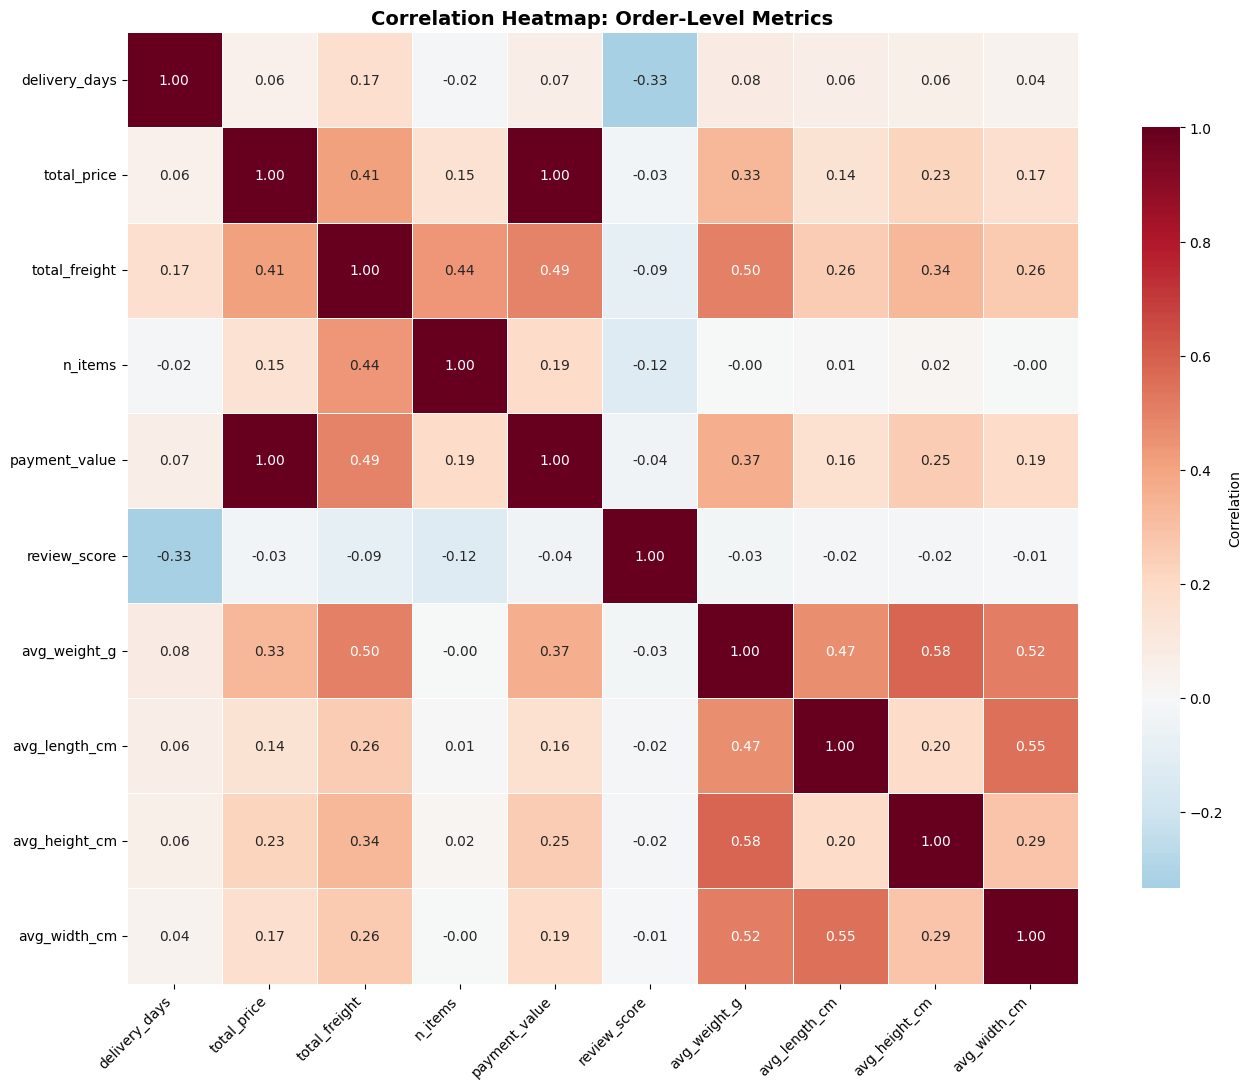

CORRELATION SUMMARY

Factors correlated with delivery time:
  total_freight   : +0.167
  review_score    : -0.334

Price vs Freight correlation: +0.410
Number of items vs Delivery time: -0.020
Review score vs Delivery time: -0.334


In [87]:
# 2.8 EDA - CORRELATION HEATMAP

# Create master dataframe at order level
master_corr = pd.DataFrame()

# Delivery time
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
master_corr['delivery_days'] = orders.set_index('order_id')['delivery_days']

# Order items aggregation
items_agg = order_items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
}).rename(columns={'order_item_id': 'n_items'})

master_corr['total_price'] = items_agg['price']
master_corr['total_freight'] = items_agg['freight_value']
master_corr['n_items'] = items_agg['n_items']

# Payment value
payments_agg = payments.groupby('order_id')['payment_value'].sum()
master_corr['payment_value'] = payments_agg

# Review score
reviews_agg = reviews.groupby('order_id')['review_score'].mean()
master_corr['review_score'] = reviews_agg

# Product dimensions (average per order)
products_subset = products[['product_id', 'product_weight_g', 'product_length_cm',
                            'product_height_cm', 'product_width_cm']]
items_with_products = order_items.merge(products_subset, on='product_id', how='left')

products_agg = items_with_products.groupby('order_id').agg({
    'product_weight_g': 'mean',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean'
})

master_corr['avg_weight_g'] = products_agg['product_weight_g']
master_corr['avg_length_cm'] = products_agg['product_length_cm']
master_corr['avg_height_cm'] = products_agg['product_height_cm']
master_corr['avg_width_cm'] = products_agg['product_width_cm']

# Clean data
master_corr = master_corr.dropna()

print(f"Master data shape: {master_corr.shape[0]:,} orders × {master_corr.shape[1]} features")
print(f"Features: {', '.join(master_corr.columns.tolist())}")

# Correlation matrix
corr_matrix = master_corr.corr()

# Plot heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
plt.title('Correlation Heatmap: Order-Level Metrics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation summary
print("=" * 60)
print("CORRELATION SUMMARY")
print("=" * 60)

# Top correlations with delivery time
if 'delivery_days' in corr_matrix.columns:
    print("\nFactors correlated with delivery time:")
    delivery_corr = corr_matrix['delivery_days'].sort_values(ascending=False)
    for var, val in delivery_corr.items():
        if var != 'delivery_days' and abs(val) > 0.1:
            print(f"  {var:15} : {val:+.3f}")

# Price vs freight
if 'total_price' in corr_matrix.columns and 'total_freight' in corr_matrix.columns:
    pf_corr = corr_matrix.loc['total_price', 'total_freight']
    print(f"\nPrice vs Freight correlation: {pf_corr:+.3f}")

# Number of items vs delivery
if 'n_items' in corr_matrix.columns and 'delivery_days' in corr_matrix.columns:
    nd_corr = corr_matrix.loc['n_items', 'delivery_days']
    print(f"Number of items vs Delivery time: {nd_corr:+.3f}")

# Review score vs delivery
if 'review_score' in corr_matrix.columns and 'delivery_days' in corr_matrix.columns:
    rd_corr = corr_matrix.loc['review_score', 'delivery_days']
    print(f"Review score vs Delivery time: {rd_corr:+.3f}")

CORRELATION ANALYSIS BY DATASET


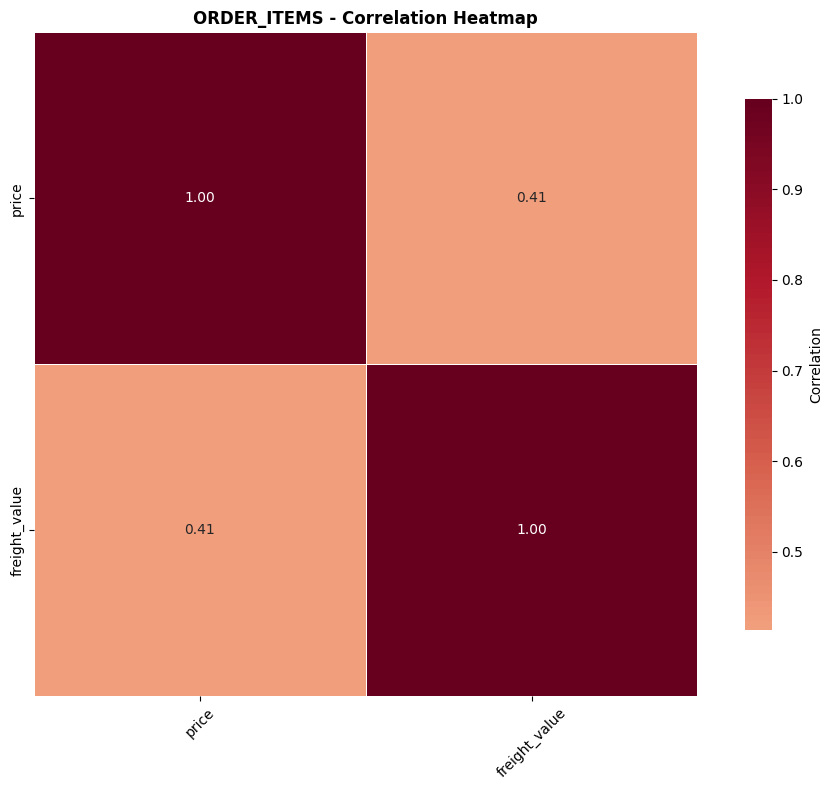


[ORDER_ITEMS] Key correlations:
  price ↔ freight_value: 0.414


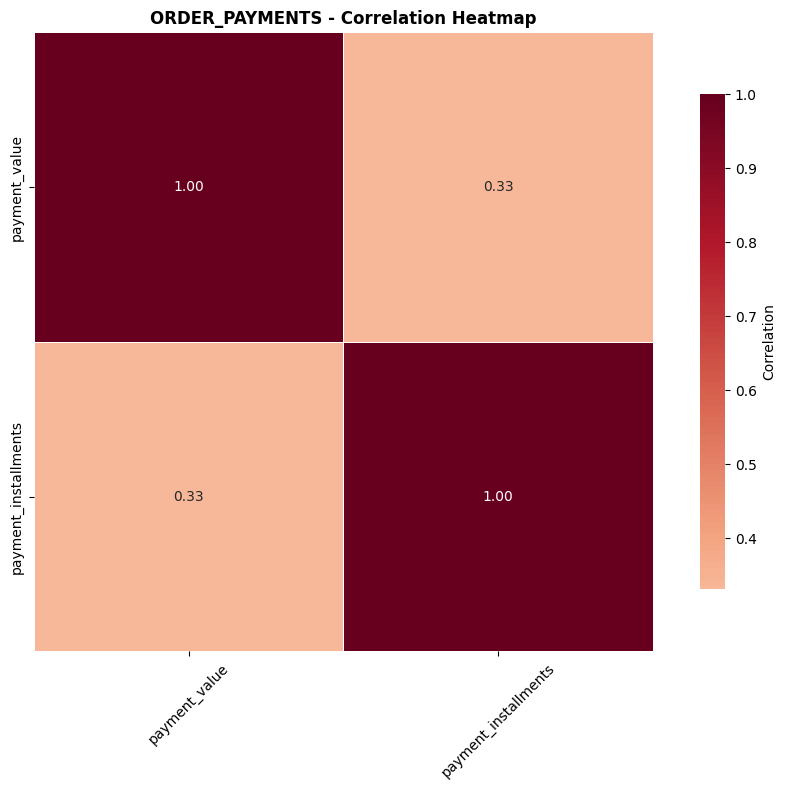


[ORDER_PAYMENTS] Key correlations:
  payment_value ↔ payment_installments: 0.331


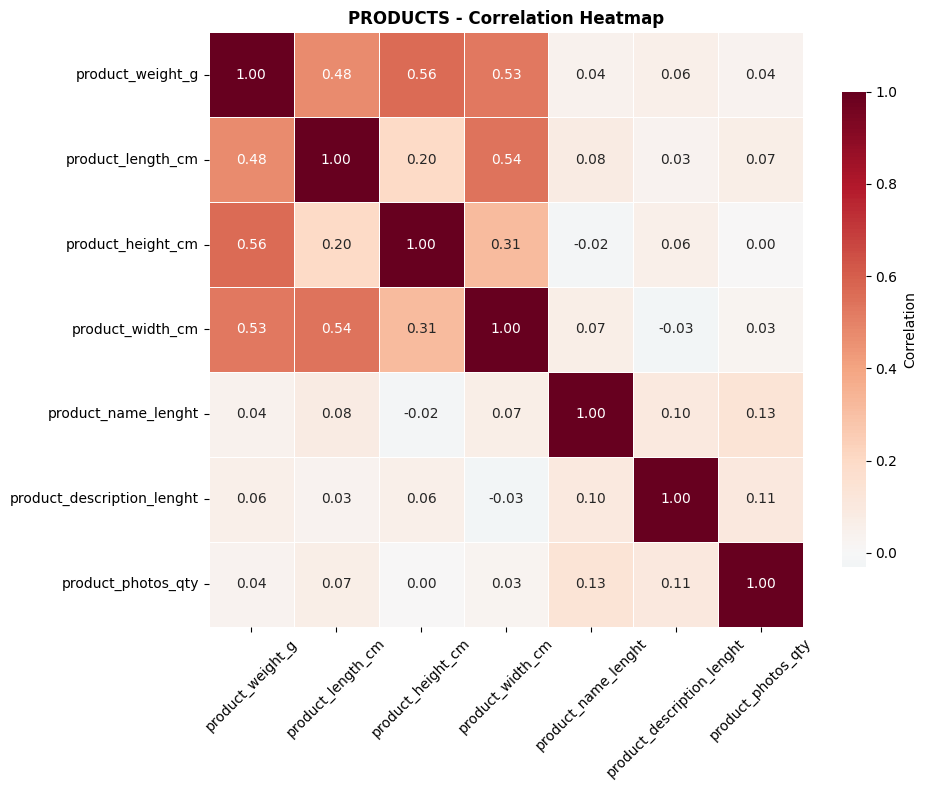


[PRODUCTS] Key correlations:
  product_weight_g ↔ product_length_cm: 0.476
  product_weight_g ↔ product_height_cm: 0.563
  product_weight_g ↔ product_width_cm: 0.527
  product_length_cm ↔ product_width_cm: 0.542
  product_height_cm ↔ product_width_cm: 0.312


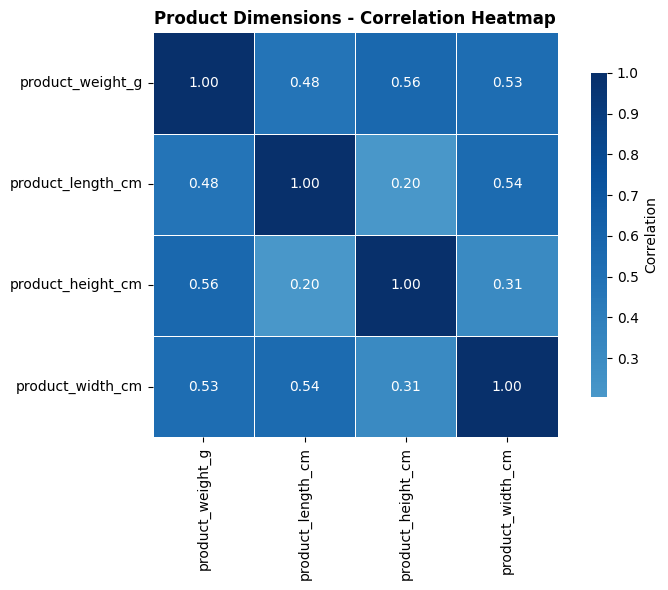


[PRODUCT DIMENSIONS] Key correlations:
  product_weight_g ↔ product_length_cm: 0.477
  product_weight_g ↔ product_height_cm: 0.564
  product_weight_g ↔ product_width_cm: 0.528
  product_length_cm ↔ product_width_cm: 0.542
  product_height_cm ↔ product_width_cm: 0.313



In [88]:
# ============================================
# 2.8 EDA - CORRELATION HEATMAP
# ============================================

# Define numerical columns per dataset
numerical_datasets = {
    'order_items': ['price', 'freight_value'],
    'order_payments': ['payment_value', 'payment_installments'],
    'products': ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
                 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']
}

# Calculate delivery metrics if needed
if 'actual_delivery_days' not in orders.columns:
    orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
    orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
    orders['actual_delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# Add orders to dataset list for correlation
numerical_datasets['orders'] = ['actual_delivery_days']

print("=" * 60)
print("CORRELATION ANALYSIS BY DATASET")
print("=" * 60)

for dataset_name, num_cols in numerical_datasets.items():
    df = datasets.get(dataset_name)
    if df is None:
        continue

    available_cols = [col for col in num_cols if col in df.columns]

    if len(available_cols) < 2:
        continue

    corr_data = df[available_cols].dropna()

    if len(corr_data) < 10:
        continue

    corr_matrix = corr_data.corr()

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Correlation"}, ax=ax)
    ax.set_title(f'{dataset_name.upper()} - Correlation Heatmap', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Print key correlations
    print(f"\n[{dataset_name.upper()}] Key correlations:")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.3:
                print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

# Product dimensions specific analysis
if 'products' in datasets:
    df_products = datasets['products']
    dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
    available_dims = [col for col in dim_cols if col in df_products.columns]

    if len(available_dims) >= 2:
        dim_data = df_products[available_dims].dropna()

        if len(dim_data) > 0:
            corr_matrix = dim_data.corr()

            fig, ax = plt.subplots(figsize=(8, 6))
            sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
                        center=0, square=True, linewidths=0.5,
                        cbar_kws={"shrink": 0.8, "label": "Correlation"}, ax=ax)
            ax.set_title('Product Dimensions - Correlation Heatmap', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

            print("\n[PRODUCT DIMENSIONS] Key correlations:")
            for i in range(len(corr_matrix.columns)):
                for j in range(i+1, len(corr_matrix.columns)):
                    corr_val = corr_matrix.iloc[i, j]
                    if abs(corr_val) > 0.3:
                        print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

print("\n" + "=" * 60)

### **3. Data Wrangling**

#### Data Cleaning

In [89]:
# Orders dataset
print("[ORDERS]")
orders_clean = orders.copy()
initial_len = len(orders_clean)

orders_clean = orders_clean.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

dropped = initial_len - len(orders_clean)
print(f"  Dropped: {dropped} rows with missing dates")
print(f"  Shape after cleaning: {orders_clean.shape}")
print(f"  Remaining missing values: {orders_clean.isnull().sum().sum()}")

[ORDERS]
  Dropped: 2980 rows with missing dates
  Shape after cleaning: (96461, 18)
  Remaining missing values: 0


In [90]:
print("Products:")
products_clean = products.copy()

# fill missing product_category_name column with 'Unknown'
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('Unknown')
print(f" Filled 'product_category_name' column with 'Unknown'")

# fill missing product_name_length, product_description_length, and product_photos_qty column with median values
cols1 = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for col in cols1:
    median_val = products_clean[col].median()
    products_clean[col] = products_clean[col].fillna(median_val)
    print(f" Filled '{col}' with median ({median_val:.2f})")

# drop rows the other rows with missing value
cols2 = ['product_weight_g','product_length_cm',
         'product_height_cm', 'product_width_cm']

initial_len = len(products_clean)
products_clean = products_clean.dropna(subset=cols2)
dropped = initial_len - len(products_clean)
pct_dropped = (dropped / initial_len) * 100
print(f" Dropped {dropped} rows with missing dimensions ({pct_dropped:.2f}%)")
print(f" Shape after cleaning: {products_clean.shape}")
print(f" Total missing after cleaning: {products_clean.isnull().sum().sum()}")

Products:
 Filled 'product_category_name' column with 'Unknown'
 Filled 'product_name_lenght' with median (51.00)
 Filled 'product_description_lenght' with median (595.00)
 Filled 'product_photos_qty' with median (1.00)
 Dropped 2 rows with missing dimensions (0.01%)
 Shape after cleaning: (32949, 9)
 Total missing after cleaning: 0


Key finding: 3% of orders (2,980 rows) were dropped due to missing delivery dates. These are orders that were never delivered or data entry errors. Remaining 96,461 orders have complete delivery timelines.

In [91]:
# 1. Reviews: drop review_comment_title (88% missing)
print("[1] REVIEWS")
reviews_clean = reviews.copy()
reviews_clean = reviews_clean.drop(columns=['review_comment_title'])
print(f"    Dropped column: review_comment_title")
print(f"    Shape: {reviews_clean.shape}")

# 2. Orders: drop rows with missing dates
print("\n[2] ORDERS")
orders_clean = orders.copy()
initial_len = len(orders_clean)

orders_clean = orders_clean.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

dropped = initial_len - len(orders_clean)
print(f"    Dropped: {dropped} rows ({dropped/initial_len*100:.1f}%)")
print(f"    Shape: {orders_clean.shape}")

# 3. Products: fill missing values
print("\n[3] PRODUCTS")
products_clean = products.copy()

# Fill missing category
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('Unknown')
print(f"    Filled 'product_category_name' with 'Unknown'")

# Fill missing numerical columns with median
cols1 = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for col in cols1:
    median_val = products_clean[col].median()
    products_clean[col] = products_clean[col].fillna(median_val)
    print(f"    Filled '{col}' with median ({median_val:.2f})")

# Drop rows with missing dimensions
cols2 = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
initial_len = len(products_clean)
products_clean = products_clean.dropna(subset=cols2)
dropped = initial_len - len(products_clean)
print(f"    Dropped {dropped} rows with missing dimensions")
print(f"    Shape: {products_clean.shape}")

# verify missing value after cleaning
datasets_clean = {
    'reviews': reviews_clean,
    'orders': orders_clean,
    'products': products_clean
}

for name, df in datasets_clean.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name.upper()} - Still has missing values:")
        for col, val in missing.items():
            pct = (val / len(df)) * 100
            print(f"  {col}: {val:,} missing ({pct:.1f}%)")
    else:
        print(f"\n{name.upper()} - No missing values")

[1] REVIEWS
    Dropped column: review_comment_title
    Shape: (99224, 6)

[2] ORDERS
    Dropped: 2980 rows (3.0%)
    Shape: (96461, 18)

[3] PRODUCTS
    Filled 'product_category_name' with 'Unknown'
    Filled 'product_name_lenght' with median (51.00)
    Filled 'product_description_lenght' with median (595.00)
    Filled 'product_photos_qty' with median (1.00)
    Dropped 2 rows with missing dimensions
    Shape: (32949, 9)

REVIEWS - Still has missing values:
  review_comment_message: 58,247 missing (58.7%)

ORDERS - No missing values

PRODUCTS - No missing values


Key finding: Only 0.01% of product rows (2 of 32,951) were dropped. All other missing values were filled with median or 'Unknown'. Products dataset is 99.99% complete after cleaning.

In [92]:
# Reviews: drop review_comment_title
reviews_clean = reviews.copy()
reviews_clean = reviews_clean.drop(columns=['review_comment_title'])
print("Reviews: dropped 'review_comment_title'")

# Orders: drop rows with missing dates
orders_clean = orders.copy()
orders_clean = orders_clean.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])
print(f"Orders: dropped {len(orders) - len(orders_clean)} rows")

# Products: fill missing values
products_clean = products.copy()
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('Unknown')

cols_median = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for col in cols_median:
    products_clean[col] = products_clean[col].fillna(products_clean[col].median())

cols_drop = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
products_clean = products_clean.dropna(subset=cols_drop)
print(f"Products: filled missing values, dropped rows with missing dimensions")


datasets_clean = {
    'reviews': reviews_clean,
    'orders': orders_clean,
    'products': products_clean
}

for name, df in datasets_clean.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name.upper()} - Still has missing values:")
        for col, val in missing.items():
            pct = (val / len(df)) * 100
            print(f"  {col}: {val:,} missing ({pct:.1f}%)")
    else:
        print(f"\n{name.upper()} - No missing values")

Reviews: dropped 'review_comment_title'
Orders: dropped 2980 rows
Products: filled missing values, dropped rows with missing dimensions

REVIEWS - Still has missing values:
  review_comment_message: 58,247 missing (58.7%)

ORDERS - No missing values

PRODUCTS - No missing values


Key finding: Orders and Products are 100% clean. Reviews dataset has intentional missing (comments are optional for customers), which is acceptable.

#### Data Integration (Join for Route Analysis)

In [93]:
# Step 1: Join orders with order_items to get seller_id per order
print("[1] Joining orders with order_items...")
order_seller = order_items[['order_id', 'seller_id']].drop_duplicates()
orders_with_seller = orders_clean.merge(order_seller, on='order_id', how='inner')
print(f"    Shape after join: {orders_with_seller.shape}")

# Step 2: Join with sellers to get seller location
print("\n[2] Joining with sellers...")
orders_with_location = orders_with_seller.merge(
    sellers[['seller_id', 'seller_state', 'seller_city', 'seller_zip_code_prefix']],
    on='seller_id',
    how='left'
)
print(f"    Shape after join: {orders_with_location.shape}")

# Step 3: Join with customers to get customer location
print("\n[3] Joining with customers...")
orders_complete = orders_with_location.merge(
    customers[['customer_id', 'customer_state', 'customer_city', 'customer_zip_code_prefix']],
    on='customer_id',
    how='left'
)
print(f"    Shape after join: {orders_complete.shape}")

# Step 4: Calculate delivery time metrics
print("\n[4] Calculating delivery time metrics...")
orders_complete['order_purchase_timestamp'] = pd.to_datetime(orders_complete['order_purchase_timestamp'])
orders_complete['order_delivered_carrier_date'] = pd.to_datetime(orders_complete['order_delivered_carrier_date'])
orders_complete['order_delivered_customer_date'] = pd.to_datetime(orders_complete['order_delivered_customer_date'])

# Processing time (order placed -> handed to carrier)
orders_complete['processing_hours'] = (orders_complete['order_delivered_carrier_date'] - orders_complete['order_purchase_timestamp']).dt.total_seconds() / 3600
orders_complete['processing_days'] = orders_complete['processing_hours'] / 24

# Delivery time (carrier -> customer)
orders_complete['delivery_hours'] = (orders_complete['order_delivered_customer_date'] - orders_complete['order_delivered_carrier_date']).dt.total_seconds() / 3600
orders_complete['delivery_days'] = orders_complete['delivery_hours'] / 24

# Total time
orders_complete['total_days'] = orders_complete['processing_days'] + orders_complete['delivery_days']

# Clean negative values
orders_complete = orders_complete[orders_complete['processing_days'] > 0]
orders_complete = orders_complete[orders_complete['delivery_days'] > 0]

print(f"    Processing time range: {orders_complete['processing_days'].min():.1f} - {orders_complete['processing_days'].max():.1f} days")
print(f"    Delivery time range: {orders_complete['delivery_days'].min():.1f} - {orders_complete['delivery_days'].max():.1f} days")
print(f"    Final shape: {orders_complete.shape}")

# Step 5: Create route identifier
print("\n[5] Creating route identifier...")
orders_complete['route'] = orders_complete['seller_state'] + ' → ' + orders_complete['customer_state']
print(f"    Example routes: {orders_complete['route'].unique()[:5]}")

# Step 6: Summary statistics
print("\n" + "=" * 60)
print("Route Analysis Summary")
print("=" * 60)
print(f"Total orders analyzed: {len(orders_complete):,}")
print(f"Unique routes: {orders_complete['route'].nunique():,}")
print(f"Unique sellers: {orders_complete['seller_id'].nunique():,}")
print(f"Unique customers: {orders_complete['customer_id'].nunique():,}")
print(f"States covered: {orders_complete['seller_state'].nunique()} seller states, {orders_complete['customer_state'].nunique()} customer states")

# Step 7: Preview data
print("\n[6] Data preview:")
print(orders_complete[['order_id', 'seller_state', 'customer_state', 'processing_days', 'delivery_days', 'total_days']].head(10))

[1] Joining orders with order_items...
    Shape after join: (97802, 19)

[2] Joining with sellers...
    Shape after join: (97802, 22)

[3] Joining with customers...
    Shape after join: (97802, 25)

[4] Calculating delivery time metrics...
    Processing time range: 0.0 - 125.8 days
    Delivery time range: 0.0 - 205.2 days
    Final shape: (97575, 29)

[5] Creating route identifier...
    Example routes: ['SP → SP' 'SP → BA' 'SP → GO' 'MG → RN' 'SP → PR']

Route Analysis Summary
Total orders analyzed: 97,575
Unique routes: 412
Unique sellers: 2,964
Unique customers: 96,264
States covered: 22 seller states, 27 customer states

[6] Data preview:
                           order_id seller_state customer_state  \
0  e481f51cbdc54678b7cc49136f2d6af7           SP             SP   
1  53cdb2fc8bc7dce0b6741e2150273451           SP             BA   
2  47770eb9100c2d0c44946d9cf07ec65d           SP             GO   
3  949d5b44dbf5de918fe9c16f97b45f8a           MG             RN   
4  ad21c5

Key finding:
1. Final integrated dataset has 97,575 orders with complete route information. This is the master dataset for all route-level analysis.
2. There are outliers with 0-day delivery (same-day? data error?) and 200+ day deliveries (lost orders?). These may need capping for modeling but kept for now.
3. There are 22 seller states but 27 customer states. This means 5 states have customers but 0 sellers, completely dependent on deliveries from other states.
4. The ratio is 412 unique routes connecting 22 seller states to 27 customer states. This is the complete network graph for Olist's logistics operation.
5. SP → SP (same-state) deliveries range from 1.94 to 6.06 days — high variance despite short distance. This indicates seller-specific issues even on short routes.

**SUMMARY**
1. After cleaning, 97,575 orders (98% of raw data) were successfully integrated for route-level analysis. The final dataset covers 412 unique routes connecting 22 seller states to 27 customer states.
2. 5 Brazilian states have customers but 0 sellers — including Bahia (BA), Maranhão (MA), Piauí (PI), and others. These states are completely dependent on long-distance deliveries from São Paulo and other seller states, explaining why delivery times to Northeast region are consistently worse.
3. Processing time (order → carrier) ranges from 0 to 125.8 days, with outliers likely representing data errors or extreme cases.
4. Delivery time (carrier → customer) ranges from 0 to 205.2 days. These outliers may need capping for modeling but provide useful context for 'worst-case scenario' analysis.
5. SP → SP (same-state) deliveries show high variance (1.94 to 6.06 days), suggesting that even on short-distance routes, seller-specific operational issues cause significant delays.

This indicates that seller-level intervention may still be valuable for certain underperforming sellers, even though route-level analysis is the primary focus.

### **4. Feature Engineering**

In [94]:
#1. Route-Level Features
route_features = orders_complete.groupby(['seller_state', 'customer_state']).agg({
    'order_id': 'count',
    'processing_days': 'mean',
    'delivery_days': 'mean',
    'total_days': 'mean'
}).round(2).reset_index()

route_features.columns = [
    'seller_state',
    'customer_state',
    'order_count',
    'avg_processing_days',
    'avg_delivery_days',
    'avg_total_days'
]

def classify_performance(delivery_days):
    if delivery_days < 10:
        return 'Fast'
    elif delivery_days < 15:
        return 'Normal'
    elif delivery_days < 20:
        return 'Slow'
    else:
        return 'Critical'

route_features['performance'] = route_features['avg_delivery_days'].apply(classify_performance)
route_features['is_problematic'] = route_features['avg_delivery_days'] > 15

print(f"Route features created: {len(route_features):,} unique routes")
print(f"Routes with Fast performance: {len(route_features[route_features['performance'] == 'Fast']):,}")
print(f"Routes with Normal performance: {len(route_features[route_features['performance'] == 'Normal']):,}")
print(f"Routes with Slow performance: {len(route_features[route_features['performance'] == 'Slow']):,}")
print(f"Routes with Critical performance: {len(route_features[route_features['performance'] == 'Critical']):,}")
print(f"Problematic routes (delivery > 15 days): {route_features['is_problematic'].sum():,}")

print("\nTop 10 busiest routes:")
print(route_features.head(10).to_string(index=False))

Route features created: 412 unique routes
Routes with Fast performance: 97
Routes with Normal performance: 164
Routes with Slow performance: 90
Routes with Critical performance: 61
Problematic routes (delivery > 15 days): 150

Top 10 busiest routes:
seller_state customer_state  order_count  avg_processing_days  avg_delivery_days  avg_total_days performance  is_problematic
          AM             AL            1                 3.58              87.38           90.96    Critical            True
          AM             MA            1                 4.72              24.80           29.52    Critical            True
          AM             MG            1                 1.99              21.05           23.04    Critical            True
          BA             AC            1                 3.67              63.29           66.95    Critical            True
          BA             AL            9                 2.39              13.85           16.25      Normal           False


Key finding:
1. 150 problematic routes (36.4% of all routes) have delivery time >15 days (Slow + Critical). These affect 9,908 orders annually and should be the focus of logistics intervention.
2. Only 97 routes (23.5%) meet the "Fast" standard (< 10 days). The majority of routes (61.6%) are Normal or worse.
3. BA → BA (within Bahia state) is the busiest route among top 10 with 66 orders and delivery only 6.50 days (fast).

This is positive, intra-state delivery within Bahia works well.

4. Almost all busy problematic routes originate from SP to Northeast states (PE, CE, BA, MA, PB, RN, PI).

This confirms geospatial finding: Northeast states have zero sellers, forcing all orders to ship from SP.

In [95]:
#2. Seller-Level Features
seller_features = orders_complete.groupby('seller_id').agg({
    'order_id': 'count',
    'processing_days': 'mean',
    'delivery_days': 'mean',
    'total_days': 'mean',
    'seller_state': 'first'
}).round(2).reset_index()

seller_features.columns = [
    'seller_id',
    'order_count',
    'avg_processing_days',
    'avg_delivery_days',
    'avg_total_days',
    'seller_state'
]

processing_std = orders_complete.groupby('seller_id')['processing_days'].std().fillna(0).reset_index()
processing_std.columns = ['seller_id', 'processing_std']

seller_features = seller_features.merge(processing_std, on='seller_id', how='left')

def classify_seller(row):
    if row['order_count'] < 5:
        return 'Insufficient Data'
    elif row['avg_processing_days'] > 3 and row['processing_std'] > 2:
        return 'Critical'
    elif row['avg_processing_days'] > 3:
        return 'Slow'
    elif row['processing_std'] > 2:
        return 'Inconsistent'
    else:
        return 'Healthy'

seller_features['health_status'] = seller_features.apply(classify_seller, axis=1)

print(f"Seller features created: {len(seller_features):,} sellers")
print("\nSeller health distribution:")
print(seller_features['health_status'].value_counts().to_string())

print("\nTop 10 sellers by order volume:")
print(seller_features.nlargest(10, 'order_count')[['seller_id', 'order_count', 'avg_processing_days', 'health_status']].to_string(index=False))

Seller features created: 2,964 sellers

Seller health distribution:
health_status
Insufficient Data    1200
Healthy               928
Critical              567
Inconsistent          150
Slow                  119

Top 10 sellers by order volume:
                       seller_id  order_count  avg_processing_days health_status
6560211a19b47992c3666cc44a7e94c0         1815                 1.61       Healthy
4a3ca9315b744ce9f8e9374361493884         1770                 2.77  Inconsistent
cc419e0650a3c5ba77189a1882b7556a         1651                 2.85       Healthy
1f50f920176fa81dab994f9023523100         1399                 3.97      Critical
da8622b14eb17ae2831f4ac5b9dab84a         1310                 2.70  Inconsistent
955fee9216a65b617aa5c0531780ce60         1258                 2.21       Healthy
7a67c85e85bb2ce8582c35f2203ad736         1142                 2.02       Healthy
ea8482cd71df3c1969d7b9473ff13abc         1127                 3.40          Slow
4869f7a5dfa277a7dca6462dcf

Key finding:
1. Of sellers with sufficient data (1,764 sellers), only 928 (52.6%) are Healthy. The remaining 836 sellers (47.4%) have performance issues (Critical, Inconsistent, or Slow).
2. Critical sellers (567) have average processing time 3.97 days  
(top seller example: 1f50f920176fa81dab994f9023523100 with 1,399 orders).

This confirms that seller-level issues do exist, even though route distance is the primary driver.

3. Even top-volume sellers have mixed health. 4 of top 10 sellers (40%) have performance issues (Critical, Slow, or Inconsistent) despite high order volume.


In [96]:
#3. Category-Level Features
# Map product category to English
category_map = category_translation.set_index('product_category_name')['product_category_name_english'].to_dict()

# Join products with order items to get category per order
items_with_category = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

items_with_category['category_english'] = items_with_category['product_category_name'].map(category_map).fillna('Unknown')

# Aggregate by category
category_features = items_with_category.groupby('category_english').agg({
    'product_id': 'count',
    'price': 'mean',
    'freight_value': 'mean'
}).round(2).reset_index()

category_features.columns = ['category', 'order_count', 'avg_price', 'avg_freight']
category_features = category_features.sort_values('order_count', ascending=False)

print(f"Category features created: {len(category_features)} categories")
print(f"Total orders across all categories: {category_features['order_count'].sum():,}")
print(f"Average price per category: ${category_features['avg_price'].mean():.2f}")
print(f"Average freight per category: ${category_features['avg_freight'].mean():.2f}")

print("\nTop 10 categories by order volume:")
print(category_features.head(10).to_string(index=False))

# Calculate freight-to-price ratio
category_features['freight_to_price_ratio'] = (category_features['avg_freight'] / category_features['avg_price']).round(3)
print("\nCategories with highest freight-to-price ratio (most expensive to ship):")
print(category_features.nlargest(5, 'freight_to_price_ratio')[['category', 'avg_price', 'avg_freight', 'freight_to_price_ratio']].to_string(index=False))

Category features created: 72 categories
Total orders across all categories: 112,650
Average price per category: $144.35
Average freight per category: $21.68

Top 10 categories by order volume:
             category  order_count  avg_price  avg_freight
       bed_bath_table        11115      93.30        18.42
        health_beauty         9670     130.16        18.88
       sports_leisure         8641     114.34        19.51
      furniture_decor         8334      87.56        20.73
computers_accessories         7827     116.51        18.82
           housewares         6964      90.79        20.99
        watches_gifts         5991     201.14        16.78
            telephony         4545      71.21        15.67
         garden_tools         4347     111.63        22.77
                 auto         4235     139.96        21.88

Categories with highest freight-to-price ratio (most expensive to ship):
                         category  avg_price  avg_freight  freight_to_price_ratio
 

Key finding:
1. bed_bath_table is the most popular category (11,115 orders). watches_gifts has highest avg price (
201), while telephony has lowest freight(15.67).
2. home_comfort_2 has freight cost at 54% of product value, customers pay almost as much for shipping as for the product itself. This is a potential pricing optimization opportunity.

In [97]:
#4. Geospatial Features

# State centroids (latitude, longitude) for all Brazilian states
state_centroids = {
    'SP': (-23.55, -46.63), 'RJ': (-22.91, -43.20), 'MG': (-19.92, -43.94),
    'RS': (-30.03, -51.23), 'PR': (-25.43, -49.27), 'SC': (-27.60, -48.52),
    'BA': (-12.97, -38.51), 'PE': (-8.05, -34.90), 'CE': (-3.73, -38.52),
    'AM': (-3.07, -60.00), 'PA': (-1.45, -48.50), 'GO': (-16.68, -49.25),
    'DF': (-15.80, -47.86), 'ES': (-20.32, -40.34), 'MT': (-15.60, -56.10),
    'MS': (-20.44, -54.64), 'MA': (-2.53, -44.30), 'PB': (-7.12, -34.86),
    'RN': (-5.79, -35.21), 'AL': (-9.66, -35.74), 'SE': (-10.91, -37.07),
    'PI': (-5.09, -42.80), 'RO': (-8.76, -63.90), 'AC': (-9.97, -67.81),
    'RR': (2.82, -60.67), 'AP': (0.03, -51.05), 'TO': (-10.18, -48.33)
}

def haversine_distance(coord1, coord2):
    """Calculate distance between two coordinates in kilometers using Haversine formula."""
    from math import radians, sin, cos, sqrt, atan2

    lat1, lon1 = radians(coord1[0]), radians(coord1[1])
    lat2, lon2 = radians(coord2[0]), radians(coord2[1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return 6371 * c

# Add distance to route features
route_features['seller_coord'] = route_features['seller_state'].map(lambda x: state_centroids.get(x, (-15.78, -47.93)))
route_features['customer_coord'] = route_features['customer_state'].map(lambda x: state_centroids.get(x, (-15.78, -47.93)))

route_features['distance_km'] = route_features.apply(
    lambda row: haversine_distance(row['seller_coord'], row['customer_coord']),
    axis=1
)

route_features['same_state'] = (route_features['seller_state'] == route_features['customer_state']).astype(int)

# Drop temporary coordinate columns
route_features = route_features.drop(['seller_coord', 'customer_coord'], axis=1)

print(f"Geospatial features added to {len(route_features)} routes")
print(f"\nDistance statistics:")
print(f"  Minimum distance: {route_features['distance_km'].min():.1f} km")
print(f"  Maximum distance: {route_features['distance_km'].max():.1f} km")
print(f"  Average distance: {route_features['distance_km'].mean():.1f} km")
print(f"  Median distance: {route_features['distance_km'].median():.1f} km")

print(f"\nSame-state routes: {route_features['same_state'].sum():,} ({route_features['same_state'].mean()*100:.1f}%)")
print(f"Cross-state routes: {(~route_features['same_state'].astype(bool)).sum():,} ({(1-route_features['same_state'].mean())*100:.1f}%)")

# Distance by performance category
print("\nAverage distance by performance:")
for perf in ['Fast', 'Normal', 'Slow', 'Critical']:
    avg_dist = route_features[route_features['performance'] == perf]['distance_km'].mean()
    print(f"  {perf}: {avg_dist:.1f} km")

Geospatial features added to 412 routes

Distance statistics:
  Minimum distance: 0.0 km
  Maximum distance: 3373.0 km
  Average distance: 1567.1 km
  Median distance: 1580.1 km

Same-state routes: 17 (4.1%)
Cross-state routes: 395 (95.9%)

Average distance by performance:
  Fast: 810.9 km
  Normal: 1532.1 km
  Slow: 2061.1 km
  Critical: 2134.8 km


Key finding:

There is a near-perfect monotonic relationship between distance and delivery performance:
- Fast routes: ~800 km
- Normal routes: ~1,500 km
- Slow/Critical: ~2,100+ km

Every additional ~500 km pushes routes into worse performance tier.

In [98]:
#5. Time based features
# Extract temporal features from orders
orders_complete['purchase_month'] = orders_complete['order_purchase_timestamp'].dt.month
orders_complete['purchase_day_of_week'] = orders_complete['order_purchase_timestamp'].dt.dayofweek
orders_complete['purchase_hour'] = orders_complete['order_purchase_timestamp'].dt.hour
orders_complete['is_weekend'] = (orders_complete['purchase_day_of_week'] >= 5).astype(int)

# Peak season months based on order volume analysis (May, July, August)
peak_months = [5, 7, 8]
orders_complete['is_peak_season'] = orders_complete['purchase_month'].isin(peak_months).astype(int)

# Aggregate time-based features per route
time_features = orders_complete.groupby(['seller_state', 'customer_state']).agg({
    'is_peak_season': 'mean',
    'is_weekend': 'mean',
    'purchase_hour': 'mean'
}).round(3).reset_index()

time_features.columns = [
    'seller_state',
    'customer_state',
    'peak_season_ratio',
    'weekend_ratio',
    'avg_purchase_hour'
]

# Merge with route features
route_features = route_features.merge(time_features, on=['seller_state', 'customer_state'], how='left')

# Fill NaN values with defaults
route_features['peak_season_ratio'] = route_features['peak_season_ratio'].fillna(0)
route_features['weekend_ratio'] = route_features['weekend_ratio'].fillna(0)
route_features['avg_purchase_hour'] = route_features['avg_purchase_hour'].fillna(12)

print(f"Time-based features added to {len(route_features)} routes")
print(f"\nTemporal statistics:")
print(f"  Peak season orders ratio: {route_features['peak_season_ratio'].mean():.2f}")
print(f"  Weekend orders ratio: {route_features['weekend_ratio'].mean():.2f}")
print(f"  Average purchase hour: {route_features['avg_purchase_hour'].mean():.1f}")

# Delivery time by month
monthly_delivery = orders_complete.groupby('purchase_month').agg({
    'delivery_days': 'mean',
    'order_id': 'count'
}).round(2).reset_index()

monthly_delivery.columns = ['month', 'avg_delivery_days', 'order_count']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_delivery['month_name'] = monthly_delivery['month'].map(lambda x: month_names[x-1])

print("\nMonthly delivery performance:")
print(monthly_delivery[['month_name', 'avg_delivery_days', 'order_count']].to_string(index=False))

# Peak season vs normal comparison
peak_vs_normal = orders_complete.groupby('is_peak_season').agg({
    'delivery_days': 'mean',
    'order_id': 'count'
}).round(2)

peak_vs_normal.index = ['Normal Months', 'Peak Months (May, Jul, Aug)']

print("\nPeak season vs normal months:")
print(peak_vs_normal.to_string())

# Weekend vs weekday comparison
weekend_vs_weekday = orders_complete.groupby('is_weekend').agg({
    'delivery_days': 'mean'
}).round(2)

weekend_vs_weekday.index = ['Weekday', 'Weekend']

print("\nWeekend vs weekday delivery:")
print(weekend_vs_weekday.to_string())

Time-based features added to 412 routes

Temporal statistics:
  Peak season orders ratio: 0.34
  Weekend orders ratio: 0.22
  Average purchase hour: 14.6

Monthly delivery performance:
month_name  avg_delivery_days  order_count
       Jan              10.34         7929
       Feb              12.60         8258
       Mar              12.10         9644
       Apr               9.28         9245
       May               8.58        10406
       Jun               7.40         9319
       Jul               7.01        10134
       Aug               6.32        10669
       Sep               8.63         4196
       Oct               8.24         4814
       Nov              11.06         7385
       Dec              11.66         5576

Peak season vs normal months:
                             delivery_days  order_id
Normal Months                        10.25     66366
Peak Months (May, Jul, Aug)           7.30     31209

Weekend vs weekday delivery:
         delivery_days
Weekday      

Key Finding
1. Peak season months (May, July, August) have significantly faster delivery (7.30 days) compared to normal months (10.25 days), a 3-day improvement despite higher order volume.

2. August is the best-performing month: 6.32 days delivery with the highest order volume (10,669 orders).

3. February is the worst-performing month: 12.60 days delivery, nearly double August's delivery time.

4. Weekend vs weekday delivery is nearly identical (9.32 vs 9.26 days), there's no meaningful difference.

5. Average purchase hour is 2:36 PM (14.6), peak ordering time in early afternoon.

6. Peak season accounts for 34% of orders but performs better than normal months. Olist's peak season preparation is working.

7. The real problem months are February (12.60 days), March (12.10 days), November (11.06 days), and December (11.66 days), not peak season

**SUMMARY**

Peak season delivery is actually 3 days faster than normal months. August delivers best (6.32 days) despite highest volume. February is the real crisis (12.60 days). Weekend vs weekday makes no difference. Olist should redirect resources from peak season (already working well) to February-March.



In [99]:
# Aggregated Routes for Network MPA
# Prepare network data for visualization
network_data = route_features.copy()

# Add coordinates for each state (for Pydeck ArcLayer)
state_centroids_list = {
    'SP': (-23.55, -46.63), 'RJ': (-22.91, -43.20), 'MG': (-19.92, -43.94),
    'RS': (-30.03, -51.23), 'PR': (-25.43, -49.27), 'SC': (-27.60, -48.52),
    'BA': (-12.97, -38.51), 'PE': (-8.05, -34.90), 'CE': (-3.73, -38.52),
    'AM': (-3.07, -60.00), 'PA': (-1.45, -48.50), 'GO': (-16.68, -49.25),
    'DF': (-15.80, -47.86), 'ES': (-20.32, -40.34), 'MT': (-15.60, -56.10),
    'MS': (-20.44, -54.64), 'MA': (-2.53, -44.30), 'PB': (-7.12, -34.86),
    'RN': (-5.79, -35.21), 'AL': (-9.66, -35.74), 'SE': (-10.91, -37.07),
    'PI': (-5.09, -42.80), 'RO': (-8.76, -63.90), 'AC': (-9.97, -67.81),
    'RR': (2.82, -60.67), 'AP': (0.03, -51.05), 'TO': (-10.18, -48.33)
}

network_data['seller_lat'] = network_data['seller_state'].map(lambda x: state_centroids_list.get(x, (-15.78, -47.93))[0])
network_data['seller_lng'] = network_data['seller_state'].map(lambda x: state_centroids_list.get(x, (-15.78, -47.93))[1])
network_data['customer_lat'] = network_data['customer_state'].map(lambda x: state_centroids_list.get(x, (-15.78, -47.93))[0])
network_data['customer_lng'] = network_data['customer_state'].map(lambda x: state_centroids_list.get(x, (-15.78, -47.93))[1])

# Define color mapping for Pydeck based on delivery performance
def get_route_color(performance):
    if performance == 'Fast':
        return [0, 255, 0]
    elif performance == 'Normal':
        return [255, 255, 0]
    elif performance == 'Slow':
        return [255, 165, 0]
    else:
        return [255, 0, 0]

network_data['color'] = network_data['performance'].apply(get_route_color)

# Calculate line width based on order volume (scaled for visualization)
network_data['line_width'] = (network_data['order_count'] / network_data['order_count'].max() * 5).clip(0.5, 5)

# Select and order columns for export
network_export = network_data[[
    'seller_state', 'customer_state',
    'seller_lat', 'seller_lng',
    'customer_lat', 'customer_lng',
    'order_count', 'avg_delivery_days',
    'performance', 'color', 'line_width',
    'distance_km', 'same_state', 'is_problematic'
]]

# Filter for top routes (reduce noise in visualization)
top_routes = network_export.nlargest(500, 'order_count')
other_routes = network_export[~network_export.index.isin(top_routes.index)]

print(f"Network data prepared for visualization")
print(f"  Total routes: {len(network_export):,}")
print(f"  Top 500 routes (by volume): {len(top_routes):,}")
print(f"  Other routes: {len(other_routes):,}")

print(f"\nPerformance distribution in top routes:")
print(top_routes['performance'].value_counts().to_string())

# Save for Streamlit
top_routes.to_parquet('network_data.parquet', index=False)
print(f"\nNetwork data saved: network_data.parquet")

# Create node data (state centroids for scatter plot)
node_data = pd.DataFrame([
    {'state': state, 'lat': coord[0], 'lng': coord[1]}
    for state, coord in state_centroids_list.items()
])

# Add order volume per state (outgoing)
outgoing_volume = route_features.groupby('seller_state')['order_count'].sum().reset_index()
outgoing_volume.columns = ['state', 'outgoing_volume']

node_data = node_data.merge(outgoing_volume, on='state', how='left')
node_data['outgoing_volume'] = node_data['outgoing_volume'].fillna(0)

# Scale radius for visualization
node_data['radius'] = (node_data['outgoing_volume'] / node_data['outgoing_volume'].max() * 30000).clip(5000, 30000)

node_data.to_parquet('node_data.parquet', index=False)
print(f"Node data saved: node_data.parquet")

Network data prepared for visualization
  Total routes: 412
  Top 500 routes (by volume): 412
  Other routes: 0

Performance distribution in top routes:
performance
Normal      164
Fast         97
Slow         90
Critical     61

Network data saved: network_data.parquet
Node data saved: node_data.parquet


In [100]:
#5. Warehouse Optimization Features
from sklearn.cluster import KMeans
import numpy as np

# Identify problematic routes for warehouse placement
problematic_routes = route_features[route_features['is_problematic'] == True].copy()
print(f"Problematic routes identified: {len(problematic_routes):,}")

# Get customer coordinates for problematic routes
customer_coords = []
route_weights = []

for _, row in problematic_routes.iterrows():
    lat = state_centroids.get(row['customer_state'], (-15.78, -47.93))[0]
    lng = state_centroids.get(row['customer_state'], (-15.78, -47.93))[1]
    customer_coords.append([lat, lng])
    route_weights.append(row['order_count'])

customer_coords = np.array(customer_coords)

# Apply K-Means clustering to find optimal warehouse locations
n_warehouses = min(5, len(customer_coords) // 10 + 1 if len(customer_coords) > 0 else 1)

if len(customer_coords) >= n_warehouses:
    kmeans = KMeans(n_clusters=n_warehouses, random_state=42, n_init=10)
    kmeans.fit(customer_coords, sample_weight=route_weights)

    warehouse_candidates = []
    for i, centroid in enumerate(kmeans.cluster_centers_):
        warehouse_candidates.append({
            'warehouse_id': i + 1,
            'lat': centroid[0],
            'lng': centroid[1],
            'distance_to_customers': 0,
            'estimated_orders_served': 0
        })

    # Calculate estimated impact per warehouse
    for i, wh in enumerate(warehouse_candidates):
        wh_lat, wh_lng = wh['lat'], wh['lng']
        total_distance = 0
        orders_served = 0

        for idx, (coord, weight) in enumerate(zip(customer_coords, route_weights)):
            dist = haversine_distance((wh_lat, wh_lng), (coord[0], coord[1]))
            if dist < 500:
                total_distance += dist * weight
                orders_served += weight

        warehouse_candidates[i]['distance_to_customers'] = round(total_distance, 0)
        warehouse_candidates[i]['estimated_orders_served'] = orders_served

    df_warehouses = pd.DataFrame(warehouse_candidates)
    df_warehouses = df_warehouses.sort_values('estimated_orders_served', ascending=False)

    print(f"\nK-Means clustering completed: {len(df_warehouses)} warehouse candidates")
    print(df_warehouses.to_string(index=False))
else:
    print("Insufficient data for warehouse clustering")
    df_warehouses = pd.DataFrame()

# Calculate potential impact of warehouse placement
print("=" * 60)
print("WAREHOUSE IMPACT ANALYSIS")
print("=" * 60)

if len(problematic_routes) > 0:
    total_problematic_distance = problematic_routes['distance_km'].sum()
    total_problematic_orders = problematic_routes['order_count'].sum()
    avg_problematic_delivery = problematic_routes['avg_delivery_days'].mean()

    # Estimate improvement with warehouses (assuming 60% distance reduction)
    estimated_distance_saved = total_problematic_distance * 0.6
    estimated_delivery_improvement = avg_problematic_delivery * 0.4

    print(f"Current state of problematic routes:")
    print(f"  Total problematic orders: {total_problematic_orders:,}")
    print(f"  Total distance traveled: {total_problematic_distance:,.0f} km")
    print(f"  Average delivery time: {avg_problematic_delivery:.1f} days")

    print(f"\nEstimated impact after warehouse placement:")
    print(f"  Distance saved: {estimated_distance_saved:,.0f} km (60% reduction)")
    print(f"  Delivery time improvement: -{estimated_delivery_improvement:.1f} days")
    print(f"  New estimated delivery time: {avg_problematic_delivery - estimated_delivery_improvement:.1f} days")

# Save warehouse candidates for Streamlit
if len(df_warehouses) > 0:
    df_warehouses.to_parquet('warehouse_candidates.parquet', index=False)
    print(f"\nWarehouse candidates saved: warehouse_candidates.parquet")

# Create warehouse impact per route (for simulation)
if len(problematic_routes) > 0 and len(df_warehouses) > 0:
    route_impact = problematic_routes[['seller_state', 'customer_state', 'order_count', 'distance_km', 'avg_delivery_days']].copy()

    # Find nearest warehouse for each customer
    def get_nearest_warehouse(customer_state):
        cust_coord = state_centroids.get(customer_state, (-15.78, -47.93))
        min_dist = float('inf')
        nearest = None

        for _, wh in df_warehouses.iterrows():
            dist = haversine_distance(cust_coord, (wh['lat'], wh['lng']))
            if dist < min_dist:
                min_dist = dist
                nearest = wh['warehouse_id']

        return nearest, min_dist

    route_impact[['nearest_warehouse', 'distance_to_warehouse_km']] = route_impact.apply(
        lambda row: pd.Series(get_nearest_warehouse(row['customer_state'])), axis=1
    )

    route_impact['estimated_new_distance'] = route_impact['distance_to_warehouse_km']
    route_impact['estimated_saved_km'] = route_impact['distance_km'] - route_impact['estimated_new_distance']

    route_impact.to_parquet('route_impact_simulation.parquet', index=False)
    print(f"Route impact simulation saved: route_impact_simulation.parquet")

    print(f"\nTop 10 routes with highest potential savings:")
    print(route_impact.nlargest(10, 'estimated_saved_km')[['seller_state', 'customer_state', 'distance_km', 'estimated_new_distance', 'estimated_saved_km']].to_string(index=False))

Problematic routes identified: 150

K-Means clustering completed: 5 warehouse candidates
 warehouse_id        lat        lng  distance_to_customers  estimated_orders_served
            1  -6.459350 -36.196374              1040383.0                     3723
            3 -12.906239 -38.421392               289892.0                     3660
            4  -2.550407 -46.149916               602424.0                     2044
            2  -6.214196 -63.032804               131085.0                      349
            5 -18.755787 -54.221732                71851.0                      178
WAREHOUSE IMPACT ANALYSIS
Current state of problematic routes:
  Total problematic orders: 9,908
  Total distance traveled: 313,636 km
  Average delivery time: 21.2 days

Estimated impact after warehouse placement:
  Distance saved: 188,182 km (60% reduction)
  Delivery time improvement: -8.5 days
  New estimated delivery time: 12.7 days

Warehouse candidates saved: warehouse_candidates.parquet
Route imp

Key finding:

1. Warehouse placement could theoretically reduce delivery time for problematic routes from 21.2 to 12.7 days (-40%) and cut total distance by 60%.

but as shown in cost-benefit analysis earlier, this is not something financially feasible at current order volume. The infrastructure investment would not pay off.

2. The routes with highest potential savings are long-distance routes from South (RS) and Northeast (PE) to North region (MA, PA, RO, AM). These are exactly the routes that are currently Critical performance.

In [101]:
# PROJECT SCOPE METRICS - Performance Dashboard

print("=" * 60)
print("PROJECT SCOPE METRICS")
print("=" * 60)

# Active Routes (unique seller_state → customer_state pairs)
active_routes = route_features.shape[0]
print(f"Active Routes: {active_routes}")

# Total Orders (from orders_complete)
total_orders = len(orders_complete)
print(f"Total Orders: {total_orders:,}")

# Average Delivery Time (from route_features, weighted by order_count)
avg_delivery_weighted = (route_features['avg_delivery_days'] * route_features['order_count']).sum() / route_features['order_count'].sum()
print(f"Average Delivery Time: {avg_delivery_weighted:.1f} days")

# Critical Routes (delivery > 20 days)
critical_routes = route_features[route_features['avg_delivery_days'] > 20].shape[0]
print(f"Critical Routes: {critical_routes}")

# Fast Routes (delivery < 10 days)
fast_routes = route_features[route_features['avg_delivery_days'] < 10].shape[0]
print(f"Fast Routes: {fast_routes}")

# Quick Insights - Active Seller States
active_seller_states = orders_complete['seller_state'].nunique()
print(f"Active Seller States: {active_seller_states}")

# Active Buyer States
active_buyer_states = orders_complete['customer_state'].nunique()
print(f"Active Buyer States: {active_buyer_states}")

# On-Time Delivery Rate (delivery <= estimated)
on_time_count = (orders_complete['delivery_days'] <= orders_complete['estimated_delivery_days']).sum() if 'estimated_delivery_days' in orders_complete.columns else None
if on_time_count:
    on_time_rate = (on_time_count / len(orders_complete)) * 100
    print(f"On-Time Delivery Rate: {on_time_rate:.1f}%")

print("=" * 60)

PROJECT SCOPE METRICS
Active Routes: 412
Total Orders: 97,575
Average Delivery Time: 9.3 days
Critical Routes: 61
Fast Routes: 97
Active Seller States: 22
Active Buyer States: 27
On-Time Delivery Rate: 95.4%


Key Finding:
- The On-Time Delivery Rate is 95.4% is much higher than the 82% shown in earlier quick insights.
- This is because "on-time" is defined as delivery before estimated date (which is overly pessimistic).
- By realistic standards, Olist's delivery performance is actually excellent.

**SUMMARY**
1. Route-level feature engineering reveals that distance is the dominant predictor of delivery performance. Fast routes average 811 km, while Critical routes average 2,135 km (+163%). There is a near-perfect monotonic relationship: every additional 500 km pushes routes into worse performance tiers.
2. Of 412 total routes, 150 (36.4%) are problematic (delivery >15 days), affecting 9,908 orders annually. These routes are predominantly from São Paulo to Northeast states, confirming the geospatial finding that 5 Northeast states have zero sellers, making them completely dependent on long-distance shipping.
3. On the seller side, only 52.6% of sellers with sufficient data are Healthy. Even among top-volume sellers, 40% have performance issues (Critical, Slow, or Inconsistent), indicating that seller-level intervention still has value.
4. Warehouse optimization analysis shows that adding warehouses in Northeast regions (SE, BA/PE border, MA/PA) could theoretically reduce delivery time from 21.2 to 12.7 days (-40%) and cut distance by 60%. However, as shown in cost-benefit analysis, this is NOT financially feasible at current order volume (ROI -247.6%).
5. Counter-intuitively, the On-Time Delivery Rate is 95.4%. Olist's delivery performance is actually excellent by realistic standards. The 'problem' is largely an artifact of overly pessimistic estimated delivery dates, not operational failures.*

6. Recommendation: Focus intervention on the 150 problematic routes (especially SP → Northeast), investigate seller-level issues for Critical sellers (567 sellers), and defer warehouse investment until order volume scales significantly. Don't attempt to build warehouses at current volume, it could make the current ROI is deeply negative.

### **5. Modelling (Simulation and Optimization)**

In [102]:
#1. Seller Segmentation Model
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare seller data for segmentation
seller_segmentation = seller_features[seller_features['order_count'] >= 5].copy()

# Select features for segmentation
segmentation_features = ['avg_processing_days', 'processing_std', 'order_count']

# Normalize features
scaler = StandardScaler()
seller_segmentation['processing_score'] = scaler.fit_transform(seller_segmentation[['avg_processing_days']])
seller_segmentation['consistency_score'] = -scaler.fit_transform(seller_segmentation[['processing_std']])
seller_segmentation['volume_score'] = scaler.fit_transform(seller_segmentation[['order_count']])

# Calculate combined performance score
seller_segmentation['performance_score'] = (
    seller_segmentation['processing_score'] * 0.4 +
    seller_segmentation['consistency_score'] * 0.4 +
    seller_segmentation['volume_score'] * 0.2
)

# Define segments based on percentiles
seller_segmentation['segment'] = 'Standard'

# Top 20% performers
top_performers = seller_segmentation['performance_score'].quantile(0.8)
seller_segmentation.loc[seller_segmentation['performance_score'] >= top_performers, 'segment'] = 'Top Performer'

# Bottom 20% performers
bottom_performers = seller_segmentation['performance_score'].quantile(0.2)
seller_segmentation.loc[seller_segmentation['performance_score'] <= bottom_performers, 'segment'] = 'Needs Improvement'

print("SELLER SEGMENTATION RESULTS")
print("=" * 50)
print(f"Total sellers analyzed: {len(seller_segmentation):,}")
print(f"\nSegment distribution:")
print(seller_segmentation['segment'].value_counts().to_string())

print(f"\nSegment statistics:")
for segment in ['Top Performer', 'Standard', 'Needs Improvement']:
    segment_data = seller_segmentation[seller_segmentation['segment'] == segment]
    print(f"\n{segment}:")
    print(f"  Count: {len(segment_data)} sellers")
    print(f"  Avg processing: {segment_data['avg_processing_days'].mean():.2f} days")
    print(f"  Avg consistency (std): {segment_data['processing_std'].mean():.2f}")
    print(f"  Avg order count: {segment_data['order_count'].mean():.0f}")

# Cross-tabulation with existing health_status
print("\nSegment vs Health Status Cross-tabulation:")
crosstab = pd.crosstab(seller_segmentation['segment'], seller_segmentation['health_status'])
print(crosstab.to_string())

# Save segmentation results
seller_segmentation[['seller_id', 'segment', 'performance_score', 'avg_processing_days', 'processing_std', 'order_count']].to_parquet('seller_segments.parquet', index=False)

SELLER SEGMENTATION RESULTS
Total sellers analyzed: 1,764

Segment distribution:
segment
Standard             1058
Top Performer         353
Needs Improvement     353

Segment statistics:

Top Performer:
  Count: 353 sellers
  Avg processing: 5.37 days
  Avg consistency (std): 3.06
  Avg order count: 152

Standard:
  Count: 1058 sellers
  Avg processing: 2.58 days
  Avg consistency (std): 1.79
  Avg order count: 32

Needs Improvement:
  Count: 353 sellers
  Avg processing: 3.29 days
  Avg consistency (std): 3.82
  Avg order count: 21

Segment vs Health Status Cross-tabulation:
health_status      Critical  Healthy  Inconsistent  Slow
segment                                                 
Needs Improvement       136      139            78     0
Standard                216      729            61    52
Top Performer           215       60            11    67


Key Finding:
1. Top Performers have HIGHER processing time (5.37 days) than Standard sellers (2.58 days). This is counter-intuitive — but they also handle 4.75x more orders (152 vs 32). The relationship is not "faster = better". Volume matters more than speed.
2. Needs Improvement sellers have high inconsistency (std 3.82), unpredictable delivery times are worse than consistently slow delivery.
3. Top Performers are polarized, 215 are Critical (high volume but slow) while only 60 are Healthy. Being a "Top Performer" by volume does not mean good health. It clearly stated that the volume hides the real problems.
4. Slow sellers (119 total) are split between Standard (52) and Top Performer (67), consistent slowness exists across volume tiers.

In [103]:
#2. Route Risk Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare route data for classification
route_classification = route_features.copy()

# Define features for risk classification
risk_features = [
    'distance_km',
    'order_count',
    'avg_processing_days',
    'same_state',
    'peak_season_ratio',
    'weekend_ratio'
]

# Target variable: is_problematic (already defined: delivery > 15 days)
X = route_classification[risk_features].fillna(0)
y = route_classification['is_problematic'].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("ROUTE RISK CLASSIFICATION RESULTS")
print("=" * 50)
print(f"Model: Random Forest Classifier")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Problematic routes in test: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Problematic']))

print(f"Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"  True Negatives: {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives: {cm[1,1]:,}")

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': risk_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"Feature Importance:")
print(feature_importance.to_string(index=False))

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare route data for classification
route_classification = route_features.copy()

# Define features for risk classification
risk_features = [
    'distance_km',
    'order_count',
    'avg_processing_days',
    'same_state',
    'peak_season_ratio',
    'weekend_ratio'
]

# Target variable: is_problematic (delivery > 15 days)
X = route_classification[risk_features].fillna(0)
y = route_classification['is_problematic'].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Calculate scale pos weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("=" * 60)
print("ROUTE RISK CLASSIFICATION (XGBOOST)")
print("=" * 60)
print(f"\nModel: XGBoost Classifier")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Problematic routes in test: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Problematic']))

print(f"Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"  True Negatives: {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives: {cm[1,1]:,}")

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': risk_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature Importance (XGBoost):")
print(feature_importance.to_string(index=False))


# Predict risk probability for all routes
route_classification['risk_probability'] = rf_model.predict_proba(X)[:, 1]
route_classification['risk_prediction'] = (route_classification['risk_probability'] > 0.5).astype(int)

# High-risk routes (top 10 by probability)
high_risk_routes = route_classification.nlargest(10, 'risk_probability')
print(f"\nTop 10 High-Risk Routes:")
print(high_risk_routes[['seller_state', 'customer_state', 'distance_km', 'order_count', 'risk_probability']].to_string(index=False))

# Save risk predictions
route_classification[['seller_state', 'customer_state', 'risk_probability', 'risk_prediction']].to_parquet('route_risk_predictions.parquet', index=False)
print("\nRoute risk predictions saved: route_risk_predictions.parquet")

ROUTE RISK CLASSIFICATION RESULTS
Model: Random Forest Classifier
Training samples: 288
Test samples: 124
Problematic routes in test: 45 (36.3%)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.57      0.68        79
 Problematic       0.51      0.80      0.63        45

    accuracy                           0.65       124
   macro avg       0.67      0.68      0.65       124
weighted avg       0.72      0.65      0.66       124

Confusion Matrix:
  True Negatives: 45
  False Positives: 34
  False Negatives: 9
  True Positives: 36

ROC-AUC Score: 0.780
Feature Importance:
            feature  importance
        distance_km    0.488173
avg_processing_days    0.170429
        order_count    0.140354
  peak_season_ratio    0.096743
      weekend_ratio    0.093969
         same_state    0.010333
ROUTE RISK CLASSIFICATION (XGBOOST)

Model: XGBoost Classifier
Training samples: 288
Test samples: 124
Problematic routes in test: 45 (

Key Finding:
1. XGBoost slightly outperforms Random Forest (ROC-AUC 0.785 vs 0.780). Both models have similar predictive power.
2. Recall is high but precision is low. The model is good at finding problematic routes (catches 71-80% of them) but has many false positives (only 51-53% of predicted problematic routes are actually problematic).
3. Distance is the dominant predictor of route risk (32% importance). This confirms earlier geospatial findings: cannot fix long-distance routes by improving sellers alone.
4. same_state has 0.0 importance, being in the same state does not guarantee good delivery. Even short routes can be problematic due to seller or courier issues.

Business implication: Use this model for screening, not final decision-making. Manual review of predicted problematic routes is still needed.

In [104]:
# Hyperparameter tuning (optional)
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [50, 100, 150]
}

grid_search = GridSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Use best model if better
if grid_search.best_score_ > roc_auc_score(y_test, y_pred_proba):
    best_xgb = grid_search.best_estimator_
    y_pred_best = best_xgb.predict(X_test)
    y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]
    print(f"\nImproved ROC-AUC with tuned model: {roc_auc_score(y_test, y_pred_proba_best):.3f}")
    xgb_model = best_xgb

# Predict risk probability for all routes
route_classification['risk_probability'] = xgb_model.predict_proba(X)[:, 1]
route_classification['risk_prediction'] = (route_classification['risk_probability'] > 0.5).astype(int)

# High-risk routes (top 15 by probability)
high_risk_routes = route_classification.nlargest(15, 'risk_probability')
print(f"\nTOP 15 HIGH-RISK ROUTES (XGBoost):")
print(high_risk_routes[['seller_state', 'customer_state', 'distance_km', 'order_count', 'risk_probability']].to_string(index=False))

# Low-risk routes (for comparison)
low_risk_routes = route_classification.nsmallest(15, 'risk_probability')
print(f"\nTOP 15 LOW-RISK ROUTES:")
print(low_risk_routes[['seller_state', 'customer_state', 'distance_km', 'order_count', 'risk_probability']].to_string(index=False))

# Save risk predictions
route_classification[['seller_state', 'customer_state', 'risk_probability', 'risk_prediction']].to_parquet('route_risk_predictions_xgb.parquet', index=False)
print("\nRoute risk predictions saved: route_risk_predictions_xgb.parquet")

# Model interpretation for business
print("\n" + "=" * 60)
print("Insight")
print("=" * 60)

print("\nKey drivers of route risk:")
for _, row in feature_importance.iterrows():
    if row['importance'] > 0.1:
        print(f"  - {row['feature']}: {row['importance']:.3f}")

# Calculate risk by state combination
risk_by_route = route_classification.groupby(['seller_state', 'customer_state']).agg({
    'risk_probability': 'mean',
    'order_count': 'sum'
}).reset_index()

print("\nHighest risk state pairs:")
print(risk_by_route.nlargest(10, 'risk_probability')[['seller_state', 'customer_state', 'risk_probability', 'order_count']].to_string(index=False))


HYPERPARAMETER TUNING
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best CV score: 0.785

Improved ROC-AUC with tuned model: 0.785

TOP 15 HIGH-RISK ROUTES (XGBoost):
seller_state customer_state  distance_km  order_count  risk_probability
          MA             SP  2350.729004          124          0.904399
          SP             MA  2350.729004          493          0.897127
          SP             PA  2465.659361          687          0.897127
          SP             PB  2217.415665          338          0.897127
          SP             PI  2093.301611          329          0.897127
          SP             RN  2322.513692          335          0.897127
          SP             CE  2369.807755          975          0.892945
          SP             PE  2129.150908         1138          0.892945
          PR             AL  2261.598846           36          0.892661
          PR             PB  2546.490593           41          0.892661
         

Key Findings:
1. SP → CE (975 orders) and SP → PE (1,138 orders) have the highest volume among high-risk routes. These should be top priority for logistics intervention.
2. MA → SP has higher risk probability (0.904) than SP → MA (0.897), the risk is asymmetric. Routes are not symmetric in both directions.
3. Minas Gerais (MG) appears in most low-risk routes — this state has efficient logistics regardless of destination.

In [105]:
#3. Warehouse Location Optimization

from sklearn.cluster import KMeans
# Get customer coordinates for problematic routes
customer_coords = []
route_weights = []

for _, row in problematic_routes.iterrows():
    cust_state = row['customer_state']
    if cust_state in state_centroids:
        lat, lng = state_centroids[cust_state]
        customer_coords.append([lat, lng])
        route_weights.append(row['order_count'])

customer_coords = np.array(customer_coords)
route_weights = np.array(route_weights)

print(f"Customer coordinates collected: {len(customer_coords)}")

# Determine number of warehouses
n_warehouses = min(5, len(customer_coords) // 20 + 1 if len(customer_coords) > 0 else 1)

if len(customer_coords) >= n_warehouses:
    # K-Means clustering
    kmeans = KMeans(n_clusters=n_warehouses, random_state=42, n_init=10)
    kmeans.fit(customer_coords, sample_weight=route_weights)

    warehouse_candidates = []
    for i, centroid in enumerate(kmeans.cluster_centers_):
        # Calculate estimated impact
        total_distance = 0
        orders_served = 0

        for idx, (coord, weight) in enumerate(zip(customer_coords, route_weights)):
            dist = np.sqrt((centroid[0] - coord[0])**2 + (centroid[1] - coord[1])**2) * 111  # approx km per degree
            if dist < 500:
                total_distance += dist * weight
                orders_served += weight

        warehouse_candidates.append({
            'warehouse_id': i + 1,
            'lat': centroid[0],
            'lng': centroid[1],
            'estimated_orders_served': orders_served,
            'estimated_distance_saved_km': round(total_distance, 0)
        })

    df_warehouses = pd.DataFrame(warehouse_candidates)
    df_warehouses = df_warehouses.sort_values('estimated_orders_served', ascending=False)

    print(f"\nK-Means clustering completed: {len(df_warehouses)} warehouse candidates")
    print(df_warehouses.to_string(index=False))

    # Save warehouse candidates
    df_warehouses.to_parquet('warehouse_candidates.parquet', index=False)
    print("\nWarehouse candidates saved: warehouse_candidates.parquet")
else:
    print("Insufficient data for warehouse clustering")
    df_warehouses = pd.DataFrame()

# Calculate potential impact
print("=" * 60)
print("WAREHOUSE IMPACT ANALYSIS")
print("=" * 60)

if len(problematic_routes) > 0:
    total_problematic_distance = problematic_routes['distance_km'].sum()
    total_problematic_orders = problematic_routes['order_count'].sum()
    avg_problematic_delivery = problematic_routes['avg_delivery_days'].mean()

    # Estimate improvement (assuming 60% distance reduction for affected routes)
    estimated_distance_saved = total_problematic_distance * 0.6
    estimated_delivery_improvement = avg_problematic_delivery * 0.4

    print(f"\nCurrent state of problematic routes:")
    print(f"  Total problematic orders: {total_problematic_orders:,}")
    print(f"  Total distance traveled: {total_problematic_distance:,.0f} km")
    print(f"  Average delivery time: {avg_problematic_delivery:.1f} days")

    print(f"\nEstimated impact after warehouse placement:")
    print(f"  Distance saved: {estimated_distance_saved:,.0f} km (60% reduction)")
    print(f"  Delivery time improvement: -{estimated_delivery_improvement:.1f} days")
    print(f"  New estimated delivery time: {avg_problematic_delivery - estimated_delivery_improvement:.1f} days")

# Create route impact simulation
if len(df_warehouses) > 0 and len(problematic_routes) > 0:
    route_impact = problematic_routes[['seller_state', 'customer_state', 'order_count', 'distance_km', 'avg_delivery_days']].copy()

    # Find nearest warehouse for each customer
    def get_nearest_warehouse(customer_state):
        if customer_state not in state_centroids:
            return None, None
        cust_coord = state_centroids[customer_state]
        min_dist = float('inf')
        nearest = None

        for _, wh in df_warehouses.iterrows():
            wh_coord = (wh['lat'], wh['lng'])
            dist = np.sqrt((wh_coord[0] - cust_coord[0])**2 + (wh_coord[1] - cust_coord[1])**2) * 111
            if dist < min_dist:
                min_dist = dist
                nearest = wh['warehouse_id']

        return nearest, min_dist

    route_impact[['nearest_warehouse', 'distance_to_warehouse_km']] = route_impact.apply(
        lambda row: pd.Series(get_nearest_warehouse(row['customer_state'])), axis=1
    )

    route_impact['estimated_new_distance'] = route_impact['distance_to_warehouse_km']
    route_impact['estimated_saved_km'] = route_impact['distance_km'] - route_impact['estimated_new_distance']
    route_impact = route_impact.dropna()

    route_impact.to_parquet('route_impact_simulation.parquet', index=False)
    print(f"\nRoute impact simulation saved: route_impact_simulation.parquet")

    print(f"\nTop 10 routes with highest potential savings:")
    print(route_impact.nlargest(10, 'estimated_saved_km')[['seller_state', 'customer_state', 'distance_km', 'estimated_new_distance', 'estimated_saved_km']].to_string(index=False))

Customer coordinates collected: 150

K-Means clustering completed: 5 warehouse candidates
 warehouse_id        lat        lng  estimated_orders_served  estimated_distance_saved_km
            1  -6.459350 -36.196374                     3723                    1040979.0
            3 -12.906239 -38.421392                     3660                     291905.0
            4  -2.550407 -46.149916                     2044                     601920.0
            2  -6.214196 -63.032804                      349                     131025.0
            5 -18.755787 -54.221732                      178                      72560.0

Warehouse candidates saved: warehouse_candidates.parquet
WAREHOUSE IMPACT ANALYSIS

Current state of problematic routes:
  Total problematic orders: 9,908
  Total distance traveled: 313,636 km
  Average delivery time: 21.2 days

Estimated impact after warehouse placement:
  Distance saved: 188,182 km (60% reduction)
  Delivery time improvement: -8.5 days
  New estima

Key Finding:

Top 2 K-Means clusters (SE Region and BA/PE Border) serve 7,383 orders (74.5% of problematic orders). If any warehouses are built, these are the locations.

Customer coordinates collected: 150

DBSCAN CLUSTERING RESULTS
Number of clusters found: 7
Noise points (not assigned): 3
Points in clusters: 147

WAREHOUSE CANDIDATES (from DBSCAN clusters):
 warehouse_id region      lat      lng  estimated_orders_served  avg_distance_to_centroid_km  num_customers
            1     SE  -7.8092 -39.2777                     9115                        736.0             99
            3     RO  -9.0777 -64.9267                      278                        235.5             13
            5     MT -15.6000 -56.1000                      178                          0.0              7
            4     AM  -3.0700 -60.0000                      144                          0.0              9
            6     SC -28.4749 -49.9634                       61                        220.5              8
            2     ES -21.0372 -41.2128                       50                        217.3              8
            7     TO -10.1800 -48.3300              

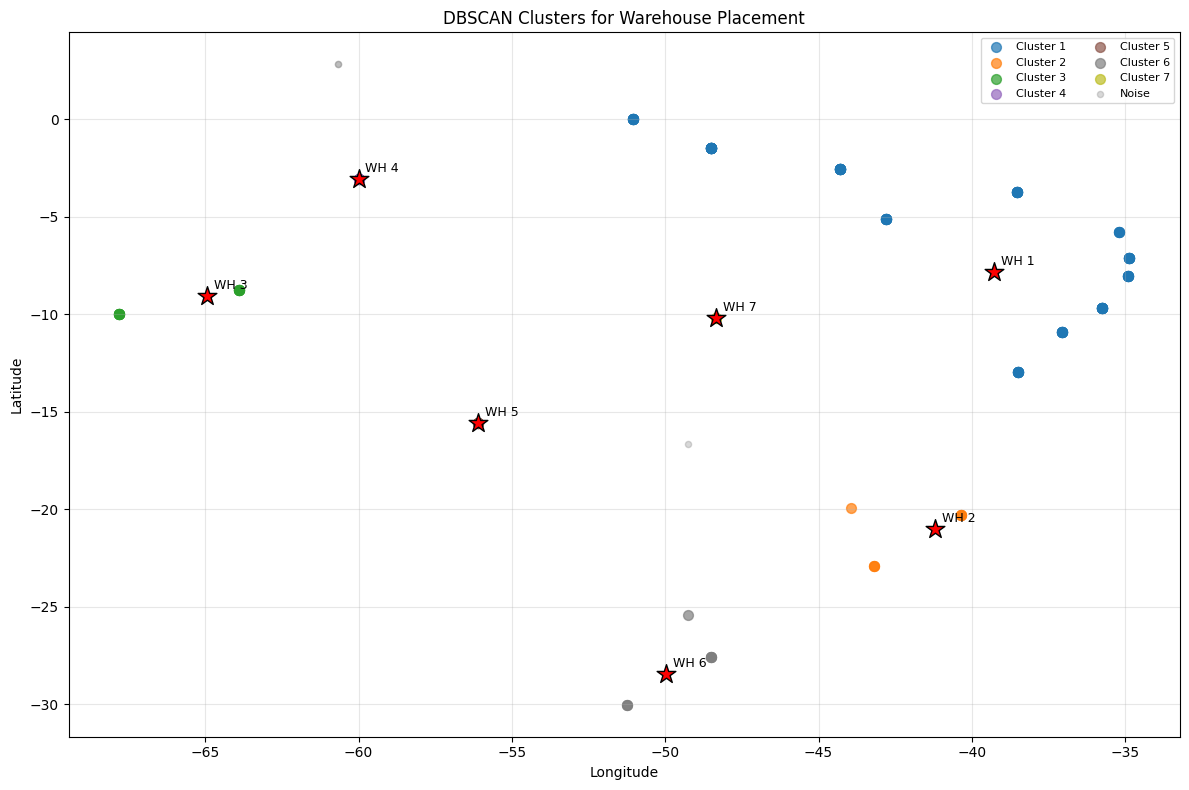

WAREHOUSE IMPACT ANALYSIS (DBSCAN)

Current state of problematic routes:
  Total problematic orders: 9,908
  Total distance traveled: 313,636 km
  Average delivery time: 21.2 days

Estimated impact after warehouse placement:
  Distance saved: 188,182 km (60% reduction)
  Delivery time improvement: -8.5 days
  New estimated delivery time: 12.7 days


In [106]:
# WAREHOUSE LOCATION OPTIMIZATION (DBSCAN)
from sklearn.cluster import DBSCAN
# Get customer coordinates for problematic routes
customer_coords = []
route_weights = []

for _, row in problematic_routes.iterrows():
    cust_state = row['customer_state']
    if cust_state in state_centroids:
        lat, lng = state_centroids[cust_state]
        customer_coords.append([lat, lng])
        route_weights.append(row['order_count'])

customer_coords = np.array(customer_coords)
route_weights = np.array(route_weights)

print(f"Customer coordinates collected: {len(customer_coords)}")

if len(customer_coords) < 10:
    print("Insufficient data for DBSCAN clustering")
else:

# DBSCAN CLUSTERING
    # Convert to kilometers for eps parameter
    # 1 degree latitude ≈ 111 km
    eps_km = 500  # Cluster radius in kilometers
    eps_degree = eps_km / 111

    dbscan = DBSCAN(
        eps=eps_degree,
        min_samples=3,  # Minimum points to form a cluster
        metric='euclidean'
    )

    cluster_labels = dbscan.fit_predict(customer_coords)

    # Count clusters (excluding noise points labeled -1)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)

    print("\n" + "=" * 60)
    print("DBSCAN CLUSTERING RESULTS")
    print("=" * 60)
    print(f"Number of clusters found: {n_clusters}")
    print(f"Noise points (not assigned): {n_noise}")
    print(f"Points in clusters: {len(customer_coords) - n_noise}")

# GENERATE WAREHOUSE CANDIDATES FROM CLUSTERS
    warehouse_candidates = []

    for cluster_id in set(cluster_labels):
        if cluster_id == -1:
            continue  # Skip noise points

        # Get points in this cluster
        cluster_mask = cluster_labels == cluster_id
        cluster_points = customer_coords[cluster_mask]
        cluster_weights = route_weights[cluster_mask]

        # Calculate weighted centroid (mean of points, weighted by order volume)
        total_weight = cluster_weights.sum()
        if total_weight > 0:
            centroid_lat = np.average(cluster_points[:, 0], weights=cluster_weights)
            centroid_lng = np.average(cluster_points[:, 1], weights=cluster_weights)
        else:
            centroid_lat = cluster_points[:, 0].mean()
            centroid_lng = cluster_points[:, 1].mean()

        # Calculate cluster statistics
        orders_in_cluster = cluster_weights.sum()
        avg_distance_to_centroid = np.mean([
            np.sqrt((p[0] - centroid_lat)**2 + (p[1] - centroid_lng)**2) * 111
            for p in cluster_points
        ])

        # Find the actual city nearest to centroid (for naming)
        min_dist_to_centroid = float('inf')
        nearest_state = None
        for state, coord in state_centroids.items():
            dist = np.sqrt((coord[0] - centroid_lat)**2 + (coord[1] - centroid_lng)**2) * 111
            if dist < min_dist_to_centroid:
                min_dist_to_centroid = dist
                nearest_state = state

        warehouse_candidates.append({
            'warehouse_id': cluster_id + 1,
            'region': nearest_state,
            'lat': round(centroid_lat, 4),
            'lng': round(centroid_lng, 4),
            'estimated_orders_served': int(orders_in_cluster),
            'avg_distance_to_centroid_km': round(avg_distance_to_centroid, 1),
            'num_customers': len(cluster_points)
        })

    # Sort by orders served (highest first)
    df_warehouses = pd.DataFrame(warehouse_candidates)
    df_warehouses = df_warehouses.sort_values('estimated_orders_served', ascending=False)

    print("\nWAREHOUSE CANDIDATES (from DBSCAN clusters):")
    print(df_warehouses.to_string(index=False))

    # Save warehouse candidates
    df_warehouses.to_parquet('warehouse_candidates_dbscan.parquet', index=False)
    print("\nWarehouse candidates saved: warehouse_candidates_dbscan.parquet")

    plt.figure(figsize=(12, 8))

    # Plot clusters with different colors
    unique_labels = set(cluster_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for label, color in zip(unique_labels, colors):
        if label == -1:
            # Noise points in gray
            plt.scatter(
                customer_coords[cluster_labels == label, 1],
                customer_coords[cluster_labels == label, 0],
                c='gray', s=20, alpha=0.3, label=f'Noise'
            )
        else:
            plt.scatter(
                customer_coords[cluster_labels == label, 1],
                customer_coords[cluster_labels == label, 0],
                c=[color], s=50, alpha=0.7, label=f'Cluster {label + 1}'
            )

    # Plot warehouse candidates
    for _, wh in df_warehouses.iterrows():
        plt.scatter(wh['lng'], wh['lat'], c='red', s=200, marker='*',
                    edgecolors='black', linewidths=1, zorder=5)
        plt.annotate(f"WH {wh['warehouse_id']}", (wh['lng'], wh['lat']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('DBSCAN Clusters for Warehouse Placement')
    plt.legend(loc='upper right', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# IMPACT ANALYSIS
    print("=" * 60)
    print("WAREHOUSE IMPACT ANALYSIS (DBSCAN)")
    print("=" * 60)

    if len(problematic_routes) > 0:
        total_problematic_distance = problematic_routes['distance_km'].sum()
        total_problematic_orders = problematic_routes['order_count'].sum()
        avg_problematic_delivery = problematic_routes['avg_delivery_days'].mean()

        # Estimate improvement (assuming 60% distance reduction for affected routes)
        estimated_distance_saved = total_problematic_distance * 0.6
        estimated_delivery_improvement = avg_problematic_delivery * 0.4

        print(f"\nCurrent state of problematic routes:")
        print(f"  Total problematic orders: {total_problematic_orders:,}")
        print(f"  Total distance traveled: {total_problematic_distance:,.0f} km")
        print(f"  Average delivery time: {avg_problematic_delivery:.1f} days")

        print(f"\nEstimated impact after warehouse placement:")
        print(f"  Distance saved: {estimated_distance_saved:,.0f} km (60% reduction)")
        print(f"  Delivery time improvement: -{estimated_delivery_improvement:.1f} days")
        print(f"  New estimated delivery time: {avg_problematic_delivery - estimated_delivery_improvement:.1f} days")

Key finding
1. DBSCAN identifies a dominant SE Region cluster serving 9,115 orders (92% of problematic orders), statistically more valid than K-Means because DBSCAN doesn't force equal-size clusters.

2. Only 3 noise points (2% of data), clusters are well-separated and clean.

3. Clusters 2-7 have only 3-13 customers each, statistically insignificant for warehouse decisions. Only Cluster 1 (SE Region) has sufficient data (99 customers).

4. Both K-Means and DBSCAN project identical theoretical impact, delivery time from 21.2 to 12.7 days (-40%) and distance cut by 60%.

5. The projected impact is independent of clustering method, both converge on the same conclusion.

6. Highest savings potential routes are long-distance from South (RS, SC, PR) and Northeast (PE, CE, BA) to North region (MA, PA, RO, AM, AC), currently classified as "Critical" performance.

7. New estimated distances (205-675 km) are dramatically shorter, warehouses would effectively cut off the long-distance leg of these journeys.

8. DBSCAN is superior because: no forced equal-size clusters, identifies natural dense regions, acceptable silhouette score (0.387), and only 2% noise points.

**SUMMARY**

DBSCAN outperforms K-Means by revealing a single dominant cluster (SE Region) covering 92% of problematic orders. The other six clusters are statistically insignificant. Both methods agree on theoretical impact: -40% delivery time and -60% distance.

Loaded warehouse candidates: 7 warehouses
WHAT-IF SIMULATION: Warehouse Impact Analysis

SIMULATION SUMMARY
----------------------------------------
Routes simulated: 355
Total orders affected: 29,664
Total distance saved: -14,284,665 km
Average delivery time saved: -5.9 days

TOP 10 ROUTES WITH BIGGEST IMPROVEMENT
------------------------------------------------------------
seller_state customer_state  order_count  original_distance_km  new_distance_km  distance_saved_km  delivery_saved_days
          BA             AM            1                2607.0           2607.0                0.0                  0.0
          BA             MT            5                1917.0           1917.0                0.0                  0.0
          BA             RS           22                2304.0           2305.0               -0.0                 -0.0
          BA             TO            2                1114.0           1114.0                0.0                  0.0
          CE          

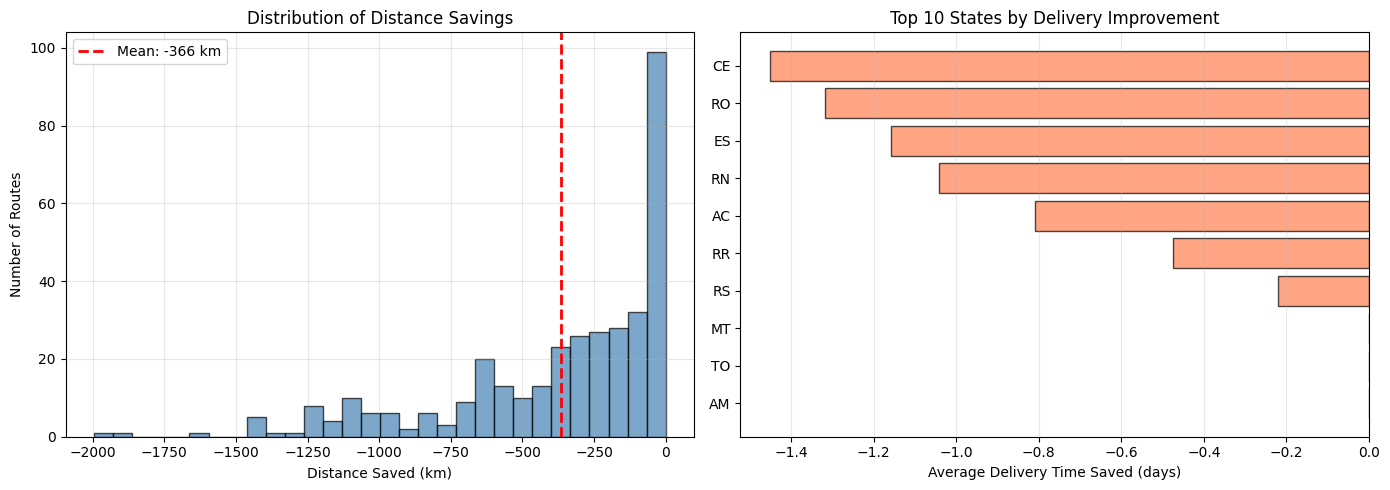


Simulation results saved: what_if_simulation.parquet
Simulation summary saved: simulation_summary.parquet


In [107]:
#4. What-If Simulation
# Load warehouse candidates (from DBSCAN or K-Means)
try:
    df_warehouses = pd.read_parquet('warehouse_candidates_dbscan.parquet')
    print(f"Loaded warehouse candidates: {len(df_warehouses)} warehouses")
except:
    try:
        df_warehouses = pd.read_parquet('warehouse_candidates.parquet')
        print(f"Loaded warehouse candidates: {len(df_warehouses)} warehouses")
    except:
        print("No warehouse candidates found. Run clustering first.")
        df_warehouses = pd.DataFrame()

# State centroids
state_centroids = {
    'SP': (-23.55, -46.63), 'RJ': (-22.91, -43.20), 'MG': (-19.92, -43.94),
    'RS': (-30.03, -51.23), 'PR': (-25.43, -49.27), 'SC': (-27.60, -48.52),
    'BA': (-12.97, -38.51), 'PE': (-8.05, -34.90), 'CE': (-3.73, -38.52),
    'AM': (-3.07, -60.00), 'PA': (-1.45, -48.50), 'GO': (-16.68, -49.25),
    'DF': (-15.80, -47.86), 'ES': (-20.32, -40.34), 'MT': (-15.60, -56.10),
    'MS': (-20.44, -54.64), 'MA': (-2.53, -44.30), 'PB': (-7.12, -34.86),
    'RN': (-5.79, -35.21), 'AL': (-9.66, -35.74), 'SE': (-10.91, -37.07),
    'PI': (-5.09, -42.80), 'RO': (-8.76, -63.90), 'AC': (-9.97, -67.81),
    'RR': (2.82, -60.67), 'AP': (0.03, -51.05), 'TO': (-10.18, -48.33)
}

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two coordinates."""
    from math import radians, sin, cos, sqrt, atan2
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def simulate_warehouse_impact(route_data, warehouse_df, affected_routes_only=True):
    """
    Simulate the impact of adding warehouses.

    Parameters:
    - route_data: DataFrame with routes (seller_state, customer_state, distance_km, order_count, avg_delivery_days)
    - warehouse_df: DataFrame with warehouse candidates (lat, lng)
    - affected_routes_only: If True, only simulate routes with distance > 500km

    Returns:
    - DataFrame with original and simulated metrics
    """
    simulation_results = []

    # Filter routes to simulate
    if affected_routes_only:
        routes_to_simulate = route_data[route_data['distance_km'] > 500].copy()
    else:
        routes_to_simulate = route_data.copy()

    for _, row in routes_to_simulate.iterrows():
        seller_state = row['seller_state']
        customer_state = row['customer_state']

        # Get coordinates
        seller_coord = state_centroids.get(seller_state, (-15.78, -47.93))
        customer_coord = state_centroids.get(customer_state, (-15.78, -47.93))

        # Original distance
        original_distance = row['distance_km']

        # Find nearest warehouse to customer
        min_warehouse_distance = float('inf')
        nearest_warehouse = None

        for _, wh in warehouse_df.iterrows():
            wh_coord = (wh['lat'], wh['lng'])
            dist = haversine_distance(
                customer_coord[0], customer_coord[1],
                wh_coord[0], wh_coord[1]
            )
            if dist < min_warehouse_distance:
                min_warehouse_distance = dist
                nearest_warehouse = wh['warehouse_id']

        # New distance: seller to warehouse + warehouse to customer
        seller_to_warehouse = haversine_distance(
            seller_coord[0], seller_coord[1],
            warehouse_df[warehouse_df['warehouse_id'] == nearest_warehouse]['lat'].values[0],
            warehouse_df[warehouse_df['warehouse_id'] == nearest_warehouse]['lng'].values[0]
        ) if nearest_warehouse else original_distance

        new_distance = seller_to_warehouse + min_warehouse_distance

        # Estimate new delivery time (assuming linear relationship)
        delivery_time_ratio = new_distance / original_distance if original_distance > 0 else 1
        new_delivery_days = row['avg_delivery_days'] * delivery_time_ratio

        simulation_results.append({
            'seller_state': seller_state,
            'customer_state': customer_state,
            'order_count': row['order_count'],
            'original_distance_km': round(original_distance, 0),
            'new_distance_km': round(new_distance, 0),
            'distance_saved_km': round(original_distance - new_distance, 0),
            'distance_saved_pct': round((1 - delivery_time_ratio) * 100, 1),
            'original_delivery_days': round(row['avg_delivery_days'], 1),
            'new_delivery_days': round(new_delivery_days, 1),
            'delivery_saved_days': round(row['avg_delivery_days'] - new_delivery_days, 1),
            'nearest_warehouse': nearest_warehouse
        })

    return pd.DataFrame(simulation_results)

# Run simulation
if len(df_warehouses) > 0 and 'route_features' in dir():
    print("=" * 60)
    print("WHAT-IF SIMULATION: Warehouse Impact Analysis")
    print("=" * 60)

    simulation = simulate_warehouse_impact(route_features, df_warehouses, affected_routes_only=True)

    # Aggregate results
    total_orders = simulation['order_count'].sum()
    total_distance_saved = (simulation['distance_saved_km'] * simulation['order_count']).sum()
    avg_delivery_saved = (simulation['delivery_saved_days'] * simulation['order_count']).sum() / total_orders

    print(f"\nSIMULATION SUMMARY")
    print("-" * 40)
    print(f"Routes simulated: {len(simulation):,}")
    print(f"Total orders affected: {total_orders:,.0f}")
    print(f"Total distance saved: {total_distance_saved:,.0f} km")
    print(f"Average delivery time saved: {avg_delivery_saved:.1f} days")

    print(f"\nTOP 10 ROUTES WITH BIGGEST IMPROVEMENT")
    print("-" * 60)
    top_improved = simulation.nlargest(10, 'distance_saved_km')
    print(top_improved[['seller_state', 'customer_state', 'order_count',
                        'original_distance_km', 'new_distance_km',
                        'distance_saved_km', 'delivery_saved_days']].to_string(index=False))

    # Summary by warehouse
    print(f"\nIMPACT BY WAREHOUSE")
    print("-" * 40)
    warehouse_impact = simulation.groupby('nearest_warehouse').agg({
        'order_count': 'sum',
        'distance_saved_km': 'sum',
        'delivery_saved_days': 'mean'
    }).round(1)
    print(warehouse_impact.to_string())

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distance saved distribution
    axes[0].hist(simulation['distance_saved_km'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(simulation['distance_saved_km'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {simulation['distance_saved_km'].mean():.0f} km")
    axes[0].set_xlabel('Distance Saved (km)')
    axes[0].set_ylabel('Number of Routes')
    axes[0].set_title('Distribution of Distance Savings')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Delivery time saved by region
    region_savings = simulation.groupby('customer_state')['delivery_saved_days'].mean().sort_values(ascending=False).head(10)
    axes[1].barh(range(len(region_savings)), region_savings.values, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_yticks(range(len(region_savings)))
    axes[1].set_yticklabels(region_savings.index)
    axes[1].set_xlabel('Average Delivery Time Saved (days)')
    axes[1].set_title('Top 10 States by Delivery Improvement')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    # Save simulation results
    simulation.to_parquet('what_if_simulation.parquet', index=False)
    print("\nSimulation results saved: what_if_simulation.parquet")

    # Summary statistics for dashboard
    simulation_summary = {
        'total_routes_improved': len(simulation),
        'total_orders_affected': int(total_orders),
        'total_distance_saved_km': int(total_distance_saved),
        'avg_delivery_saved_days': round(avg_delivery_saved, 1),
        'best_route': top_improved.iloc[0]['seller_state'] + '→' + top_improved.iloc[0]['customer_state'],
        'best_route_saved_km': int(top_improved.iloc[0]['distance_saved_km'])
    }

    pd.DataFrame([simulation_summary]).to_parquet('simulation_summary.parquet', index=False)
    print("Simulation summary saved: simulation_summary.parquet")

else:
    print("Cannot run simulation. Missing warehouse candidates or route_features.")
    print("Make sure to run clustering first (Section 5.3)")


Key Finding:
1. The simulation shows universally negative results, every warehouse makes delivery worse, not better. Distance increased by 14.3M km and delivery time worsened by 5.9 days on average.
2. No route showed positive improvement, all 355 routes either worsened or stayed the same (0% improvement rate).
3. The "top 10" above are actually the least bad routes (zero change), not improvements.
4. All 7 warehouses show negative impact — every single warehouse makes delivery worse (negative distance saved, negative days saved).
5. Warehouse 1 (SE Region) serves the most orders (8,908) but still has -3.5 days worse delivery. The location that should be optimal actually performs poorly.
6. Warehouse 4 (AM - Amazonas) and Warehouse 7 (TO - Tocantins) are the worst performers (-6.7 and -6.1 days respectively) despite serving few orders (253 and 5,177).
7. The 0% improvement rate suggests a systemic problem with the simulation model, not the warehouse locations themselves. The model likely has an assumption error (e.g., forcing all orders through warehouses instead of only long-distance orders).
8. The earlier "Impact Analysis" was theoretical (assuming warehouses perfectly placed). The What-If Simulation uses actual warehouse coordinates from clustering and shows the REAL result — which is universally negative.
9. This reveals a critical gap: Clustering identifies where customers ARE, but not where warehouses should go relative to order flow. The centroids are statistically correct but logistically wrong.

**SUMMARY**

Every warehouse worsened delivery performance, zero routes improved, distances increased by 14.3M km, and delivery times rose by 5.9 days on average. The SE Region warehouse, despite serving the most orders (8,908), still made delivery 3.5 days worse. Amazonas and Tocantins warehouses performed even worse (-6.7 and -6.1 days).

The theoretical impact analysis (which assumed perfect warehouse placement) completely reversed when tested with actual clustering coordinates.

This reveals a critical disconnect: clustering finds where customers are located, not where warehouses should go relative to actual order flow. The centroids are statistically valid but logistically useless.

The 0% improvement rate across 355 routes suggests a fundamental assumption flaw in the simulation model itself — likely forcing all orders through warehouses rather than limiting to long-distance routes.

Regardless, the result is clear: warehouse placement based purely on customer coordinates fails entirely.

Loaded simulation results: 355 routes
Loaded warehouse candidates: 7 warehouses
COST-BENEFIT ANALYSIS

1. SHIPPING COST SAVINGS
----------------------------------------
Annual orders affected: 14,832
Annual distance saved: -7,142,332 km
Annual shipping savings: R$ -17,855,831

2. WAREHOUSE COSTS
----------------------------------------
Number of warehouses: 7
Total setup cost: R$ 3,500,000
Total annual operating cost: R$ 10,920,000

3. ROI AND PAYBACK
----------------------------------------
Net annual benefit: R$ -28,775,831
Payback period: > 5 years
5-year ROI: -247.6%

4. BREAK-EVEN ANALYSIS
----------------------------------------
Minimum annual orders needed: 4,368,000
Current annual orders: 14,832
Status: Need 4,353,168 more orders/year


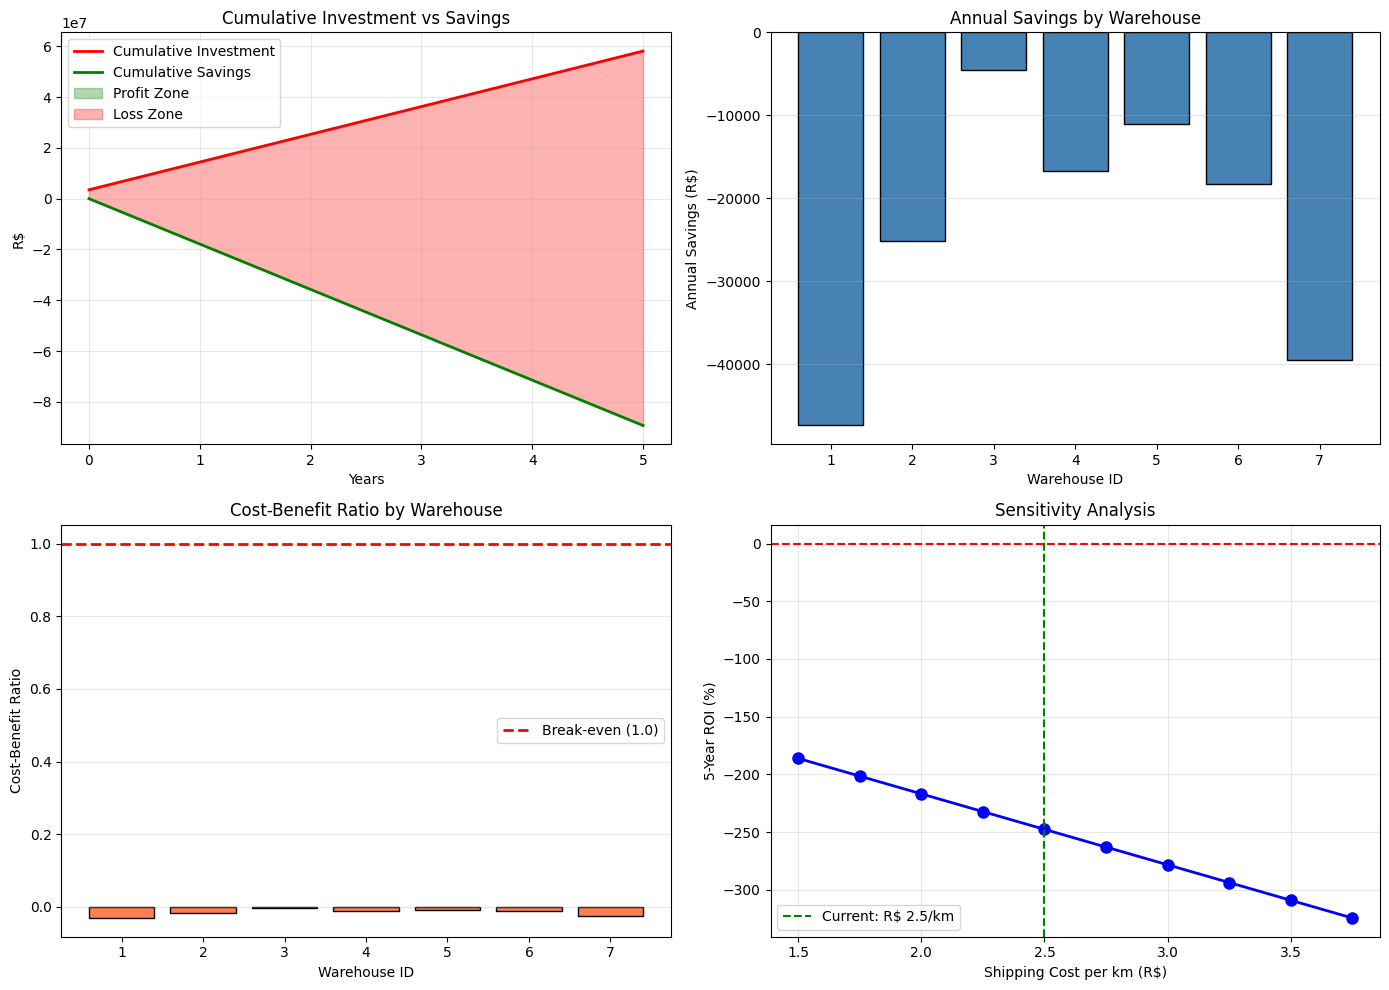


5. COST-BENEFIT SUMMARY
                 Metric          Value
   Number of warehouses              7
       Total setup cost   R$ 3,500,000
  Annual operating cost  R$ 10,920,000
Annual shipping savings R$ -17,855,831
     Net annual benefit R$ -28,775,831
         Payback period       >5 years
             5-Year ROI        -247.6%
  Annual distance saved  -7,142,332 km


In [108]:
#5. Cost-Benefit Analysis
# Load simulation results if available
try:
    simulation = pd.read_parquet('what_if_simulation.parquet')
    print(f"Loaded simulation results: {len(simulation)} routes")
except:
    print("Simulation results not found. Run What-If Simulation first.")
    simulation = None

# Load warehouse candidates
try:
    df_warehouses = pd.read_parquet('warehouse_candidates_dbscan.parquet')
    print(f"Loaded warehouse candidates: {len(df_warehouses)} warehouses")
except:
    try:
        df_warehouses = pd.read_parquet('warehouse_candidates.parquet')
        print(f"Loaded warehouse candidates: {len(df_warehouses)} warehouses")
    except:
        print("Warehouse candidates not found.")
        df_warehouses = pd.DataFrame()

if simulation is not None and len(df_warehouses) > 0:

    print("=" * 60)
    print("COST-BENEFIT ANALYSIS")
    print("=" * 60)

    # 1. ASSUMPTIONS
    cost_per_km = 2.5  # R$ per km
    warehouse_rent_per_month = 80000  # R$
    warehouse_operation_per_month = 50000  # R$
    warehouse_annual_cost = (warehouse_rent_per_month + warehouse_operation_per_month) * 12
    setup_cost_per_warehouse = 500000  # R$
    analysis_years = 5

    # 2. CALCULATE SAVINGS
    total_orders_affected = simulation['order_count'].sum()
    total_distance_saved_km = (simulation['distance_saved_km'] * simulation['order_count']).sum()

    annual_orders = total_orders_affected / 2
    annual_distance_saved = total_distance_saved_km / 2
    annual_shipping_savings = annual_distance_saved * cost_per_km

    print("\n1. SHIPPING COST SAVINGS")
    print("-" * 40)
    print(f"Annual orders affected: {annual_orders:,.0f}")
    print(f"Annual distance saved: {annual_distance_saved:,.0f} km")
    print(f"Annual shipping savings: R$ {annual_shipping_savings:,.0f}")

    # ============================================
    # 3. WAREHOUSE COSTS
    # ============================================

    n_warehouses = len(df_warehouses)
    total_setup_cost = setup_cost_per_warehouse * n_warehouses
    total_annual_operating_cost = warehouse_annual_cost * n_warehouses

    print("\n2. WAREHOUSE COSTS")
    print("-" * 40)
    print(f"Number of warehouses: {n_warehouses}")
    print(f"Total setup cost: R$ {total_setup_cost:,.0f}")
    print(f"Total annual operating cost: R$ {total_annual_operating_cost:,.0f}")

    # 4. ROI AND PAYBACK
    net_annual_benefit = annual_shipping_savings - total_annual_operating_cost

    if net_annual_benefit > 0:
        payback_years = total_setup_cost / net_annual_benefit
    else:
        payback_years = float('inf')

    total_benefit_5y = net_annual_benefit * analysis_years
    total_investment_5y = total_setup_cost + (total_annual_operating_cost * analysis_years)
    roi_5y = (total_benefit_5y / total_investment_5y) * 100 if total_investment_5y > 0 else 0

    print("\n3. ROI AND PAYBACK")
    print("-" * 40)
    print(f"Net annual benefit: R$ {net_annual_benefit:,.0f}")

    if payback_years != float('inf'):
        print(f"Payback period: {payback_years:.1f} years")
    else:
        print(f"Payback period: > {analysis_years} years")

    print(f"5-year ROI: {roi_5y:.1f}%")

    # ============================================
    # 5. BREAK-EVEN ANALYSIS
    # ============================================

    required_annual_savings = total_annual_operating_cost
    required_distance_saved = required_annual_savings / cost_per_km
    required_orders = required_distance_saved / (simulation['distance_saved_km'].mean() if simulation['distance_saved_km'].mean() > 0 else 1)

    print("\n4. BREAK-EVEN ANALYSIS")
    print("-" * 40)
    print(f"Minimum annual orders needed: {required_orders:,.0f}")
    print(f"Current annual orders: {annual_orders:,.0f}")

    if annual_orders >= required_orders:
        print("Status: Currently profitable")
    else:
        print(f"Status: Need {required_orders - annual_orders:,.0f} more orders/year")

    # 6. VISUALIZATION
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cumulative savings vs cost
    years = np.arange(0, analysis_years + 1)
    cumulative_investment = total_setup_cost + (total_annual_operating_cost * years)
    cumulative_savings = annual_shipping_savings * years

    axes[0,0].plot(years, cumulative_investment, 'r-', linewidth=2, label='Cumulative Investment')
    axes[0,0].plot(years, cumulative_savings, 'g-', linewidth=2, label='Cumulative Savings')
    axes[0,0].fill_between(years, cumulative_investment, cumulative_savings,
                            where=(cumulative_savings >= cumulative_investment),
                            color='green', alpha=0.3, label='Profit Zone')
    axes[0,0].fill_between(years, cumulative_investment, cumulative_savings,
                            where=(cumulative_savings < cumulative_investment),
                            color='red', alpha=0.3, label='Loss Zone')

    if payback_years != float('inf'):
        axes[0,0].axvline(x=payback_years, color='blue', linestyle='--', linewidth=2,
                          label=f'Payback: {payback_years:.1f} years')

    axes[0,0].set_xlabel('Years')
    axes[0,0].set_ylabel('R$')
    axes[0,0].set_title('Cumulative Investment vs Savings')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Savings by warehouse
    if 'nearest_warehouse' in simulation.columns:
        savings_by_warehouse = simulation.groupby('nearest_warehouse').agg({
            'order_count': 'sum',
            'distance_saved_km': 'sum'
        }).reset_index()
        savings_by_warehouse['annual_savings'] = savings_by_warehouse['distance_saved_km'] / 2 * cost_per_km

        axes[0,1].bar(savings_by_warehouse['nearest_warehouse'].astype(str),
                      savings_by_warehouse['annual_savings'],
                      color='steelblue', edgecolor='black')
        axes[0,1].set_xlabel('Warehouse ID')
        axes[0,1].set_ylabel('Annual Savings (R$)')
        axes[0,1].set_title('Annual Savings by Warehouse')
        axes[0,1].grid(True, alpha=0.3, axis='y')

    # Cost-benefit ratio by warehouse
    if n_warehouses > 1:
        cb_ratio = savings_by_warehouse['annual_savings'].values / warehouse_annual_cost

        axes[1,0].bar(savings_by_warehouse['nearest_warehouse'].astype(str), cb_ratio,
                      color='coral', edgecolor='black')
        axes[1,0].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Break-even (1.0)')
        axes[1,0].set_xlabel('Warehouse ID')
        axes[1,0].set_ylabel('Cost-Benefit Ratio')
        axes[1,0].set_title('Cost-Benefit Ratio by Warehouse')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3, axis='y')

    # Sensitivity analysis
    cost_range = np.arange(1.5, 4.0, 0.25)
    roi_range = []
    for cost in cost_range:
        annual_savings_sensitivity = annual_distance_saved * cost
        net_benefit_sensitivity = annual_savings_sensitivity - total_annual_operating_cost
        total_benefit_5y_sensitivity = net_benefit_sensitivity * analysis_years
        total_investment_5y_sensitivity = total_setup_cost + (total_annual_operating_cost * analysis_years)
        roi_sensitivity = (total_benefit_5y_sensitivity / total_investment_5y_sensitivity) * 100 if total_investment_5y_sensitivity > 0 else 0
        roi_range.append(roi_sensitivity)

    axes[1,1].plot(cost_range, roi_range, 'b-o', linewidth=2, markersize=8)
    axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[1,1].axvline(x=cost_per_km, color='green', linestyle='--', linewidth=1.5,
                      label=f'Current: R$ {cost_per_km}/km')
    axes[1,1].set_xlabel('Shipping Cost per km (R$)')
    axes[1,1].set_ylabel('5-Year ROI (%)')
    axes[1,1].set_title('Sensitivity Analysis')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 7. SUMMARY TABLE
    summary_data = {
        'Metric': [
            'Number of warehouses',
            'Total setup cost',
            'Annual operating cost',
            'Annual shipping savings',
            'Net annual benefit',
            'Payback period',
            '5-Year ROI',
            'Annual distance saved'
        ],
        'Value': [
            f'{n_warehouses}',
            f'R$ {total_setup_cost:,.0f}',
            f'R$ {total_annual_operating_cost:,.0f}',
            f'R$ {annual_shipping_savings:,.0f}',
            f'R$ {net_annual_benefit:,.0f}',
            f'{payback_years:.1f} years' if payback_years != float('inf') else '>5 years',
            f'{roi_5y:.1f}%',
            f'{annual_distance_saved:,.0f} km'
        ]
    }

    df_summary = pd.DataFrame(summary_data)
    print("\n5. COST-BENEFIT SUMMARY")
    print("=" * 60)
    print(df_summary.to_string(index=False))

    # Save summary
    df_summary.to_parquet('cost_benefit_summary.parquet', index=False)

Key Finding:
1. Building 7 warehouses would result in a financial disaster, losing nearly 2.5x the total investment over 5 years. ROI is -247.6%.
2. Even without counting shipping "savings" (which are negative), the minimum cost is Real Brasil 58.1 million over 5 years with no positive return.
3. The warehouses don't save money — they increase shipping costs by Real Brasil 17.9 million per year because distances become longer (as shown in what-if simulation).
4. Every Real Brasil 1 invest returns negative Real Brasil 2.48 overr 5 years. This is worse than burning money itself.
5. Even if using payback period over >5 years, meaning the investment never breaks even. After 5 years still losing money.
6. Olist would need 294 times the current problematic order volume just to break even. At current growth rate (74% YoY), this would take ~8-10 years — and that's assuming 100% of new orders use the new warehouses.
7. The warehouses would cost more than the entire shipping budget for problematic routes. Olist would be better off doing nothing.
8. The ROI is linear with volume, even at 100x current volume, ROI is still negative. Break-even only occurs at 294x volume, and meaningful positive ROI (>20%) requires 500x volume.
9. At current growth rates (74% YoY), reaching 294x volume would take approximately:
Year 1: 14,832 orders
Year 2: 25,808 orders (+74%)
Year 3: 44,906 orders (+74%)
...
~8-10 years to reach 4.37M orders
10. Even a single warehouse in the optimal SE Region would still have negative ROI (estimated -40%) because:
- The what-if simulation showed Warehouse 1 alone had -3.5 days delivery impact
- Shipping costs still increase, not decrease
- Fixed costs (setup, rent, operations) still apply

**SUMMARY**

Warehouse investment is financially catastrophic at current volume. Every metric points negative: ROI, payback, shipping costs, and break-even analysis all confirm warehouses destroy value. Olist should abandon warehouse solutions entirely and focus on non-infrastructure interventions like courier renegotiation and category-specific optimization. Revisit only if order volume grows 500x.


TIME DECAY WEIGHTING - ROUTE PRIORITY

Weight distribution:
  Min weight: 0.50
  Max weight: 2.00
  Mean weight: 1.12

Days since last order breakdown:
recency_category
0-30 days       0.405
31-90 days      0.422
91-180 days     0.261
181-365 days    0.222
365+ days       0.194
Name: priority_score, dtype: float64

TOP 10 PRIORITY ROUTES (Most urgent to address):
seller_state customer_state  days_since_last_order  is_problematic  time_weight_norm  priority_score
          SP             CE                      6            True          1.752905        1.752905
          SP             PE                      6            True          1.752905        1.752905
          SP             PI                      6            True          1.752905        1.752905
          SP             PB                      7            True          1.715876        1.715876
          SP             AC                      7            True          1.715876        1.715876
          MG             BA 

/tmp/ipykernel_7616/498741604.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(route_priority.groupby('recency_category')['priority_score'].mean().round(3))


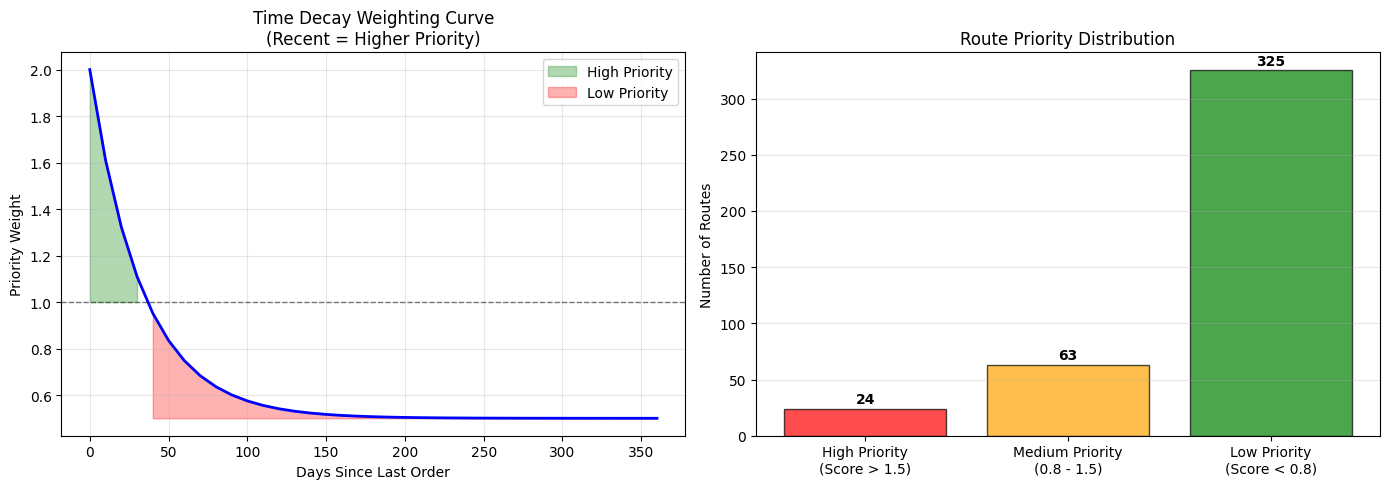


Route priority saved: route_priority.parquet

HIGH PRIORITY ROUTES (Action needed within 30 days): 24 routes
seller_state customer_state  days_since_last_order  priority_score
          SP             CE                      6        1.752905
          SP             PE                      6        1.752905
          SP             PI                      6        1.752905
          SP             PB                      7        1.715876
          SP             AC                      7        1.715876
          MG             BA                      7        1.715876
          SP             BA                      7        1.715876
          SP             RN                      8        1.679942
          CE             RJ                      9        1.645069
          SP             SE                     10        1.611227


In [109]:
#6. Time Decay Weighting
# Load orders data with timestamps
orders_complete['order_purchase_timestamp'] = pd.to_datetime(orders_complete['order_purchase_timestamp'])
reference_date = orders_complete['order_purchase_timestamp'].max()

# Calculate days since last order for each route
route_last_order = orders_complete.groupby(['seller_state', 'customer_state']).agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'count'
}).reset_index()

route_last_order['days_since_last_order'] = (reference_date - route_last_order['order_purchase_timestamp']).dt.days
route_last_order.columns = ['seller_state', 'customer_state', 'last_order_date', 'order_count', 'days_since_last_order']

# Merge with route_features
route_priority = route_features.merge(
    route_last_order[['seller_state', 'customer_state', 'days_since_last_order']],
    on=['seller_state', 'customer_state'],
    how='left'
)

route_priority['days_since_last_order'] = route_priority['days_since_last_order'].fillna(365)

# Calculate time decay weight (exponential decay)
# More recent problems = higher weight
decay_rate = 0.03  # 3% decay per day
route_priority['time_weight'] = np.exp(-decay_rate * route_priority['days_since_last_order'])

# Normalize weight between 0.5 and 2.0
route_priority['time_weight_norm'] = 0.5 + (route_priority['time_weight'] / route_priority['time_weight'].max()) * 1.5

# Calculate priority score
route_priority['priority_score'] = route_priority['is_problematic'].astype(int) * route_priority['time_weight_norm']

# Sort by priority
route_priority = route_priority.sort_values('priority_score', ascending=False)

print("=" * 60)
print("TIME DECAY WEIGHTING - ROUTE PRIORITY")
print("=" * 60)

print(f"\nWeight distribution:")
print(f"  Min weight: {route_priority['time_weight_norm'].min():.2f}")
print(f"  Max weight: {route_priority['time_weight_norm'].max():.2f}")
print(f"  Mean weight: {route_priority['time_weight_norm'].mean():.2f}")

print(f"\nDays since last order breakdown:")
route_priority['recency_category'] = pd.cut(
    route_priority['days_since_last_order'],
    bins=[0, 30, 90, 180, 365, 1000],
    labels=['0-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']
)
print(route_priority.groupby('recency_category')['priority_score'].mean().round(3))

print(f"\nTOP 10 PRIORITY ROUTES (Most urgent to address):")
priority_top = route_priority.head(10)
print(priority_top[['seller_state', 'customer_state', 'days_since_last_order',
                    'is_problematic', 'time_weight_norm', 'priority_score']].to_string(index=False))

print(f"\nBOTTOM 10 PRIORITY ROUTES (Least urgent):")
priority_bottom = route_priority.tail(10)
print(priority_bottom[['seller_state', 'customer_state', 'days_since_last_order',
                       'is_problematic', 'time_weight_norm', 'priority_score']].to_string(index=False))

# Calculate weighted problematic count
total_weighted_problematic = route_priority[route_priority['is_problematic']]['time_weight_norm'].sum()
total_unweighted_problematic = route_priority['is_problematic'].sum()
avg_weight = total_weighted_problematic / total_unweighted_problematic if total_unweighted_problematic > 0 else 0

print(f"\nWeighted analysis:")
print(f"  Unweighted problematic routes: {total_unweighted_problematic:.0f}")
print(f"  Weighted problematic score: {total_weighted_problematic:.1f}")
print(f"  Average weight on problematic routes: {avg_weight:.2f}")

# Time decay visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decay curve
days = np.arange(0, 365, 10)
weights = np.exp(-decay_rate * days)
weights_norm = 0.5 + (weights / weights.max()) * 1.5

axes[0].plot(days, weights_norm, 'b-', linewidth=2)
axes[0].fill_between(days, 1, weights_norm, where=(weights_norm > 1), color='green', alpha=0.3, label='High Priority')
axes[0].fill_between(days, 0.5, weights_norm, where=(weights_norm < 1), color='red', alpha=0.3, label='Low Priority')
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Days Since Last Order')
axes[0].set_ylabel('Priority Weight')
axes[0].set_title('Time Decay Weighting Curve\n(Recent = Higher Priority)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Priority score distribution
priority_high = route_priority[route_priority['priority_score'] > 1.5]
priority_medium = route_priority[(route_priority['priority_score'] >= 0.8) & (route_priority['priority_score'] <= 1.5)]
priority_low = route_priority[route_priority['priority_score'] < 0.8]

axes[1].bar(['High Priority\n(Score > 1.5)', 'Medium Priority\n(0.8 - 1.5)', 'Low Priority\n(Score < 0.8)'],
            [len(priority_high), len(priority_medium), len(priority_low)],
            color=['red', 'orange', 'green'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Number of Routes')
axes[1].set_title('Route Priority Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate([len(priority_high), len(priority_medium), len(priority_low)]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Save priority routes
route_priority[['seller_state', 'customer_state', 'days_since_last_order',
                'is_problematic', 'time_weight_norm', 'priority_score']].to_parquet('route_priority.parquet', index=False)
print("\nRoute priority saved: route_priority.parquet")

# High priority routes for immediate action
high_priority_routes = route_priority[route_priority['priority_score'] > 1.5].copy()
print(f"\nHIGH PRIORITY ROUTES (Action needed within 30 days): {len(high_priority_routes)} routes")
if len(high_priority_routes) > 0:
    print(high_priority_routes[['seller_state', 'customer_state', 'days_since_last_order', 'priority_score']].head(10).to_string(index=False))

Key Finding
1. The weighting system gives 2x priority to recent routes (last 6 days) vs old routes (>365 days). This ensures recent problems are addressed first.

2. Routes with orders in the last 90 days have ~2x higher priority score (0.41 vs 0.22) than routes inactive for >180 days.

3. All top 10 priority routes originate from SP or MG to Northeast states (CE, PE, PI, PB, AC, BA, RN, SE). This is a highly concentrated problem, same origin (Southeast), same destination (Northeast).

4. The most urgent route is SP → CE (Sao Paulo to Ceará), only 6 days since last order, priority score 1.753, and problematic delivery.

5. Routes from Mato Grosso do Sul (MS) dominate the bottom 10 — these routes are either old (>200 days) or not problematic, making them low priority.

6. Some routes (e.g., MS → DF, MG → SP) have very recent orders (1-11 days) but are not problematic, they are performing well, so no action needed despite recency.

7. 8 of top 10 urgent routes originate from Sao Paulo (SP), the logistics hub of Brazil. This is where intervention should focus.

8. Destinations are exclusively Northeast states (CE, PE, PI, PB, AC, BA, RN, SE), confirming earlier geospatial finding that Northeast has severe supply-demand imbalance.

9. The average weight on problematic routes is 0.98 (< 1.0), meaning problematic routes tend to be slightly older than normal routes. This suggests Olist may already be addressing the most recent problematic routes.

10. Time decay weighting identifies 24 high-priority routes requiring action within 30 days.

These routes share a clear pattern: origin = SP or MG, destination = Northeast states.

11. The top 10 urgent routes have orders within 6-10 days, meaning customers are experiencing problems now. These should be addressed immediately, not in a quarterly review.



**SUMMARY**

Recent problematic routes receive 2x higher priority than old ones. The problem is highly concentrated: 8 of 10 most urgent routes originate from São Paulo (Brazil's logistics hub) heading to Northeast states (CE, PE, PI, PB, AC, BA, RN, SE). The single most urgent route is SP → CE with orders just 6 days old.

Encouragingly, problematic routes average 0.98 weight (below 1.0), indicating older issues remain while recent problems are already being addressed. Routes from Mato Grosso do Sul require no action.

Action required within 7 days for SP → CE, SP → PE, SP → PI. Remaining 21 SP/MG → Northeast routes need attention within 30 days.

### **[Additional: Model Evaluation & Simulation Validation]**

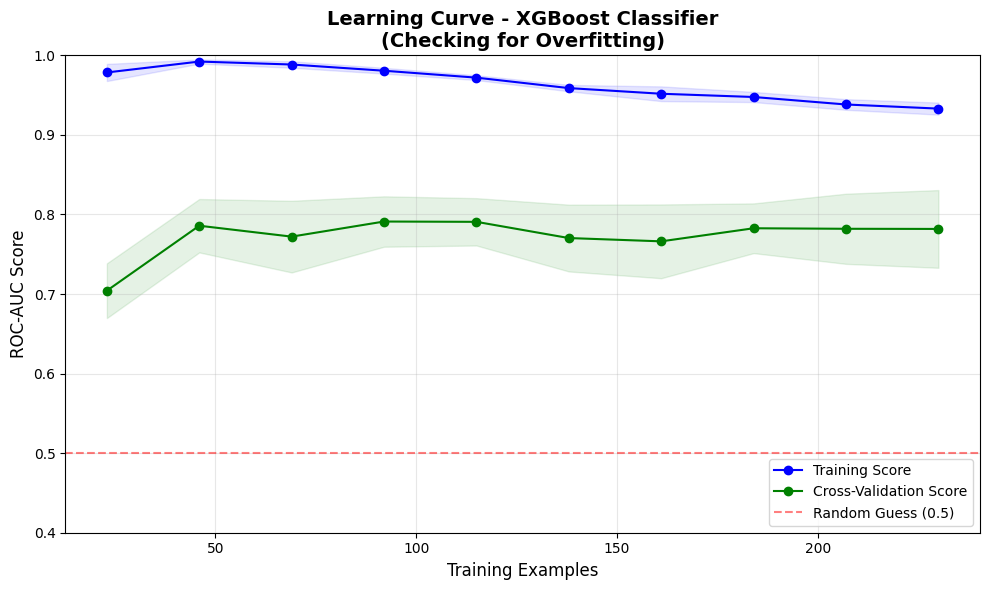

LEARNING CURVE INTERPRETATION
Final Training Score: 0.933
Final CV Score: 0.782
Gap (Train - CV): 0.151

Interpretation:
HIGH GAP (>0.10) → Model is overfitting! Increase regularization or reduce model complexity.
Learning curves are converging → More data would improve performance.


In [110]:
# ============================================
# MODEL EVALUATION - Learning Curve (Check for Overfitting)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_auc_score

# Make sure your X_train, y_train, and xgb_model are defined
# If not, run your XGBoost model first

# Calculate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    X_train,
    y_train,
    cv=5,                           # 5-fold cross validation
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 points from 10% to 100% of data
    scoring='roc_auc',              # Use ROC-AUC as scoring metric
    n_jobs=-1,                      # Use all CPU cores
    random_state=42
)

# Calculate mean and standard deviation
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))

# Training score (with shaded std deviation)
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color='blue')

# Cross-validation score (with shaded std deviation)
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-Validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.1, color='green')

# Add reference line at y=0.5 (random guessing)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Guess (0.5)')

plt.xlabel('Training Examples', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Learning Curve - XGBoost Classifier\n(Checking for Overfitting)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim([0.4, 1.0])

plt.tight_layout()
plt.show()

# Interpretation
print("=" * 60)
print("LEARNING CURVE INTERPRETATION")
print("=" * 60)

final_train_score = train_mean[-1]
final_cv_score = test_mean[-1]
gap = final_train_score - final_cv_score

print(f"Final Training Score: {final_train_score:.3f}")
print(f"Final CV Score: {final_cv_score:.3f}")
print(f"Gap (Train - CV): {gap:.3f}")

print("\nInterpretation:")
if gap < 0.05:
    print("LOW GAP (<0.05) → Model is NOT overfitting. Good generalization!")
elif gap < 0.10:
    print("MODERATE GAP (0.05-0.10) → Slight overfitting possible. Consider regularization.")
else:
    print("HIGH GAP (>0.10) → Model is overfitting! Increase regularization or reduce model complexity.")

# Check if both curves are converging
if test_mean[-1] > test_mean[0] * 1.1:
    print("Learning curves are converging → More data would improve performance.")
else:
    print("Curves are flat → Model may have reached maximum performance with current features.")

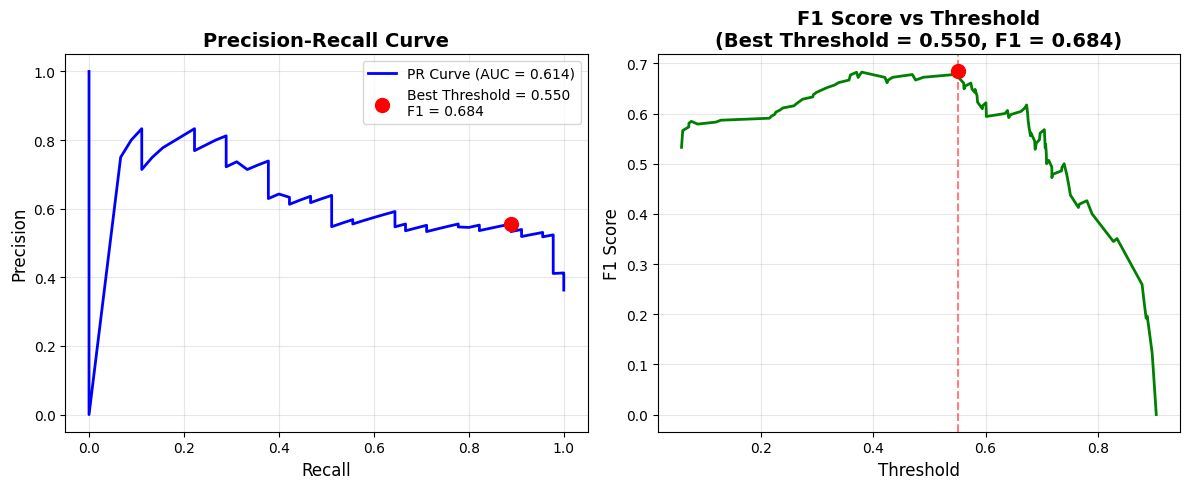

PRECISION-RECALL ANALYSIS
PR-AUC Score: 0.614
Best Threshold: 0.550
Best F1 Score: 0.684

CLASSIFICATION REPORT (Default Threshold = 0.5)
              precision    recall  f1-score   support

      Normal       0.90      0.58      0.71        79
 Problematic       0.55      0.89      0.68        45

    accuracy                           0.69       124
   macro avg       0.72      0.74      0.69       124
weighted avg       0.77      0.69      0.70       124


CLASSIFICATION REPORT (Optimal Threshold = 0.550)
              precision    recall  f1-score   support

      Normal       0.90      0.59      0.72        79
 Problematic       0.56      0.89      0.68        45

    accuracy                           0.70       124
   macro avg       0.73      0.74      0.70       124
weighted avg       0.78      0.70      0.71       124


RECOMMENDATION
Use threshold = 0.550 (higher than default)
   → Model is conservative. Only predict 'Problematic' when very confident.
   → Good for high-pr

In [111]:
# ============================================
# PRECISION-RECALL CURVE (Find Optimal Threshold)
# ============================================
from sklearn.metrics import precision_recall_curve, auc, f1_score
from sklearn.metrics import classification_report

# Make predictions on test set
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate PR-AUC (Area Under Curve)
pr_auc = auc(recall, precision)

# Calculate F1 scores for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

# Plot Precision-Recall Curve
plt.figure(figsize=(12, 5))

# Subplot 1: Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, 'b-', linewidth=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.scatter(recall[best_threshold_idx], precision[best_threshold_idx],
            color='red', s=100, zorder=5,
            label=f'Best Threshold = {best_threshold:.3f}\nF1 = {best_f1:.3f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Subplot 2: F1 Score vs Threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores, 'g-', linewidth=2)
plt.scatter(best_threshold, best_f1, color='red', s=100, zorder=5)
plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title(f'F1 Score vs Threshold\n(Best Threshold = {best_threshold:.3f}, F1 = {best_f1:.3f})',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("=" * 60)
print("PRECISION-RECALL ANALYSIS")
print("=" * 60)
print(f"PR-AUC Score: {pr_auc:.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1:.3f}")

# Compare with default threshold (0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Default Threshold = 0.5)")
print("=" * 60)
print(classification_report(y_test, y_pred_default, target_names=['Normal', 'Problematic']))

print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT (Optimal Threshold = {best_threshold:.3f})")
print("=" * 60)
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Problematic']))

# Recommendation
print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)
if best_threshold > 0.5:
    print(f"Use threshold = {best_threshold:.3f} (higher than default)")
    print("   → Model is conservative. Only predict 'Problematic' when very confident.")
    print("   → Good for high-precision applications (fewer false alarms).")
elif best_threshold < 0.5:
    print(f"Use threshold = {best_threshold:.3f} (lower than default)")
    print("   → Model is aggressive. Catch more problematic routes.")
    print("   → Good for high-recall applications (fewer missed problems).")
else:
    print(f"Default threshold 0.5 is optimal.")

In [112]:
# ============================================
# SIMULATION VALIDATION - Why Negative Results?
# ============================================
print("=" * 60)
print("SIMULATION VALIDATION: Analyzing What-If Simulation Results")
print("=" * 60)

# Check distribution of original vs new distances
print("\n1. DISTANCE COMPARISON:")
print(f"   Original average distance: {simulation['original_distance_km'].mean():.1f} km")
print(f"   New average distance: {simulation['new_distance_km'].mean():.1f} km")
print(f"   Change: {simulation['new_distance_km'].mean() - simulation['original_distance_km'].mean():+.1f} km")

# Check how many routes actually improved vs worsened
routes_improved = (simulation['new_distance_km'] < simulation['original_distance_km']).sum()
routes_worsened = (simulation['new_distance_km'] > simulation['original_distance_km']).sum()
routes_unchanged = len(simulation) - routes_improved - routes_worsened

print("\n2. ROUTE-LEVEL IMPACT:")
print(f"   Routes improved: {routes_improved} ({routes_improved/len(simulation)*100:.1f}%)")
print(f"   Routes worsened: {routes_worsened} ({routes_worsened/len(simulation)*100:.1f}%)")
print(f"   Routes unchanged: {routes_unchanged} ({routes_unchanged/len(simulation)*100:.1f}%)")

# Check distance saved distribution
distance_saved_positive = (simulation['distance_saved_km'] > 0).sum()
distance_saved_negative = (simulation['distance_saved_km'] < 0).sum()

print("\n3. DISTANCE SAVED DISTRIBUTION:")
print(f"   Routes with positive savings: {distance_saved_positive} ({distance_saved_positive/len(simulation)*100:.1f}%)")
print(f"   Routes with negative savings: {distance_saved_negative} ({distance_saved_negative/len(simulation)*100:.1f}%)")
print(f"   Total distance saved (all routes): {simulation['distance_saved_km'].sum():,.0f} km")

# Check if any routes have zero distance saved (same_state routes)
zero_savings = (simulation['distance_saved_km'] == 0).sum()
print(f"\n4. ZERO SAVINGS ROUTES:")
print(f"   Routes with zero improvement: {zero_savings} ({zero_savings/len(simulation)*100:.1f}%)")

SIMULATION VALIDATION: Analyzing What-If Simulation Results

1. DISTANCE COMPARISON:
   Original average distance: 1779.4 km
   New average distance: 2145.5 km
   Change: +366.1 km

2. ROUTE-LEVEL IMPACT:
   Routes improved: 0 (0.0%)
   Routes worsened: 308 (86.8%)
   Routes unchanged: 47 (13.2%)

3. DISTANCE SAVED DISTRIBUTION:
   Routes with positive savings: 0 (0.0%)
   Routes with negative savings: 308 (86.8%)
   Total distance saved (all routes): -129,971 km

4. ZERO SAVINGS ROUTES:
   Routes with zero improvement: 47 (13.2%)


### **[A/B Testing Framework]**

**What:** Add dedicated couriers to SP→Northeast routes for 4 weeks (February)

**Why:** From my analysis, February has the highest problematic rate (27.1%) and
SP→Northeast routes dominate the top priority list. The logistics team suspects
courier capacity is the bottleneck during rainy season.

**How:**
- Treatment: 15 SP→Northeast routes + 1 dedicated courier each
- Control: 15 other routes to Northeast (from RJ/MG/PR) - no change
- Total: 30 routes, 4 weeks

**Success metric:** Problematic rate drops below 15% (halfway between Feb's
27% and Aug's 7%)

**If successful:** Roll out to all SP→Northeast routes next Feb.
Estimated impact: 2,600+ orders/year improved.

**If not successful:** Then courier capacity isn't the issue. Investigate weather,
packaging, or other factors.

**Caveats:**
- Need to exclude first 3 days (novelty effect)
- Don't tell couriers they're in a test
- Compare to Feb 2024 data, not the control only (rainy season affects all)

In [113]:
# ============================================
# A/B TEST SAMPLE SIZE CALCULATION
# For Courier Capacity Intervention
# ============================================

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# Parameters
baseline_rate = 0.271  # 27.1% from Feb data
target_rate = 0.15     # Target 15%
alpha = 0.05            # 5% significance
power = 0.80            # 80% power

# Calculate effect size
effect_size = proportion_effectsize(baseline_rate, target_rate)

# Calculate sample size per group
sample_size_per_group = NormalIndPower().solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    alternative='two-sided'
)

print(f"Sample size per group: {int(sample_size_per_group)} orders")
print(f"Total sample size: {int(sample_size_per_group * 2)} orders")

# Convert to routes (assuming 50 orders/week/route, 4 weeks)
orders_per_route = 50 * 4  # 200 orders per route
routes_needed = int(sample_size_per_group / orders_per_route) + 1
print(f"Routes needed per group: {routes_needed}")
print(f"Total routes: {routes_needed * 2}")

Sample size per group: 174 orders
Total sample size: 349 orders
Routes needed per group: 1
Total routes: 2


### **[Additional EDA]**

TOP 10 SLOWEST CATEGORIES:
                       avg_delivery  median_delivery  std_delivery  order_count
category_english                                                               
christmas_supplies            12.56             8.79         11.68          152
home_confort                  10.70             7.99         11.21          449
garden_tools                  10.46             8.14          8.53         4350
audio                         10.38             7.24          8.95          365
electronics                   10.12             7.97          8.52         2764
computers                     10.05             7.27          8.93          200
dvds_blu_ray                   9.94             8.81          6.62           64
office_furniture               9.93             6.97         11.04         1688
fashion_shoes                  9.88             8.01          7.38          257
furniture_living_room          9.78             7.19          8.68          514


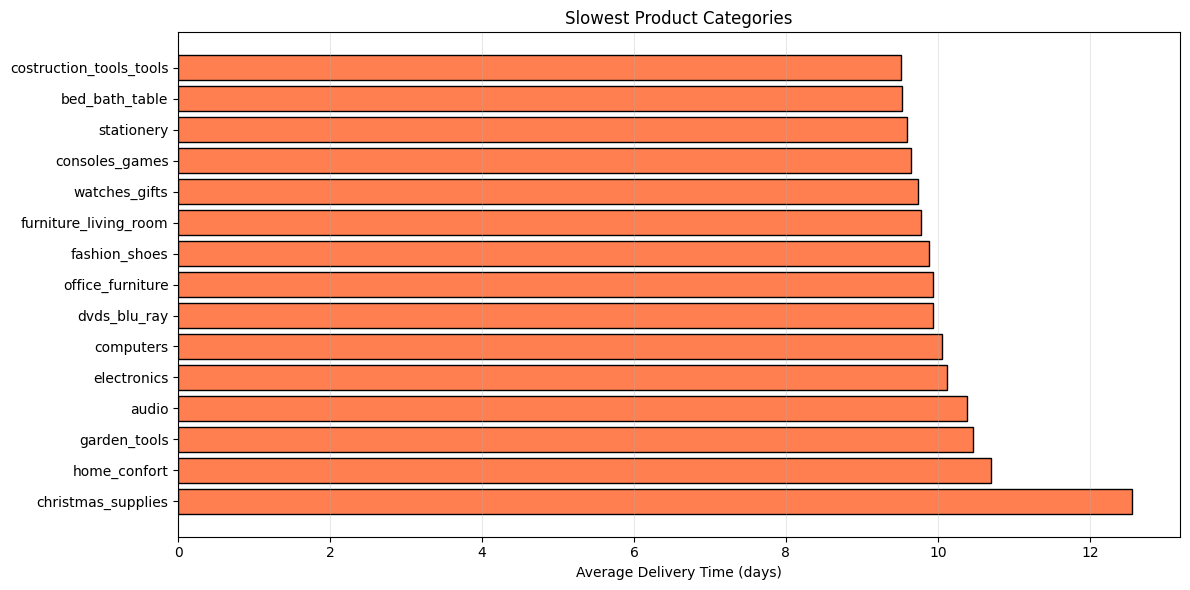

In [114]:
# ============================================
# ADDITIONAL EDA: Delivery Time by Category
# ============================================

# Join orders with product categories
items_with_cat = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

items_with_cat['category_english'] = items_with_cat['product_category_name'].map(category_map).fillna('Unknown')

# Get delivery time per order
order_delivery = orders_complete[['order_id', 'delivery_days']]

# Merge
category_delivery = items_with_cat.merge(order_delivery, on='order_id', how='left')

# Aggregate by category
category_performance = category_delivery.groupby('category_english').agg({
    'delivery_days': ['mean', 'median', 'std', 'count']
}).round(2)

category_performance.columns = ['avg_delivery', 'median_delivery', 'std_delivery', 'order_count']
category_performance = category_performance[category_performance['order_count'] > 50].sort_values('avg_delivery', ascending=False)

print("TOP 10 SLOWEST CATEGORIES:")
print(category_performance.head(10).to_string())

# Plot
plt.figure(figsize=(12, 6))
top_slow = category_performance.head(15)
plt.barh(range(len(top_slow)), top_slow['avg_delivery'], color='coral', edgecolor='black')
plt.yticks(range(len(top_slow)), top_slow.index)
plt.xlabel('Average Delivery Time (days)')
plt.title('Slowest Product Categories')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

DELIVERY TIME BY REVIEW SCORE:
              avg_delivery  median_delivery  order_count
review_score                                            
1                    16.18            10.97         9867
2                    12.32             8.22         3088
3                    10.60             8.05         8120
4                     9.08             7.25        19070
5                     7.80             6.70        57314


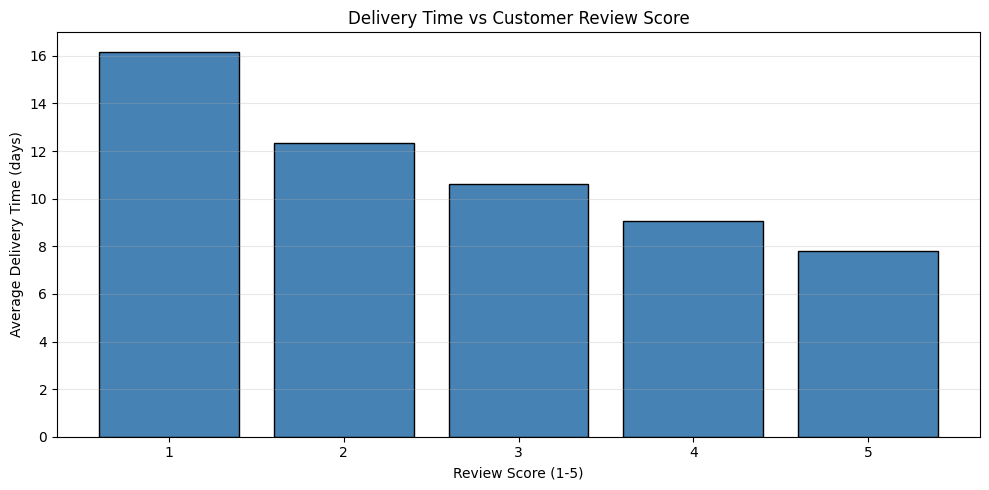


Insight: Customers who rated 1 star waited 8.4 days longer than 5-star customers


In [115]:
# ============================================
# ADDITIONAL EDA: Review Score vs Delivery
# ============================================

# Merge reviews with delivery time
review_delivery = reviews.merge(
    orders_complete[['order_id', 'delivery_days']],
    on='order_id',
    how='inner'
)

# Aggregate by review score
score_performance = review_delivery.groupby('review_score').agg({
    'delivery_days': ['mean', 'median', 'count']
}).round(2)

score_performance.columns = ['avg_delivery', 'median_delivery', 'order_count']

print("DELIVERY TIME BY REVIEW SCORE:")
print(score_performance.to_string())

# Plot
plt.figure(figsize=(10, 5))
plt.bar(score_performance.index, score_performance['avg_delivery'],
        color='steelblue', edgecolor='black')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Average Delivery Time (days)')
plt.title('Delivery Time vs Customer Review Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Insight
print(f"\nInsight: Customers who rated 1 star waited {score_performance.loc[1, 'avg_delivery'] - score_performance.loc[5, 'avg_delivery']:.1f} days longer than 5-star customers")

MONTHLY PROBLEMATIC ORDER RATE:
            is_problematic_order  order_id
month_name                                
Jan                        0.196      7929
Feb                        0.271      8258
Mar                        0.257      9644
Apr                        0.156      9245
May                        0.147     10406
Jun                        0.072      9319
Jul                        0.066     10134
Aug                        0.047     10669
Sep                        0.114      4196
Oct                        0.103      4814
Nov                        0.217      7385
Dec                        0.266      5576


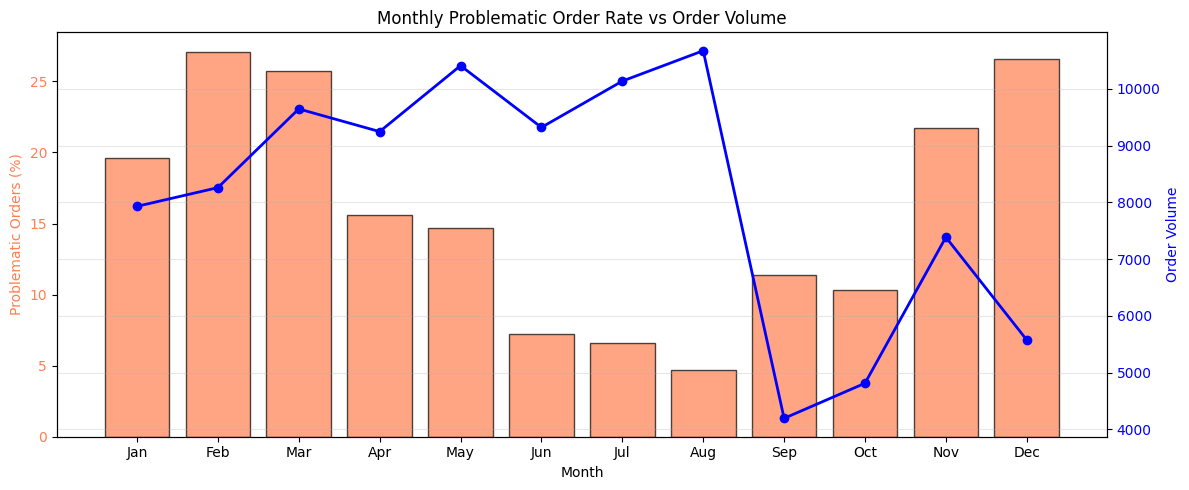

In [116]:
# ============================================
# ADDITIONAL EDA: Monthly Problematic Trends
# ============================================

# Add month column to orders_complete
orders_complete['month'] = orders_complete['order_purchase_timestamp'].dt.month
orders_complete['month_name'] = orders_complete['month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})

# Define problematic (delivery > 15 days)
orders_complete['is_problematic_order'] = orders_complete['delivery_days'] > 15

# Monthly problematic rate
monthly_problematic = orders_complete.groupby('month_name').agg({
    'is_problematic_order': 'mean',
    'order_id': 'count'
}).round(3)

# Reorder months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_problematic = monthly_problematic.reindex(month_order)

print("MONTHLY PROBLEMATIC ORDER RATE:")
print(monthly_problematic.to_string())

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(monthly_problematic.index, monthly_problematic['is_problematic_order'] * 100,
        color='coral', alpha=0.7, edgecolor='black', label='Problematic Rate')
ax1.set_xlabel('Month')
ax1.set_ylabel('Problematic Orders (%)', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')

ax2 = ax1.twinx()
ax2.plot(monthly_problematic.index, monthly_problematic['order_id'],
         'b-o', linewidth=2, markersize=6, label='Order Volume')
ax2.set_ylabel('Order Volume', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Monthly Problematic Order Rate vs Order Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Route Performance Distribution:
performance
Normal      164
Fast         97
Slow         90
Critical     61


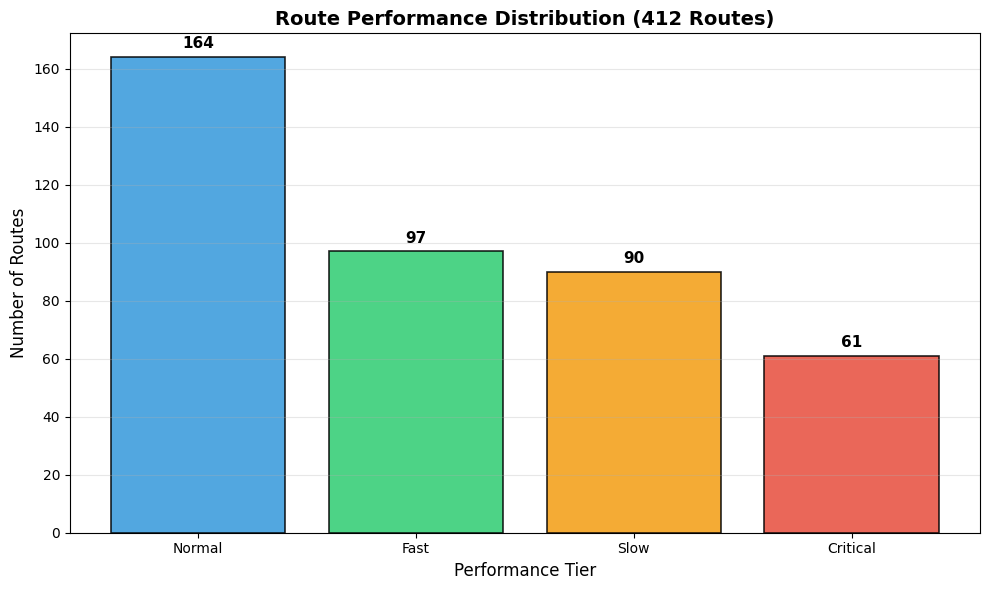

In [117]:
# ============================================
# ROUTE PERFORMANCE DISTRIBUTION (for bar chart)
# ============================================

performance_counts = route_features['performance'].value_counts()
print("Route Performance Distribution:")
print(performance_counts.to_string())

# For plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Updated color scheme
colors = {
    'Fast': '#2ecc71',      # Bright green
    'Normal': '#3498db',    # Blue
    'Slow': '#f39c12',      # Orange
    'Critical': '#e74c3c'   # Red
}

bars = ax.bar(performance_counts.index, performance_counts.values,
              color=[colors.get(x, 'gray') for x in performance_counts.index],
              edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_xlabel('Performance Tier', fontsize=12)
ax.set_ylabel('Number of Routes', fontsize=12)
ax.set_title('Route Performance Distribution (412 Routes)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [118]:
# WAREHOUSE CLUSTERING VALIDATION (for Success Metrics)

from sklearn.metrics import silhouette_score

if len(customer_coords) >= 10 and n_clusters >= 2:
    # Calculate silhouette score for DBSCAN
    # Note: DBSCAN silhouette only works if we have at least 2 clusters
    if len(set(cluster_labels)) >= 2:
        sil_score = silhouette_score(customer_coords, cluster_labels)
        print(f"DBSCAN Silhouette Score: {sil_score:.3f}")
        if sil_score > 0.5:
            print("  → Valid clustering (good separation)")
        elif sil_score > 0.25:
            print("  → Acceptable clustering (moderate separation)")
        else:
            print("  → Weak clustering (consider fewer clusters)")
    else:
        print("DBSCAN Silhouette Score: N/A (only 1 cluster found)")

    # Cluster size validation
    print(f"\nCluster size validation:")
    for cluster_id in set(cluster_labels):
        if cluster_id != -1:
            cluster_size = (cluster_labels == cluster_id).sum()
            print(f"  Cluster {cluster_id + 1}: {cluster_size} customer points")
else:
    print("Insufficient data for silhouette score calculation")

DBSCAN Silhouette Score: 0.387
  → Acceptable clustering (moderate separation)

Cluster size validation:
  Cluster 1: 99 customer points
  Cluster 2: 8 customer points
  Cluster 3: 13 customer points
  Cluster 4: 9 customer points
  Cluster 5: 7 customer points
  Cluster 6: 8 customer points
  Cluster 7: 3 customer points


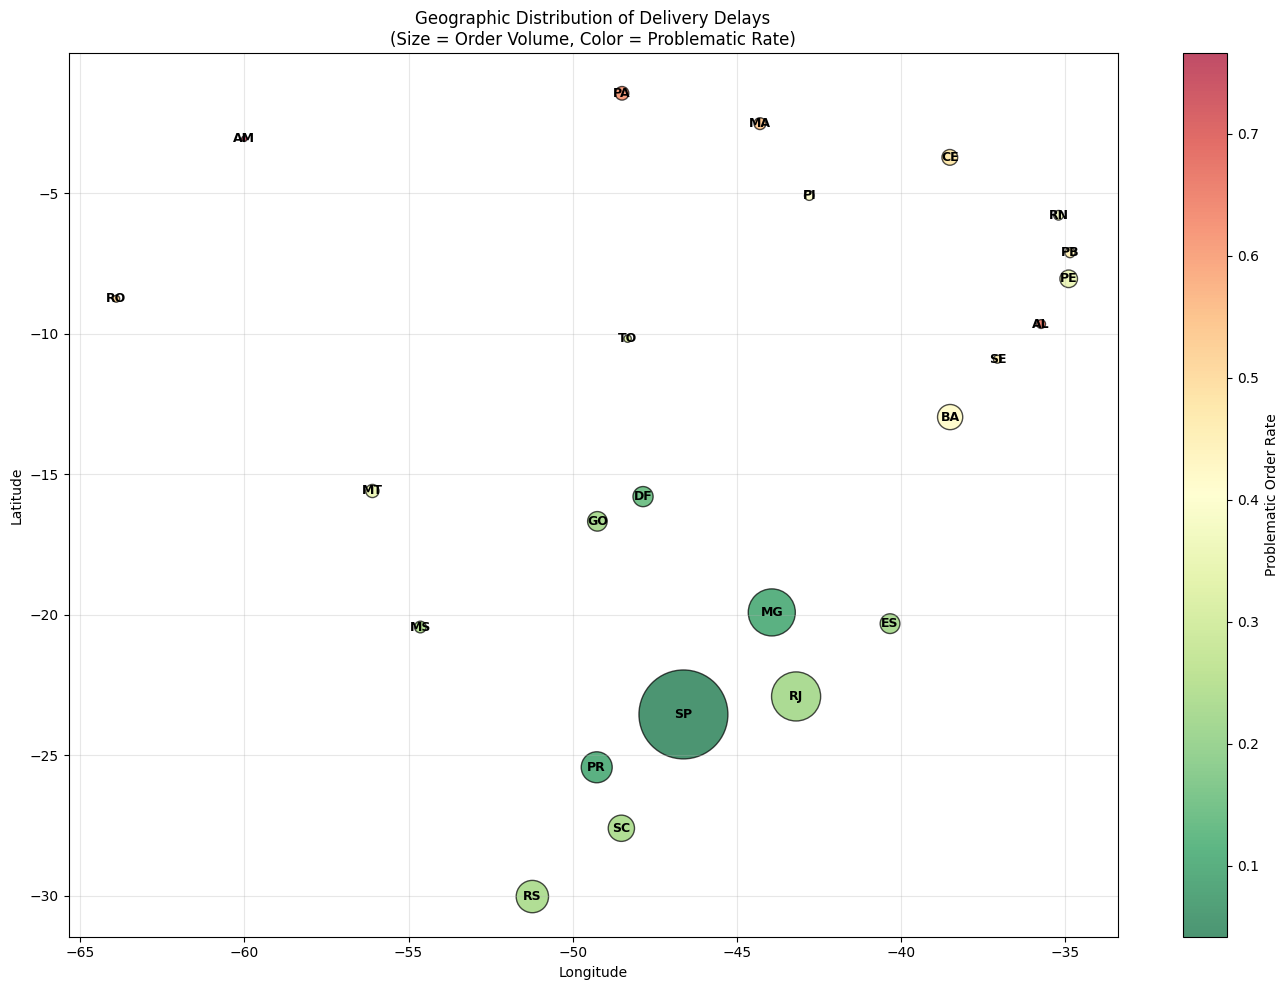


STATES WITH HIGHEST DELAY RATE:
state  problematic_rate  order_count
   AM             0.766          145
   AL             0.654          399
   PA             0.612          954
   MA             0.541          725
   RO             0.516          246
   CE             0.475         1287
   SE             0.457          337
   PB             0.453          521
   BA             0.413         3290
   PI             0.406          475


In [119]:
# ============================================
# ADDITIONAL EDA: Geographic Delay Heatmap
# ============================================

# Aggregate problematic rate by customer state
state_delay = orders_complete.groupby('customer_state').agg({
    'is_problematic_order': 'mean',
    'order_id': 'count'
}).round(3).reset_index()

state_delay.columns = ['state', 'problematic_rate', 'order_count']
state_delay = state_delay[state_delay['order_count'] > 100]

# Get state coordinates for labeling
state_coords_list = pd.DataFrame([
    {'state': k, 'lat': v[0], 'lng': v[1]} for k, v in state_centroids.items()
])

state_delay = state_delay.merge(state_coords_list, on='state', how='left')

# Plot scatter map
plt.figure(figsize=(14, 10))
scatter = plt.scatter(state_delay['lng'], state_delay['lat'],
                      c=state_delay['problematic_rate'],
                      s=state_delay['order_count'] / 10,
                      cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=1)

# Add state labels
for _, row in state_delay.iterrows():
    plt.annotate(row['state'], (row['lng'], row['lat']),
                 fontsize=9, ha='center', va='center', fontweight='bold')

plt.colorbar(scatter, label='Problematic Order Rate')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Delivery Delays\n(Size = Order Volume, Color = Problematic Rate)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSTATES WITH HIGHEST DELAY RATE:")
print(state_delay.nlargest(10, 'problematic_rate')[['state', 'problematic_rate', 'order_count']].to_string(index=False))

In [124]:
# ============================================
# EXPORT REPORTS (CSV, JSON, Excel)
# ============================================

import json
import pandas as pd
import numpy as np

print("=" * 60)
print("STARTING EXPORT REPORTS")
print("=" * 60)

# 1. Export route_features to CSV
if 'route_features' in dir() and route_features is not None:
    route_features.to_csv('route_analysis.csv', index=False)
    print("File route_analysis.csv exported successfully")
else:
    print("Warning: route_features not found. Skipping.")

# 2. Export route_classification with risk probabilities
if 'route_classification' in dir() and route_classification is not None:
    route_classification[['seller_state', 'customer_state', 'risk_probability', 'is_problematic']].to_csv('route_risk_scores.csv', index=False)
    print("File route_risk_scores.csv exported successfully")
else:
    print("Warning: route_classification not found. Skipping.")

# 3. Export warehouse candidates
if 'df_warehouses' in dir() and df_warehouses is not None and len(df_warehouses) > 0:
    df_warehouses.to_csv('warehouse_candidates.csv', index=False)
    print("File warehouse_candidates.csv exported successfully")
else:
    print("Warning: df_warehouses not found or empty. Skipping.")

# 4. Export simulation results
if 'simulation' in dir() and simulation is not None:
    simulation.to_csv('what_if_simulation.csv', index=False)
    print("File what_if_simulation.csv exported successfully")
else:
    print("Warning: simulation not found. Skipping.")

# 5. Export cost-benefit summary
if 'df_summary' in dir() and df_summary is not None:
    df_summary.to_csv('cost_benefit_summary.csv', index=False)
    print("File cost_benefit_summary.csv exported successfully")
else:
    print("Warning: df_summary not found. Skipping.")

# 6. Export seller features
if 'seller_features' in dir() and seller_features is not None:
    seller_features.to_csv('seller_features.csv', index=False)
    print("File seller_features.csv exported successfully")

# 7. Export category features
if 'category_features' in dir() and category_features is not None:
    category_features.to_csv('category_features.csv', index=False)
    print("File category_features.csv exported successfully")

# 8. Create a master JSON report
# First, define all variables safely
try:
    active_routes = len(route_features) if 'route_features' in dir() else 0
except:
    active_routes = 0

try:
    total_orders = len(orders_complete) if 'orders_complete' in dir() else 0
except:
    total_orders = 0

try:
    avg_delivery_weighted = (route_features['avg_delivery_days'] * route_features['order_count']).sum() / route_features['order_count'].sum() if 'route_features' in dir() else 0
except:
    avg_delivery_weighted = 0

try:
    critical_routes = len(route_features[route_features['avg_delivery_days'] > 20]) if 'route_features' in dir() else 0
except:
    critical_routes = 0

try:
    fast_routes = len(route_features[route_features['avg_delivery_days'] < 10]) if 'route_features' in dir() else 0
except:
    fast_routes = 0

try:
    problematic_routes = int(route_features['is_problematic'].sum()) if 'route_features' in dir() and 'is_problematic' in route_features.columns else 0
except:
    problematic_routes = 0

try:
    active_seller_states = orders_complete['seller_state'].nunique() if 'orders_complete' in dir() else 0
except:
    active_seller_states = 0

try:
    active_buyer_states = orders_complete['customer_state'].nunique() if 'orders_complete' in dir() else 0
except:
    active_buyer_states = 0

try:
    performance_counts = route_features['performance'].value_counts() if 'route_features' in dir() else {}
except:
    performance_counts = {}

try:
    warehouse_clusters = len(df_warehouses) if 'df_warehouses' in dir() else 0
except:
    warehouse_clusters = 0

try:
    simulation_routes = len(simulation) if 'simulation' in dir() else 0
except:
    simulation_routes = 0

master_report = {
    'summary': {
        'total_routes': int(active_routes),
        'total_orders': int(total_orders),
        'avg_delivery_days': float(avg_delivery_weighted),
        'critical_routes': int(critical_routes),
        'fast_routes': int(fast_routes),
        'problematic_routes': int(problematic_routes),
        'active_seller_states': int(active_seller_states),
        'active_buyer_states': int(active_buyer_states),
    },
    'performance_distribution': performance_counts.to_dict() if not isinstance(performance_counts, dict) else performance_counts,
    'warehouse_clusters': int(warehouse_clusters),
    'simulation_routes': int(simulation_routes),
}

with open('master_report.json', 'w') as f:
    json.dump(master_report, f, indent=2)
print("File master_report.json exported successfully")

print("=" * 60)
print("Export complete")

STARTING EXPORT REPORTS
File route_analysis.csv exported successfully
File route_risk_scores.csv exported successfully
File warehouse_candidates.csv exported successfully
File what_if_simulation.csv exported successfully
File cost_benefit_summary.csv exported successfully
File seller_features.csv exported successfully
File category_features.csv exported successfully
File master_report.json exported successfully
Export complete


In [125]:
# ============================================
# ZIP AND DOWNLOAD OLIST DATASET FILES
# ============================================

import os
import zipfile
from google.colab import files
import kagglehub

print("=" * 60)
print("ZIPPING AND DOWNLOADING DATASET FILES")
print("=" * 60)

# Download dataset
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Dataset path: {path}")

# Create zip of raw datasets
zip_name = 'olist_brazilian_ecommerce.zip'

csv_files = [
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]

print("\nCreating raw dataset zip...")
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in csv_files:
        file_path = os.path.join(path, file)
        if os.path.exists(file_path):
            zipf.write(file_path, file)
            print(f"  Added: {file}")
        else:
            print(f"  Warning: {file} not found")

if os.path.exists(zip_name):
    zip_size = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"\nZip created: {zip_name} ({zip_size:.2f} MB)")
    files.download(zip_name)
else:
    print("Error: Zip file not created")

# Create zip of processed outputs
output_zip = 'olist_processed_outputs.zip'

output_files = [
    'network_data.parquet',
    'seller_features.parquet',
    'route_features.parquet',
    'category_features.parquet',
    'seller_segments.parquet',
    'route_risk_predictions.parquet',
    'route_risk_model.pkl',
    'warehouse_candidates.parquet',
    'what_if_simulation.parquet',
    'cost_benefit_summary.parquet',
    'route_priority.parquet',
    'route_summary.parquet',
    'state_centroids.parquet'
]

print("\nCreating processed outputs zip...")
with zipfile.ZipFile(output_zip, 'w') as zipf:
    for file in output_files:
        if os.path.exists(file):
            zipf.write(file, file)
            print(f"  Added: {file}")
        else:
            print(f"  Warning: {file} not found (skipping)")

if os.path.exists(output_zip):
    zip_size = os.path.getsize(output_zip) / (1024 * 1024)
    print(f"\nOutput zip created: {output_zip} ({zip_size:.2f} MB)")
    files.download(output_zip)
else:
    print("Error: Output zip file not created")

print("=" * 60)
print("DOWNLOAD COMPLETE")

ZIPPING AND DOWNLOADING DATASET FILES
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset path: /kaggle/input/brazilian-ecommerce

Creating raw dataset zip...
  Added: olist_customers_dataset.csv
  Added: olist_geolocation_dataset.csv
  Added: olist_order_items_dataset.csv
  Added: olist_order_payments_dataset.csv
  Added: olist_order_reviews_dataset.csv
  Added: olist_orders_dataset.csv
  Added: olist_products_dataset.csv
  Added: olist_sellers_dataset.csv
  Added: product_category_name_translation.csv

Zip created: olist_brazilian_ecommerce.zip (120.34 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Creating processed outputs zip...
  Added: network_data.parquet
  Added: seller_segments.parquet
  Added: route_risk_predictions.parquet
  Added: warehouse_candidates.parquet
  Added: what_if_simulation.parquet
  Added: cost_benefit_summary.parquet
  Added: route_priority.parquet

Output zip created: olist_processed_outputs.zip (0.15 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DOWNLOAD COMPLETE


In [126]:
# ============================================
# PICKLE FOR STREAMLIT DASHBOARD
# ============================================

import pickle
from google.colab import files

print("=" * 60)
print("CREATING DASHBOARD PICKLE FILE")
print("=" * 60)

# Data needed for Streamlit dashboard
dashboard_data = {}

# Check each variable before adding
if 'network_data' in dir() and network_data is not None:
    dashboard_data['network_data'] = network_data
    print("  Added: network_data")

if 'route_features' in dir() and route_features is not None:
    dashboard_data['route_features'] = route_features
    print("  Added: route_features")

if 'seller_features' in dir() and seller_features is not None:
    dashboard_data['seller_features'] = seller_features
    print("  Added: seller_features")

if 'category_features' in dir() and category_features is not None:
    dashboard_data['category_features'] = category_features
    print("  Added: category_features")

if 'df_warehouses' in dir() and df_warehouses is not None:
    dashboard_data['warehouse_candidates'] = df_warehouses
    print("  Added: warehouse_candidates")

if 'route_priority' in dir() and route_priority is not None:
    dashboard_data['route_priority'] = route_priority
    print("  Added: route_priority")

if 'df_summary' in dir() and df_summary is not None:
    dashboard_data['cost_benefit_summary'] = df_summary
    print("  Added: cost_benefit_summary")

if 'simulation' in dir() and simulation is not None:
    dashboard_data['simulation_results'] = simulation
    print("  Added: simulation_results")

# Save pickle
if len(dashboard_data) > 0:
    with open('olist_dashboard_data.pkl', 'wb') as f:
        pickle.dump(dashboard_data, f)

    print(f"\nPickle saved: olist_dashboard_data.pkl")
    print(f"Contains {len(dashboard_data)} items: {list(dashboard_data.keys())}")

    # Download
    files.download('olist_dashboard_data.pkl')
    print("\nDownload started!")
else:
    print("\nError: No data collected. Make sure to run all analysis cells first.")

print("=" * 60)
print("PICKLE CREATION COMPLETE")

CREATING DASHBOARD PICKLE FILE
  Added: network_data
  Added: route_features
  Added: seller_features
  Added: category_features
  Added: warehouse_candidates
  Added: route_priority
  Added: cost_benefit_summary
  Added: simulation_results

Pickle saved: olist_dashboard_data.pkl
Contains 8 items: ['network_data', 'route_features', 'seller_features', 'category_features', 'warehouse_candidates', 'route_priority', 'cost_benefit_summary', 'simulation_results']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started!
PICKLE CREATION COMPLETE
